In [1]:
#we are going to join Participating Restaurants ['name'] to MOP ['Restaurants'] to get the address values
#using lat/lon and plotly

# map_participating_restaurants.py
# Create a Plotly animated map of participating restaurants by Year

# participating_restaurants_mapbox_by_year.py
import pandas as pd
import plotly.express as px
import math

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map.html"

df = pd.read_csv(CSV)

# ---- Columns & types ----
if not {"Lat","Lon"}.issubset(df.columns):
    raise ValueError("CSV must contain 'Lat' and 'Lon' columns.")
df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Find the Shell Only Weight column
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if weight_col is None:
    raise ValueError("Couldn't find a 'Shell Only Weight' column.")

# Ensure Year exists and treat it as categorical (string) so colors/legend are discrete & stable
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = (pd.to_datetime(df[date_like], errors="coerce").dt.year
                  if date_like else "All Years")
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# Keep valid rows and apply filter: only keep rows where Shell Only Weight > 0
data = df.dropna(subset=["Lat","Lon"]).copy()
data[weight_col] = pd.to_numeric(data[weight_col], errors="coerce")
data = data[(data[weight_col] > 0) & data["Year"].notna()].copy()

# Year order for consistent colors/slider order
year_order = sorted(data["Year"].unique(), key=lambda x: (x != "All Years", x))

# Per-year N (for hover)
name_col = "Restaurant" if "Restaurant" in data.columns else ("name" if "name" in data.columns else None)
year_counts = (
    data.groupby("Year")[name_col if name_col else "Year"]
        .nunique()
        .reset_index(name="N (restaurants this year)")
)
n_map = dict(zip(year_counts["Year"], year_counts["N (restaurants this year)"]))
data["N (restaurants this year)"] = data["Year"].map(n_map)

# Auto-center and zoom from extent
if len(data):
    minlat, maxlat = float(data["Lat"].min()), float(data["Lat"].max())
    minlon, maxlon = float(data["Lon"].min()), float(data["Lon"].max())
    center = {"lat": (minlat + maxlat) / 2, "lon": (minlon + maxlon) / 2}
    span = max(maxlat - minlat, maxlon - minlon)
    zoom = max(5, min(12, 8.5 - math.log(max(span, 0.0001), 2)))
else:
    center, zoom = {"lat": 41.72, "lon": -70.20}, 8.0

# Hover fields
hover_cols = []
if name_col: hover_cols.append(name_col)
if "Full Address" in data.columns: hover_cols.append("Full Address")
hover_cols += ["Year", weight_col, "N (restaurants this year)"]

# Build figure — color by Year (discrete), legend ON
fig = px.scatter_map(
    data.sort_values("Year"),
    lat="Lat", lon="Lon",
    color="Year",
    category_orders={"Year": year_order},
    animation_frame="Year",
    hover_name=None,
    hover_data=hover_cols,
    # You can pick a palette; this one is readable:
    color_discrete_sequence=px.colors.qualitative.Set2,
    zoom=zoom, height=760
)

fig.update_traces(marker=dict(size=10, opacity=0.9))

fig.update_layout(
    title="Participating Restaurants by Year (Shell Only Weight > 0)",
    map_style="open-street-map",
    map=dict(center=center, zoom=zoom),
    showlegend=True,                 # <— legend ON
    legend_title_text="Year",
    margin=dict(l=10, r=10, t=55, b=10),
)

# Slow the animation
frame_ms, trans_ms = 1600, 400
if fig.layout.updatemenus:
    fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = frame_ms
    fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = trans_ms
    if len(fig.layout.updatemenus[0].buttons) > 1:
        fig.layout.updatemenus[0].buttons[1].args[1]["frame"]["duration"] = frame_ms
        fig.layout.updatemenus[0].buttons[1].args[1]["transition"]["duration"] = trans_ms
if fig.layout.sliders:
    fig.layout.sliders[0]["transition"]["duration"] = trans_ms

fig.write_html(
    OUT,
    include_plotlyjs="cdn",
    full_html=True,
    config={"scrollZoom": True, "displaylogo": False}
)
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\participating_restaurants_map.html


In [22]:
# fix_lat_lon.py
import pandas as pd
from pathlib import Path

# Path to your merged file
IN_PATH  = Path(r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_exact_v4.csv")
OUT_PATH = Path(r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv")

# Load
df = pd.read_csv(IN_PATH)

# Ensure numeric
df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Define condition for swapped coordinates
# (lat should be positive and lon negative in Massachusetts)
swap_mask = (df["Lat"] < 0) | (df["Lon"] > 0)

# Perform swap safely
df.loc[swap_mask, ["Lat", "Lon"]] = df.loc[swap_mask, ["Lon", "Lat"]].values

# Optional sanity check: enforce correct sign (positive lat, negative lon)
df["Lat"] = df["Lat"].abs()
df["Lon"] = -df["Lon"].abs()

# Save cleaned CSV
df.to_csv(OUT_PATH, index=False)
print(f"Saved cleaned file to {OUT_PATH}")
print(f"Total swapped rows: {swap_mask.sum()}")

Saved cleaned file to C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv
Total swapped rows: 118



Number of participating restaurants with nonzero Shell Only Weight:

 Year  Unique Restaurants (with shells)
 2021                                 8
 2022                                17
 2023                                20
 2024                                25
 2025                                23


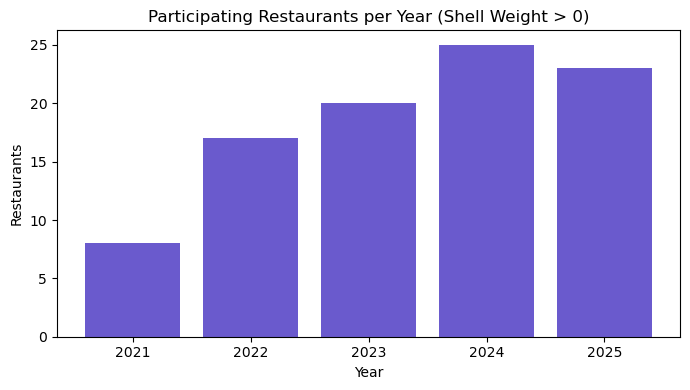

In [30]:
# restaurants_per_year_filtered.py
import pandas as pd
import matplotlib.pyplot as plt

# path to your cleaned merged file
FILE = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"

# Load data
df = pd.read_csv(FILE)

# ---- identify key columns ----
rest_col = "Restaurant" if "Restaurant" in df.columns else "name"
weight_col = next((c for c in df.columns if "Shell" in c and "Weight" in c), None)
if weight_col is None:
    raise ValueError("Couldn't find 'Shell Only Weight' column.")

# Ensure Year column exists
if "Year" not in df.columns:
    # Try inferring from date-like column
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    if date_like:
        df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year
    else:
        raise ValueError("No 'Year' column found in the dataset.")

# Convert weights to numeric
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce")

# ---- filter out zero or missing weights ----
df_valid = df[df[weight_col] > 0].copy()

# ---- count unique restaurants per year ----
summary = (
    df_valid.groupby("Year")[rest_col]
            .nunique()
            .reset_index(name="Unique Restaurants (with shells)")
            .sort_values("Year")
)

print("\nNumber of participating restaurants with nonzero Shell Only Weight:\n")
print(summary.to_string(index=False))

# ---- optional bar chart ----
plt.figure(figsize=(7,4))
plt.bar(summary["Year"].astype(str), summary["Unique Restaurants (with shells)"], color="#6A5ACD")
plt.title("Participating Restaurants per Year (Shell Weight > 0)")
plt.xlabel("Year")
plt.ylabel("Restaurants")
plt.tight_layout()
plt.show()

In [100]:
# participating_restaurants_map_by_year.py
import pandas as pd
import plotly.express as px
import numpy as np
import math
import copy

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map.html"

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

# Normalize lat/lon column names
lat_candidates = [c for c in df.columns if c.lower() in ("lat", "latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon", "lng", "longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("CSV must have latitude/longitude columns named like Lat/Latitude and Lon/Lng/Longitude.")
if lat_candidates[0] != "Lat": df = df.rename(columns={lat_candidates[0]: "Lat"})
if lon_candidates[0] != "Lon": df = df.rename(columns={lon_candidates[0]: "Lon"})

df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Shell weight column (flexible match)
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if weight_col is None:
    raise ValueError("Couldn't find a 'Shell Only Weight' column.")

# Year column (derive if needed)
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = (pd.to_datetime(df[date_like], errors="coerce").dt.year
                  if date_like else "All Years")
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# ------------ Filter valid rows ------------
data = df.dropna(subset=["Lat", "Lon"]).copy()
data[weight_col] = pd.to_numeric(data[weight_col], errors="coerce")
data = data[(data[weight_col] > 0) & data["Year"].notna()].copy()
if data.empty:
    raise ValueError("No rows remain after filtering for valid coordinates and positive shell weight.")

# ------------ Tight Cape Cod window ------------
# Very narrow bounds so only the Cape stays in frame (Provincetown hook through Chatham/Hyannis)
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
data = data[
    (data["Lat"] >= CAPE_BOUNDS["lat_min"]) & (data["Lat"] <= CAPE_BOUNDS["lat_max"]) &
    (data["Lon"] >= CAPE_BOUNDS["lon_min"]) & (data["Lon"] <= CAPE_BOUNDS["lon_max"])
].copy()
if data.empty:
    raise ValueError("After restricting to tight Cape bounds, no rows remain. Loosen CAPE_BOUNDS slightly if needed.")

# Hover display columns (safe fallbacks if missing)
name_col = "Restaurant" if "Restaurant" in data.columns else ("name" if "name" in data.columns else None)
addr_col = "Full Address" if "Full Address" in data.columns else None
if name_col is None:
    data["Restaurant (missing)"] = "N/A"; name_col = "Restaurant (missing)"
if addr_col is None:
    data["Full Address (missing)"] = "N/A"; addr_col = "Full Address (missing)"

# Year order for stable colors/slider
year_order = sorted(data["Year"].unique(), key=lambda x: (x != "All Years", x))

# ------------ Cape-centered view (tight frame) ------------
center = {"lat": 41.86, "lon": -70.05}  # center between the hook and mid-Cape
zoom   = 8.6                            # tighter view so the Cape fills the frame

# ------------ Jitter to separate overlaps ------------
R_METERS = 60.0  # ~60 m radius

def meters_to_deg(lat):
    lat_deg = R_METERS / 111_320.0
    lon_deg = R_METERS / (111_320.0 * max(0.25, math.cos(math.radians(lat))))
    return lat_deg, lon_deg

def jitter_group(sub):
    if len(sub) == 1:
        sub = sub.copy()
        sub["Lat_j"] = sub["Lat"]; sub["Lon_j"] = sub["Lon"]
        return sub
    lat0 = float(sub["Lat"].iloc[0]); lon0 = float(sub["Lon"].iloc[0])
    dlat, dlon = meters_to_deg(lat0)
    k = len(sub)
    phase = np.random.uniform(0, 2*np.pi)
    angles = phase + np.linspace(0, 2*np.pi, k, endpoint=False)
    r = 1.0 + 0.08 * min(10, k)
    sub = sub.copy()
    sub["Lat_j"] = lat0 + r * dlat * np.sin(angles)
    sub["Lon_j"] = lon0 + r * dlon * np.cos(angles)
    return sub

data = (
    data.groupby(["Year", "Lat", "Lon"], as_index=False, group_keys=False)
        .apply(jitter_group, include_groups=True)
        .reset_index(drop=True)
)

# ------------ Satellite basemap (Esri World Imagery) ------------
satellite_style = {
    "version": 8,
    "sources": {
        "esri": {
            "type": "raster",
            "tiles": [
                "https://services.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
            ],
            "tileSize": 256,
            "attribution": "Tiles © Esri — Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community",
        }
    },
    "layers": [{"id": "esri", "type": "raster", "source": "esri"}],
}

# ------------ Build COLORED figure (strict hover) ------------
custom_cols = [name_col, addr_col, weight_col]

colored = px.scatter_map(
    data.sort_values("Year"),
    lat="Lat_j", lon="Lon_j",
    color="Year",
    category_orders={"Year": year_order},
    animation_frame="Year",
    hover_name=None,
    hover_data={},                 # nothing auto-added
    custom_data=custom_cols,       # ONLY these go into hovertemplate
    color_discrete_sequence=px.colors.qualitative.Set2,
    zoom=zoom, height=760
)

hover_tmpl = (
    "<b>" + name_col + "</b>: %{customdata[0]}<br>"
    "<b>" + addr_col + "</b>: %{customdata[1]}<br>"
    "<b>" + weight_col + "</b>: %{customdata[2]:,.0f}"
    "<extra></extra>"
)

colored.update_traces(
    marker_size=16,
    marker_opacity=0.98,
    marker_symbol="circle",
    hovertemplate=hover_tmpl,
    hoverinfo="text"
)

colored.update_layout(
    title="Participating Restaurants",
    map_style=satellite_style,
    map=dict(center=center, zoom=zoom),
    showlegend=True,
    legend_title_text="Year",
    margin=dict(l=10, r=10, t=60, b=10),
    hoverlabel=dict(align="left"),
)

# ------------ Build HALO figure (white outline, no hover) ------------
halo = copy.deepcopy(colored)
for tr in halo.data:
    tr.update(marker=dict(size=20, opacity=0.35, color="white"),
              showlegend=False, hovertemplate="<extra></extra>", hoverinfo="skip")
for fr in (halo.frames or []):
    for tr in fr.data:
        tr.update(marker=dict(size=20, opacity=0.35, color="white"),
                  showlegend=False, hovertemplate="<extra></extra>", hoverinfo="skip")

# ------------ Compose final figure (halo under colored) ------------
fig = halo
fig.add_traces(colored.data)  # append colored traces after halo

# Merge frames by name: halo first, then colored
halo_frames_by_name = {fr.name: fr for fr in (halo.frames or [])}
new_frames = []
for fr_col in (colored.frames or []):
    fr_halo = halo_frames_by_name.get(fr_col.name)
    if fr_halo:
        combined = type(fr_col)(name=fr_col.name,
                                data=tuple(list(fr_halo.data) + list(fr_col.data)),
                                traces=None)
        new_frames.append(combined)
    else:
        new_frames.append(fr_col)
fig.frames = tuple(new_frames)

# --- Enforce hover everywhere ---
for tr in fig.data:
    if getattr(tr.marker, "color", None) == "white":
        tr.update(hoverinfo="skip", hovertemplate="<extra></extra>")
    else:
        tr.update(hoverinfo="text", hovertemplate=hover_tmpl)
for fr in (fig.frames or []):
    for tr in fr.data:
        if getattr(tr.marker, "color", None) == "white":
            tr.update(hoverinfo="skip", hovertemplate="<extra></extra>")
        else:
            tr.update(hoverinfo="text", hovertemplate=hover_tmpl)

# ------------ Slow animation (very slow) ------------
frame_ms, trans_ms = 12000, 1500  # ~12s per year, long cross-fade
if fig.layout.updatemenus:
    for b in fig.layout.updatemenus[0].buttons:
        b.args[1]["frame"]["duration"] = frame_ms
        b.args[1]["transition"]["duration"] = trans_ms
if fig.layout.sliders:
    fig.layout.sliders[0]["transition"]["duration"] = trans_ms

# ------------ Save ------------
fig.write_html(
    OUT,
    include_plotlyjs="cdn",
    full_html=True,
    config={"scrollZoom": True, "displaylogo": False}
)
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\participating_restaurants_map.html


C:\Users\suzan\AppData\Local\Temp\ipykernel_4100\1557725203.py:95: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [1]:
#v3
# participating_restaurants_map_and_year_bar_twocol_brand_final.py
import pandas as pd, plotly.express as px, plotly.io as pio
import numpy as np, math, json
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

# Normalize coordinate names
lat_candidates = [c for c in df.columns if c.lower() in ("lat","latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon","lng","longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0]!="Lat": df=df.rename(columns={lat_candidates[0]:"Lat"})
if lon_candidates[0]!="Lon": df=df.rename(columns={lon_candidates[0]:"Lon"})

df["Lat"]=pd.to_numeric(df["Lat"],errors="coerce")
df["Lon"]=pd.to_numeric(df["Lon"],errors="coerce")

# Shell weight column
weight_col=next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()),None)
if not weight_col: raise ValueError("No 'Shell Only Weight' column found.")

# Year handling
if "Year" not in df.columns:
    date_like=next((c for c in df.columns if "date" in c.lower()),None)
    df["Year"]=pd.to_datetime(df[date_like],errors="coerce").dt.year if date_like else "All Years"
df["Year"]=df["Year"].astype("Int64").astype(str).replace("<NA>","All Years")

# Clean + filter
data=df.dropna(subset=["Lat","Lon"]).copy()
data[weight_col]=pd.to_numeric(data[weight_col],errors="coerce").fillna(0)
data=data[data[weight_col]>=0]  # keep 0s on map; bars filter later

# Cape bounds
CAPE_BOUNDS={"lat_min":41.62,"lat_max":42.08,"lon_min":-70.70,"lon_max":-69.88}
data=data[(data["Lat"].between(CAPE_BOUNDS["lat_min"],CAPE_BOUNDS["lat_max"]))&
          (data["Lon"].between(CAPE_BOUNDS["lon_min"],CAPE_BOUNDS["lon_max"]))]

# Required cols
name_col="Restaurant" if "Restaurant" in data.columns else "name"
if name_col not in data.columns: data[name_col]="Unknown"
addr_col=("Full Address" if "Full Address" in data.columns
          else ("Address" if "Address" in data.columns else None))
if addr_col is None:
    addr_col="__addr__"; data[addr_col]="N/A"

year_order=sorted(data["Year"].unique(), key=lambda x: (x!="All Years", x))

# ---- Jitter overlapping points (silence groupby.apply deprecation) ---
R_METERS=60
def meters_to_deg(lat):
    lat_deg=R_METERS/111_320
    lon_deg=R_METERS/(111_320*max(0.25,math.cos(math.radians(lat))))
    return lat_deg,lon_deg

def jitter_group(sub):
    sub=sub.copy()
    if len(sub)<=1:
        sub["Lat_j"]=sub["Lat"]; sub["Lon_j"]=sub["Lon"]; return sub
    lat0,lon0=sub["Lat"].iloc[0],sub["Lon"].iloc[0]
    dlat,dlon=meters_to_deg(lat0)
    k=len(sub); phase=np.random.uniform(0,2*np.pi); ang=phase+np.linspace(0,2*np.pi,k,endpoint=False)
    sub["Lat_j"]=lat0+dlat*np.sin(ang); sub["Lon_j"]=lon0+dlon*np.cos(ang)
    return sub

# ✅ keep Lat/Lon inside sub
data = (data.groupby(["Year","Lat","Lon"], as_index=False, group_keys=False)
           .apply(jitter_group, include_groups=True)
           .reset_index(drop=True))

# Brand colors
brand_colors=["#3DB0C3","#99D6CE","#2E8F97","#ECE6DE","#0E013D"]

# ------------ MAP FIGURE (no mapbox deprecation) ------------
custom_cols = [name_col, addr_col, weight_col]
fig_map=px.scatter_map(
    data.sort_values("Year"),
    lat="Lat_j", lon="Lon_j",
    color="Year",
    animation_frame="Year",
    category_orders={"Year":year_order},
    color_discrete_sequence=brand_colors,
    hover_name=name_col,
    hover_data={},                   # we control hover via template
    custom_data=custom_cols,
    map_style="carto-positron",      # token-free styles: 'open-street-map', 'carto-positron', 'carto-darkmatter'
    center={"lat":41.86,"lon":-70.05},
    zoom=8.6, height=640
)

hover_template=(
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>{weight_col}</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)
fig_map.update_traces(marker=dict(size=14), hovertemplate=hover_template)
fig_map.update_layout(
    title="Participating Restaurants",
    legend=dict(
        orientation="h",yanchor="top",y=0.99,xanchor="center",x=0.5,
        bgcolor="rgba(255,255,255,0.8)",bordercolor="rgba(0,0,0,0.2)",borderwidth=1
    ),
    margin=dict(l=0,r=20,t=60,b=0)
)

# Moderate animation speed
if fig_map.layout.updatemenus:
    for b in fig_map.layout.updatemenus[0].buttons:
        if isinstance(b.args, list) and len(b.args)>=2 and "frame" in b.args[1]:
            b.args[1]["frame"]["duration"]=800
            b.args[1]["transition"]["duration"]=400
if fig_map.layout.sliders:
    fig_map.layout.sliders[0]["transition"]["duration"]=400

# ------------ BAR DATA ------------
bar_long=(data.groupby(["Year",name_col],as_index=False)[weight_col].sum()
            .rename(columns={weight_col:"Weight"}))
bar_years=sorted(bar_long["Year"].unique(), key=lambda x: (x!="All Years", x))
restaurants=sorted(bar_long[name_col].unique())

palette=(px.colors.qualitative.Safe+px.colors.qualitative.Set2+
         px.colors.qualitative.Set3+px.colors.qualitative.Plotly)
color_map={r:palette[i%len(palette)] for i,r in enumerate(restaurants)}

# Serialize for JS
data_json=json.dumps(bar_long.to_dict(orient="records"))
years_json=json.dumps(bar_years)
colors_json=json.dumps(color_map)

map_html=pio.to_html(fig_map,include_plotlyjs="cdn",full_html=False,config={"displaylogo":False},div_id="mapFig")
bar_placeholder='<div id="barFig"></div>'

# ------------ JS Sync Script ------------
js=f"""
<script>
(function(){{
  const DATA={data_json};
  const YEARS={years_json};
  const COLORS={colors_json};
  const NAME={json.dumps(name_col)};
  const mapDiv=document.getElementById('mapFig');
  const barDiv=document.getElementById('barFig');

  function toComma(n){{try{{return(+n).toLocaleString();}}catch(e){{return n;}}}}

  function renderBar(year){{
    const rows=DATA.filter(r=>String(r.Year)===String(year)).sort((a,b)=>(b.Weight||0)-(a.Weight||0));
    const traces=rows.map(r=>({{
      type:'bar', x:[year], y:[r.Weight||0], name:r[NAME],
      marker:{{color:COLORS[r[NAME]]||'#888'}},
      hovertemplate:'<b>%{{name}}</b><br>Pounds diverted: %{{y:,.0f}} lbs<extra></extra>'
    }}));
    const total=rows.reduce((s,r)=>s+(r.Weight||0),0);
    traces.push({{
      type:'scatter', x:[year], y:[total], mode:'text', text:[toComma(total)+' lbs'],
      textposition:'top center', hoverinfo:'skip', showlegend:false
    }});
    const layout={{
      barmode:'stack',
      margin:{{l:55,r:0,t:28,b:50}},
      legend:{{title:{{text:'Restaurant'}}}},
      yaxis:{{title:'Pounds diverted (Shell Only Weight)', automargin:true, rangemode:'tozero'}},
      xaxis:{{tickvals:[year], ticktext:[year], ticklabelposition:'outside left'}},
      hoverlabel:{{align:'left'}},
      width:520, height:420
    }};
    Plotly.react(barDiv,traces,layout,{{displaylogo:false,responsive:true}});
    const sub = document.getElementById('barSubtitle');
    if (sub) sub.textContent='Year: '+year+' — Total diverted: '+toComma(total)+' lbs';
  }}

  function currentYear(){{
    const sl=mapDiv._fullLayout?.sliders?.[0];
    if(sl&&sl.steps?.length) return sl.steps[sl.active||0].label;
    return YEARS[0];
  }}

  mapDiv.on('plotly_sliderchange',e=>{{ if(e.step?.label) renderBar(e.step.label); }});
  mapDiv.on('plotly_animated',e=>{{ if(e.frame?.name) renderBar(e.frame.name); }});
  renderBar(currentYear());
}})();
</script>
"""

# ------------ HTML Layout ------------
html=f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}}
.wrap{{display:flex;flex-wrap:wrap;gap:18px;max-width:1500px;margin:auto;padding:10px}}
.left{{flex:2 1 780px;min-width:600px}}
.right{{flex:1 1 520px;min-width:360px}}
h2{{font-size:18px;margin:0 0 6px}}
#barSubtitle{{font-size:13px;color:#555;margin:0 0 10px}}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">{map_html}</div>
  <div class="right">
    <h2>Shell Only Weight by Restaurant (stacked)</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    {bar_placeholder}
  </div>
</div>
{js}
</body></html>
"""
Path(OUT).write_text(html,encoding="utf-8")
print(f"Saved: {OUT}")

C:\Users\suzan\AppData\Local\Temp\ipykernel_16184\1973237707.py:73: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(jitter_group, include_groups=True)


Saved: C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html


In [3]:
#v4: fix what attributes show when hovering


# participating_restaurants_map_and_year_bar_twocol_brand_final.py
import pandas as pd, plotly.express as px, plotly.io as pio
import numpy as np, math, json
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

# Normalize coordinate names
lat_candidates = [c for c in df.columns if c.lower() in ("lat","latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon","lng","longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0]!="Lat": df=df.rename(columns={lat_candidates[0]:"Lat"})
if lon_candidates[0]!="Lon": df=df.rename(columns={lon_candidates[0]:"Lon"})

df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Shell weight column
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

# Year handling
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# Clean + filter
data = df.dropna(subset=["Lat", "Lon"]).copy()
data[weight_col] = pd.to_numeric(data[weight_col], errors="coerce").fillna(0)
data = data[data[weight_col] >= 0]  # keep 0s on map; bars filter later

# Cape bounds
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
data = data[
    data["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"])
    & data["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
]

# Required cols
name_col = "Restaurant" if "Restaurant" in data.columns else "name"
if name_col not in data.columns:
    data[name_col] = "Unknown"
addr_col = "Full Address" if "Full Address" in data.columns else ("Address" if "Address" in data.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    data[addr_col] = "N/A"

year_order = sorted(data["Year"].unique(), key=lambda x: (x != "All Years", x))

# ------------ Jitter overlapping points (vectorized; no groupby.apply) ------------
R_METERS = 60
# group id, size, and index within group
g = data.groupby(["Year", "Lat", "Lon"], sort=False)
data["_gid"] = g.ngroup()
data["_n"] = g["Lat"].transform("size")
data["_i"] = g.cumcount()

# one random phase per group
n_groups = int(data["_gid"].max()) + 1
phases = np.random.uniform(0, 2*np.pi, size=n_groups)
data["_phase"] = data["_gid"].map(dict(enumerate(phases)))

# per-row angle and meter->degree scales
data["_ang"] = data["_phase"] + 2*np.pi * (data["_i"] / data["_n"].clip(lower=1))
data["_dlat"] = R_METERS / 111_320.0
data["_dlon"] = R_METERS / (111_320.0 * np.maximum(0.25, np.cos(np.radians(data["Lat"]))))

# apply jitter only when group size > 1
mask = data["_n"] > 1
data["Lat_j"] = data["Lat"]
data["Lon_j"] = data["Lon"]
data.loc[mask, "Lat_j"] = data.loc[mask, "Lat"] + data.loc[mask, "_dlat"] * np.sin(data.loc[mask, "_ang"])
data.loc[mask, "Lon_j"] = data.loc[mask, "Lon"] + data.loc[mask, "_dlon"] * np.cos(data.loc[mask, "_ang"])

# cleanup temp cols
data.drop(columns=["_gid","_n","_i","_phase","_ang","_dlat","_dlon"], inplace=True)

# Brand colors
brand_colors = ["#3DB0C3", "#99D6CE", "#2E8F97", "#ECE6DE", "#0E013D"]

# ------------ MAP (Plotly token-free) ------------
custom_cols = [name_col, addr_col, weight_col]
fig_map = px.scatter_map(
    data.sort_values("Year"),
    lat="Lat_j", lon="Lon_j",
    color="Year",
    animation_frame="Year",
    category_orders={"Year": year_order},
    color_discrete_sequence=brand_colors,
    hover_name=name_col,
    hover_data={},                 # we control hover via template
    custom_data=custom_cols,
    map_style="carto-positron",    # also: 'open-street-map', 'carto-darkmatter'
    center={"lat": 41.86, "lon": -70.05},
    zoom=8.6, height=640
)

hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>{weight_col}</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)
fig_map.update_traces(marker=dict(size=14), hovertemplate=hover_template)
fig_map.update_layout(
    title="Participating Restaurants",
    legend=dict(
        orientation="h", yanchor="top", y=0.99, xanchor="center", x=0.5,
        bgcolor="rgba(255,255,255,0.8)", bordercolor="rgba(0,0,0,0.2)", borderwidth=1
    ),
    margin=dict(l=0, r=20, t=60, b=0)
)

# Animation speed
if fig_map.layout.updatemenus:
    for b in fig_map.layout.updatemenus[0].buttons:
        if isinstance(b.args, list) and len(b.args) >= 2 and "frame" in b.args[1]:
            b.args[1]["frame"]["duration"] = 800
            b.args[1]["transition"]["duration"] = 400
if fig_map.layout.sliders:
    fig_map.layout.sliders[0]["transition"]["duration"] = 400

# ------------ BAR DATA ------------
bar_long = (data.groupby(["Year", name_col], as_index=False)[weight_col].sum()
              .rename(columns={weight_col: "Weight"}))
bar_years = sorted(bar_long["Year"].unique(), key=lambda x: (x != "All Years", x))
restaurants = sorted(bar_long[name_col].unique())

palette = (px.colors.qualitative.Safe + px.colors.qualitative.Set2 +
           px.colors.qualitative.Set3 + px.colors.qualitative.Plotly)
color_map = {r: palette[i % len(palette)] for i, r in enumerate(restaurants)}

# Serialize for JS
data_json = json.dumps(bar_long.to_dict(orient="records"))
years_json = json.dumps(bar_years)
colors_json = json.dumps(color_map)

map_html = pio.to_html(fig_map, include_plotlyjs="cdn", full_html=False,
                       config={"displaylogo": False}, div_id="mapFig")
bar_placeholder = '<div id="barFig"></div>'

# ------------ JS Sync Script (hover fix uses fullData.name) ------------
js = f"""
<script>
(function(){{
  const DATA={data_json};
  const YEARS={years_json};
  const COLORS={colors_json};
  const NAME={json.dumps(name_col)};
  const mapDiv=document.getElementById('mapFig');
  const barDiv=document.getElementById('barFig');

  function toComma(n){{try{{return(+n).toLocaleString();}}catch(e){{return n;}}}}

  function renderBar(year){{
    const rows=DATA.filter(r=>String(r.Year)===String(year))
                   .sort((a,b)=>(b.Weight||0)-(a.Weight||0));
    const traces=rows.map(r=>({{
      type:'bar',
      x:[year], y:[r.Weight||0],
      name:r[NAME],
      marker:{{color:COLORS[r[NAME]]||'#888'}},
      hovertemplate:'<b>%{{fullData.name}}</b><br>Pounds diverted: %{{y:,.0f}} lbs<extra></extra>'
    }}));
    const total=rows.reduce((s,r)=>s+(r.Weight||0),0);
    traces.push({{
      type:'scatter', x:[year], y:[total],
      mode:'text', text:[toComma(total)+' lbs'],
      textposition:'top center', hoverinfo:'skip', showlegend:false
    }});
    const layout={{
      barmode:'stack',
      margin:{{l:55,r:0,t:28,b:50}},
      legend:{{title:{{text:'Restaurant'}}}},
      yaxis:{{title:'Pounds diverted (Shell Only Weight)', automargin:true, rangemode:'tozero'}},
      xaxis:{{tickvals:[year], ticktext:[year], ticklabelposition:'outside left'}},
      hoverlabel:{{align:'left'}},
      width:520, height:420
    }};
    Plotly.react(barDiv,traces,layout,{{displaylogo:false,responsive:true}});
    const sub=document.getElementById('barSubtitle');
    if(sub) sub.textContent='Year: '+year+' — Total diverted: '+toComma(total)+' lbs';
  }}

  function currentYear(){{
    const sl=mapDiv._fullLayout?.sliders?.[0];
    if(sl&&sl.steps?.length) return sl.steps[sl.active||0].label;
    return YEARS[0];
  }}

  mapDiv.on('plotly_sliderchange',e=>{{ if(e.step?.label) renderBar(e.step.label); }});
  mapDiv.on('plotly_animated',e=>{{ if(e.frame?.name) renderBar(e.frame.name); }});
  renderBar(currentYear());
}})();
</script>
"""

# ------------ HTML Layout ------------
html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}}
.wrap{{display:flex;flex-wrap:wrap;gap:18px;max-width:1500px;margin:auto;padding:10px}}
.left{{flex:2 1 780px;min-width:600px}}
.right{{flex:1 1 520px;min-width:360px}}
h2{{font-size:18px;margin:0 0 6px}}
#barSubtitle{{font-size:13px;color:#555;margin:0 0 10px}}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">{map_html}</div>
  <div class="right">
    <h2>Shell Only Weight by Restaurant (stacked)</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    {bar_placeholder}
  </div>
</div>
{js}
</body></html>
"""
Path(OUT).write_text(html, encoding="utf-8")
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html


In [7]:
#V5: color by restaurant

# participating_restaurants_map_and_year_bar_twocol_brand_final.py
import pandas as pd, plotly.express as px, plotly.io as pio
import numpy as np, json
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

# Normalize coordinate names
lat_candidates = [c for c in df.columns if c.lower() in ("lat","latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon","lng","longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0]!="Lat": df=df.rename(columns={lat_candidates[0]:"Lat"})
if lon_candidates[0]!="Lon": df=df.rename(columns={lon_candidates[0]:"Lon"})

df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Shell weight column
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

# Year handling
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# Clean + filter
data = df.dropna(subset=["Lat", "Lon"]).copy()
data[weight_col] = pd.to_numeric(data[weight_col], errors="coerce").fillna(0)
data = data[data[weight_col] >= 0]  # keep 0s on map; bars filter later

# Cape bounds
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
data = data[
    data["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"])
    & data["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
]

# Required cols
name_col = "Restaurant" if "Restaurant" in data.columns else "name"
if name_col not in data.columns:
    data[name_col] = "Unknown"
addr_col = "Full Address" if "Full Address" in data.columns else ("Address" if "Address" in data.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    data[addr_col] = "N/A"

year_order = sorted(data["Year"].unique(), key=lambda x: (x != "All Years", x))

# ------------ Restaurant color palette (shared) ------------
palette = (px.colors.qualitative.Safe + px.colors.qualitative.Set2 +
           px.colors.qualitative.Set3 + px.colors.qualitative.Plotly)
restaurants_all = sorted(data[name_col].fillna("Unknown").unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(restaurants_all)}

# ------------ Jitter overlapping points (vectorized) ------------
R_METERS = 60
g = data.groupby(["Year", "Lat", "Lon"], sort=False)
data["_gid"] = g.ngroup()
data["_n"] = g["Lat"].transform("size")
data["_i"] = g.cumcount()
n_groups = int(data["_gid"].max()) + 1
phases = np.random.uniform(0, 2*np.pi, size=n_groups)
data["_phase"] = data["_gid"].map(dict(enumerate(phases)))
data["_ang"] = data["_phase"] + 2*np.pi * (data["_i"] / data["_n"].clip(lower=1))
data["_dlat"] = R_METERS / 111_320.0
data["_dlon"] = R_METERS / (111_320.0 * np.maximum(0.25, np.cos(np.radians(data["Lat"]))))
mask = data["_n"] > 1
data["Lat_j"] = data["Lat"]
data["Lon_j"] = data["Lon"]
data.loc[mask, "Lat_j"] = data.loc[mask, "Lat"] + data.loc[mask, "_dlat"] * np.sin(data.loc[mask, "_ang"])
data.loc[mask, "Lon_j"] = data.loc[mask, "Lon"] + data.loc[mask, "_dlon"] * np.cos(data.loc[mask, "_ang"])
data.drop(columns=["_gid","_n","_i","_phase","_ang","_dlat","_dlon"], inplace=True)

# ------------ MAP ------------
custom_cols = [name_col, addr_col, weight_col]
fig_map = px.scatter_map(
    data.sort_values("Year"),
    lat="Lat_j", lon="Lon_j",
    color=name_col,                         # color by restaurant
    animation_frame="Year",
    category_orders={"Year": year_order},
    color_discrete_map=color_map,
    hover_name=name_col,
    hover_data={},
    custom_data=custom_cols,
    map_style="carto-positron",
    center={"lat": 41.86, "lon": -70.05},
    zoom=8.6, height=640
)
hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>{weight_col}</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)
fig_map.update_traces(marker=dict(size=14), hovertemplate=hover_template)

# HIDE Plotly legend on the map (we'll render our own below the slider)
fig_map.update_layout(
    title="Participating Restaurants",
    showlegend=False,
    margin=dict(l=0, r=20, t=60, b=0)
)

# Animation speed
if fig_map.layout.updatemenus:
    for b in fig_map.layout.updatemenus[0].buttons:
        if isinstance(b.args, list) and len(b.args) >= 2 and "frame" in b.args[1]:
            b.args[1]["frame"]["duration"] = 800
            b.args[1]["transition"]["duration"] = 400
if fig_map.layout.sliders:
    fig_map.layout.sliders[0]["transition"]["duration"] = 400

# ------------ BAR DATA ------------
bar_long = (data.groupby(["Year", name_col], as_index=False)[weight_col].sum()
              .rename(columns={weight_col: "Weight"}))
bar_years = sorted(bar_long["Year"].unique(), key=lambda x: (x != "All Years", x))

# Serialize for JS
data_json = json.dumps(bar_long.to_dict(orient="records"))
years_json = json.dumps(bar_years)
colors_json = json.dumps(color_map)
names_json = json.dumps(restaurants_all)

map_html = pio.to_html(fig_map, include_plotlyjs="cdn", full_html=False,
                       config={"displaylogo": False}, div_id="mapFig")
bar_placeholder = '<div id="barFig"></div>'

# ------------ JS: bar sync + custom legend below slider ------------
js = f"""
<script>
(function(){{
  const DATA={data_json};
  const YEARS={years_json};
  const COLORS={colors_json};
  const NAMES={names_json};
  const NAME={json.dumps(name_col)};
  const mapDiv=document.getElementById('mapFig');
  const barDiv=document.getElementById('barFig');
  const legendDiv=document.getElementById('legendBelow');

  function toComma(n){{try{{return(+n).toLocaleString();}}catch(e){{return n;}}}}

  function renderBar(year){{
    const rows=DATA.filter(r=>String(r.Year)===String(year))
                   .sort((a,b)=>(b.Weight||0)-(a.Weight||0));
    const traces=rows.map(r=>({{
      type:'bar',
      x:[year], y:[r.Weight||0],
      name:r[NAME],
      marker:{{color:COLORS[r[NAME]]||'#888'}},
      hovertemplate:'<b>%{{fullData.name}}</b><br>Pounds diverted: %{{y:,.0f}} lbs<extra></extra>'
    }}));
    const total=rows.reduce((s,r)=>s+(r.Weight||0),0);
    traces.push({{
      type:'scatter', x:[year], y:[total],
      mode:'text', text:[toComma(total)+' lbs'],
      textposition:'top center', hoverinfo:'skip', showlegend:false
    }});
    const layout={{
      barmode:'stack',
      margin:{{l:55,r:0,t:28,b:50}},
      legend:{{title:{{text:'Restaurant'}}}},
      yaxis:{{title:'Pounds diverted (Shell Only Weight)', automargin:true, rangemode:'tozero'}},
      xaxis:{{tickvals:[year], ticktext:[year], ticklabelposition:'outside left'}},
      hoverlabel:{{align:'left'}},
      width:520, height:420
    }};
    Plotly.react(barDiv,traces,layout,{{displaylogo:false,responsive:true}});
    const sub=document.getElementById('barSubtitle');
    if(sub) sub.textContent='Year: '+year+' — Total diverted: '+toComma(total)+' lbs';
  }}

  function currentYear(){{
    const sl=mapDiv._fullLayout?.sliders?.[0];
    if(sl&&sl.steps?.length) return sl.steps[sl.active||0].label;
    return YEARS[0];
  }}

  // --- Custom legend below the slider ---
  function renderLegend(){{
    if(!legendDiv) return;
    let html = '';
    for(const r of NAMES){{
      const c = COLORS[r] || '#888';
      html += `<div class="legend-item"><span class="swatch" style="background:${{c}}"></span><span class="label">${{r}}</span></div>`;
    }}
    legendDiv.innerHTML = html;
  }}

  mapDiv.on('plotly_sliderchange',e=>{{ if(e.step?.label) renderBar(e.step.label); }});
  mapDiv.on('plotly_animated',e=>{{ if(e.frame?.name) renderBar(e.frame.name); }});

  renderBar(currentYear());
  renderLegend();
}})();
</script>
"""

# ------------ HTML Layout ------------
html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}}
.wrap{{display:flex;flex-wrap:wrap;gap:18px;max-width:1500px;margin:auto;padding:10px}}
.left{{flex:2 1 780px;min-width:600px}}
.right{{flex:1 1 520px;min-width:360px}}
h2{{font-size:18px;margin:0 0 6px}}
#barSubtitle{{font-size:13px;color:#555;margin:0 0 10px}}
/* Custom legend styles */
#legendBelow{{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}}
#legendBelow .legend-item{{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}}
#legendBelow{{display:flex;flex-wrap:wrap;justify-content:flex-start}}
#legendBelow .swatch{{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}}
#legendBelow .label{{font-size:12px;color:#333}}
/* keep Plotly's own controls intact (slider remains inside the map figure) */
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    {map_html}
    <!-- Custom legend sits BELOW the map (and thus visually below the slider) -->
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <h2>Shell Only Weight by Restaurant (stacked)</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    {bar_placeholder}
  </div>
</div>
{js}
</body></html>
"""
Path(OUT).write_text(html, encoding="utf-8")
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html


In [3]:
#V5 implement for loop filtering SOW = 0
import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

lat_candidates = [c for c in df.columns if c.lower() in ("lat","latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon","lng","longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0] != "Lat": df = df.rename(columns={lat_candidates[0]:"Lat"})
if lon_candidates[0] != "Lon": df = df.rename(columns={lon_candidates[0]:"Lon"})

df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Weight column
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

# Year handling
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# Clean base
df = df.dropna(subset=["Lat", "Lon"]).copy()
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Cape bounds
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"]) &
    df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
]

# Required cols
name_col = "Restaurant" if "Restaurant" in df.columns else "name"
if name_col not in df.columns: df[name_col] = "Unknown"
addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None: addr_col = "__addr__"; df[addr_col] = "N/A"

years = sorted(df["Year"].unique(), key=lambda x: (x != "All Years", x))

# Consistent colors for any restaurant that participates (>0 at least once)
palette = (px.colors.qualitative.Safe + px.colors.qualitative.Set2 +
           px.colors.qualitative.Set3 + px.colors.qualitative.Plotly)
participants_any = sorted(df.loc[df[weight_col] > 0, name_col].fillna("Unknown").unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(participants_any)}

# -------- helper: jitter per-year subset --------
def jitter_year(sub):
    if sub.empty:
        sub["Lat_j"], sub["Lon_j"] = sub["Lat"], sub["Lon"]
        return sub
    R_METERS = 60
    g = sub.groupby(["Lat","Lon"], sort=False)
    sub = sub.copy()
    sub["_gid"] = g.ngroup()
    sub["_n"] = g["Lat"].transform("size")
    sub["_i"] = g.cumcount()
    phases = np.random.uniform(0, 2*np.pi, size=int(sub["_gid"].max())+1)
    sub["_phase"] = sub["_gid"].map(dict(enumerate(phases)))
    sub["_ang"] = sub["_phase"] + 2*np.pi * (sub["_i"] / sub["_n"].clip(lower=1))
    sub["_dlat"] = R_METERS / 111_320.0
    sub["_dlon"] = R_METERS / (111_320.0 * np.maximum(0.25, np.cos(np.radians(sub["Lat"]))))
    mask = sub["_n"] > 1
    sub["Lat_j"], sub["Lon_j"] = sub["Lat"], sub["Lon"]
    sub.loc[mask, "Lat_j"] = sub.loc[mask, "Lat"] + sub.loc[mask, "_dlat"] * np.sin(sub.loc[mask, "_ang"])
    sub.loc[mask, "Lon_j"] = sub.loc[mask, "Lon"] + sub.loc[mask, "_dlon"] * np.cos(sub.loc[mask, "_ang"])
    return sub.drop(columns=["_gid","_n","_i","_phase","_ang","_dlat","_dlon"])

# -------- build frames (PER YEAR FILTER) --------
def make_px_for_year(y):
    sub = df[(df["Year"] == y) & (df[weight_col] > 0)].copy()
    if not sub.empty:
        sub = (sub.groupby([name_col], as_index=False)
                .agg({weight_col:"sum","Lat":"first","Lon":"first",addr_col:"first"}))
        sub = sub.rename(columns={weight_col:"YearWeight"})
        sub = jitter_year(sub)
    else:
        sub["YearWeight"] = pd.Series(dtype=float)
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    fig_y = px.scatter_map(
        sub,
        lat="Lat_j", lon="Lon_j",
        color=name_col,
        color_discrete_map=color_map,
        hover_name=name_col,
        hover_data={"Lat_j":False,"Lon_j":False,"Lat":False,"Lon":False},
        custom_data=[name_col, addr_col, "YearWeight"],
        map_style="carto-positron",
        center={"lat": 41.86, "lon": -70.05},
        zoom=8.6, height=640
    )
    hover_template = (
        f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
        f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
        f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
    )
    for tr in fig_y.data:
        tr.update(marker=dict(size=14), hovertemplate=hover_template, showlegend=False)
    return fig_y

first_year = years[0] if years else None
base_fig = make_px_for_year(first_year) if first_year is not None else go.Figure()
fig_map = go.Figure(base_fig)

frames = []
for y in years:
    fy = make_px_for_year(y)
    frames.append(go.Frame(name=str(y), data=fy.data))
fig_map.frames = frames

# ---- Controls strip directly under map (above attribution) ----
# Use a small positive y (0.04–0.06) so it sits *inside* the plotting area just above map attribution.
controls_y = 0.055

sliders = [dict(
    active=0,
    x=0.12, y=controls_y, xanchor="left", yanchor="bottom",
    len=0.82,
    pad={"t": 0, "b": 0},
    currentvalue={"visible": False},
    steps=[dict(method="animate",
                label=str(y),
                args=[[str(y)], {"mode":"immediate",
                                 "frame":{"duration":0,"redraw":True},
                                 "transition":{"duration":0}}]) for y in years]
)]

updatemenus = [dict(
    type="buttons",
    direction="left",
    x=0.0, y=controls_y, xanchor="left", yanchor="bottom",
    pad={"r": 10, "t": 0, "b": 0},
    buttons=[
        dict(label="▶ Play", method="animate",
             args=[None, {"fromcurrent": True,
                          "frame": {"duration": 800, "redraw": True},
                          "transition": {"duration": 400}}]),
        dict(label="⏸ Pause", method="animate",
             args=[[None], {"mode": "immediate",
                            "frame": {"duration": 0, "redraw": False},
                            "transition": {"duration": 0}}]),
    ]
)]

fig_map.update_layout(
    title="Participating Restaurants",
    mapbox_style=None,
    margin=dict(l=0, r=20, t=70, b=40),  # small bottom; controls live inside plot at y≈0.055
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus
)

# ------------ BAR DATA (stacked per year) ------------
bar_long = []
for y in years:
    sub = df[(df["Year"] == y) & (df[weight_col] > 0)]
    if not sub.empty:
        sums = (sub.groupby(name_col, as_index=False)[weight_col]
                  .sum().rename(columns={weight_col: "Weight"}))
        sums["Year"] = y
        bar_long.append(sums[["Year", name_col, "Weight"]])
bar_long = pd.concat(bar_long, ignore_index=True) if bar_long else pd.DataFrame(columns=["Year", name_col, "Weight"])

# Serialize data for JS / legend
data_json   = json.dumps(bar_long.to_dict(orient="records"))
years_json  = json.dumps(years)
colors_json = json.dumps(color_map)
names_json  = json.dumps(participants_any)

map_html = pio.to_html(fig_map, include_plotlyjs="cdn", full_html=False,
                       config={"displaylogo": False}, div_id="mapFig")
bar_placeholder = '<div id="barFig"></div>'

# ------------ JS: bar sync + legend ------------
js = f"""
<script>
(function(){{
  const DATA={data_json};
  const YEARS={years_json};
  const COLORS={colors_json};
  const NAMES={names_json};
  const NAME={json.dumps(name_col)};
  const mapDiv=document.getElementById('mapFig');
  const barDiv=document.getElementById('barFig');
  const legendDiv=document.getElementById('legendBelow');

  function toComma(n){{try{{return(+n).toLocaleString();}}catch(e){{return n;}}}}

  function renderBar(year){{
    const rows=DATA.filter(r=>String(r.Year)===String(year))
                   .filter(r=>(r.Weight||0)>0)
                   .sort((a,b)=>(b.Weight||0)-(a.Weight||0));
    const traces=rows.map(r=>({{
      type:'bar',
      x:[year], y:[r.Weight||0],
      name:r[NAME],
      marker:{{color:COLORS[r[NAME]]||'#888'}},
      hovertemplate:'<b>%{{fullData.name}}</b><br>Pounds diverted: %{{y:,.0f}} lbs<extra></extra>'
    }}));
    const total=rows.reduce((s,r)=>s+(r.Weight||0),0);
    traces.push({{
      type:'scatter', x:[year], y:[total],
      mode:'text', text:[toComma(total)+' lbs'],
      textposition:'top center', hoverinfo:'skip', showlegend:false
    }});
    const layout={{
      barmode:'stack',
      margin:{{l:55,r:0,t:28,b:50}},
      legend:{{title:{{text:'Restaurant'}}}},
      yaxis:{{title:'Pounds diverted (Shell Only Weight)', automargin:true, rangemode:'tozero'}},
      xaxis:{{tickvals:[year], ticktext:[year], ticklabelposition:'outside left'}},
      hoverlabel:{{align:'left'}},
      width:520, height:420
    }};
    Plotly.react(barDiv,traces,layout,{{displaylogo:false,responsive:true}});
    const sub=document.getElementById('barSubtitle');
    if(sub) sub.textContent='Year: '+year+' — Total diverted: '+toComma(total)+' lbs';
  }}

  function currentYear(){{
    const sl=mapDiv._fullLayout?.sliders?.[0];
    if(sl&&sl.steps?.length) return sl.steps[sl.active||0].label;
    return YEARS[0];
  }}

  function renderLegend(){{
    if(!legendDiv) return;
    let html = '';
    for(const r of NAMES){{
      const c = COLORS[r] || '#888';
      html += `<div class="legend-item"><span class="swatch" style="background:${{c}}"></span><span class="label">${{r}}</span></div>`;
    }}
    legendDiv.innerHTML = html;
  }}

  mapDiv.on('plotly_sliderchange',e=>{{ if(e.step?.label) renderBar(e.step.label); }});
  mapDiv.on('plotly_animated',e=>{{ if(e.frame?.name) renderBar(e.frame.name); }});
  renderBar(currentYear());
  renderLegend();
}})();
</script>
"""

# ------------ HTML Layout ------------
html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}}
.wrap{{display:flex;flex-wrap:wrap;gap:18px;max-width:1500px;margin:auto;padding:10px}}
.left{{flex:2 1 780px;min-width:600px}}
.right{{flex:1 1 520px;min-width:360px}}
h2{{font-size:18px;margin:0 0 6px}}
#barSubtitle{{font-size:13px;color:#555;margin:0 0 10px}}
#legendBelow{{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}}
#legendBelow .legend-item{{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}}
#legendBelow{{display:flex;flex-wrap:wrap;justify-content:flex-start}}
#legendBelow .swatch{{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}}
#legendBelow .label{{font-size:12px;color:#333}}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    {map_html}
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <h2>Shell Only Weight by Restaurant (stacked)</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    {bar_placeholder}
  </div>
</div>
{js}
</body></html>
"""
Path(OUT).write_text(html, encoding="utf-8")
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html


In [13]:
# V8 — Button toggle (By Year / By Restaurant), dropdown populates only in Restaurant mode
import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
#OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

lat_candidates = [c for c in df.columns if c.lower() in ("lat","latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon","lng","longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0] != "Lat": df = df.rename(columns={lat_candidates[0]:"Lat"})
if lon_candidates[0] != "Lon": df = df.rename(columns={lon_candidates[0]:"Lon"})
df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

df = df.dropna(subset=["Lat", "Lon"]).copy()
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"]) &
    df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

name_col = "Restaurant" if "Restaurant" in df.columns else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"
addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# All restaurants (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# Filter to >0 for visuals
df_pos = df[df[weight_col] > 0].copy()

# Years for slider (prefer where >0 exists)
years = sorted(df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
               key=lambda x: (x != "All Years", x))

# Color map for any participant with >0 at least once
palette = (px.colors.qualitative.Safe + px.colors.qualitative.Set2 +
           px.colors.qualitative.Set3 + px.colors.qualitative.Plotly)
participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(participants_any)}

# -------- helper (jitter overlapping points) --------
def jitter_year(sub):
    if sub.empty:
        sub["Lat_j"], sub["Lon_j"] = sub["Lat"], sub["Lon"]
        return sub
    R_METERS = 60
    g = sub.groupby(["Lat","Lon"], sort=False)
    sub = sub.copy()
    sub["_gid"] = g.ngroup()
    sub["_n"] = g["Lat"].transform("size")
    sub["_i"] = g.cumcount()
    phases = np.random.uniform(0, 2*np.pi, size=int(sub["_gid"].max())+1)
    sub["_phase"] = sub["_gid"].map(dict(enumerate(phases)))
    sub["_ang"] = sub["_phase"] + 2*np.pi * (sub["_i"] / sub["_n"].clip(lower=1))
    sub["_dlat"] = R_METERS / 111_320.0
    sub["_dlon"] = R_METERS / (111_320.0 * np.maximum(0.25, np.cos(np.radians(sub["Lat"]))))
    mask = sub["_n"] > 1
    sub["Lat_j"], sub["Lon_j"] = sub["Lat"], sub["Lon"]
    sub.loc[mask, "Lat_j"] = sub.loc[mask, "Lat"] + sub.loc[mask, "_dlat"] * np.sin(sub.loc[mask, "_ang"])
    sub.loc[mask, "Lon_j"] = sub.loc[mask, "Lon"] + sub.loc[mask, "_dlon"] * np.cos(sub.loc[mask, "_ang"])
    return sub.drop(columns=["_gid","_n","_i","_phase","_ang","_dlat","_dlon"])

# -------- Map frames by year --------
def make_px_for_year(y):
    sub = df_pos[df_pos["Year"] == y].copy()
    if not sub.empty:
        sub = (sub.groupby([name_col], as_index=False)
                 .agg({weight_col:"sum","Lat":"first","Lon":"first",addr_col:"first"}))
        sub = sub.rename(columns={weight_col:"YearWeight"})
        sub = sub[sub["YearWeight"] > 0]
        sub = jitter_year(sub)
    else:
        sub["YearWeight"] = pd.Series(dtype=float)
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    fig_y = px.scatter_map(
        sub,
        lat="Lat_j", lon="Lon_j",
        color=name_col,
        color_discrete_map=color_map,
        hover_name=name_col,
        hover_data={"Lat_j":False,"Lon_j":False,"Lat":False,"Lon":False},
        custom_data=[name_col, addr_col, "YearWeight"],
        map_style="carto-positron",
        center={"lat": 41.86, "lon": -70.05},
        zoom=8.6, height=640
    )
    hover_template = (
        f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
        f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
        f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
    )
    for tr in fig_y.data:
        tr.update(marker=dict(size=14), hovertemplate=hover_template, showlegend=False)
    return fig_y

first_year = years[0] if years else None
base_fig = make_px_for_year(first_year) if first_year is not None else go.Figure()
fig_map = go.Figure(base_fig)
frames = []
for y in years:
    fy = make_px_for_year(y)
    frames.append(go.Frame(name=str(y), data=fy.data))
fig_map.frames = frames

# ---- Slider + play/pause (slower) ----
controls_y = 0.055
sliders = [dict(
    active=0,
    x=0.12, y=controls_y, xanchor="left", yanchor="bottom",
    len=0.82,
    pad={"t": 0, "b": 0},
    currentvalue={"visible": False},
    steps=[dict(method="animate",
                label=str(y),
                args=[[str(y)], {"mode":"immediate",
                                 "frame":{"duration":0,"redraw":True},
                                 "transition":{"duration":0}}]) for y in years]
)]
updatemenus = [dict(
    type="buttons",
    direction="left",
    x=0.0, y=controls_y, xanchor="left", yanchor="bottom",
    pad={"r": 10, "t": 0, "b": 0},
    buttons=[
        dict(label="▶ Play", method="animate",
             args=[None, {"fromcurrent": True,
                          "frame": {"duration": 2000, "redraw": True},  # slower playback
                          "transition": {"duration": 800}}]),
        dict(label="⏸ Pause", method="animate",
             args=[[None], {"mode": "immediate",
                            "frame": {"duration": 0, "redraw": False},
                            "transition": {"duration": 0}}]),
    ]
)]
fig_map.update_layout(
    title="Participating Restaurants",
    mapbox_style=None,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus
)

# ------------ BAR DATA (Year + Restaurant views) ------------
bar_long = []
for y in years:
    sub = df_pos[df_pos["Year"] == y]
    if not sub.empty:
        sums = (sub.groupby(name_col, as_index=False)[weight_col]
                  .sum().rename(columns={weight_col: "Weight"}))
        sums = sums[sums["Weight"] > 0]
        sums["Year"] = y
        bar_long.append(sums[["Year", name_col, "Weight"]])
bar_long = pd.concat(bar_long, ignore_index=True) if bar_long else pd.DataFrame(columns=["Year", name_col, "Weight"])

rest_year_long = []
for r in restaurant_all:
    sub = df_pos[df_pos[name_col] == r]
    if sub.empty:
        continue
    sums = (sub.groupby("Year", as_index=False)[weight_col]
              .sum().rename(columns={weight_col: "Weight"}))
    sums = sums[sums["Weight"] > 0]
    if not sums.empty:
        sums[name_col] = r
        rest_year_long.append(sums[["Year", name_col, "Weight"]])
rest_year_long = (pd.concat(rest_year_long, ignore_index=True)
                  if rest_year_long else pd.DataFrame(columns=["Year", name_col, "Weight"]))

# ------------ Serialize for JS ------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
years_json  = json.dumps(years)
colors_json = json.dumps(color_map)
names_json  = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)

# ------------ Map HTML ------------
map_html = pio.to_html(fig_map, include_plotlyjs="cdn", full_html=False,
                       config={"displaylogo": False}, div_id="mapFig")

# ------------ JS (brace-safe) ------------
js_template = textwrap.dedent("""
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR = __DATA_YEAR__;
    const DATA_REST = __DATA_REST__;
    const YEARS = __YEARS__;
    const COLORS = __COLORS__;
    const NAMES = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const NAME = __NAME_COL_JSON__;

    const mapDiv = document.getElementById('mapFig');
    const barDiv = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');
    const btnYear = document.getElementById('btnYear');
    const btnRest = document.getElementById('btnRest');
    const restWrap = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    // Abort cleanly if required DOM elements are missing
    if (!mapDiv || !barDiv || !btnYear || !btnRest || !restWrap || !restSelect) {
      console.error('Missing DOM elements for map/bar/toggle; aborting bar toggle setup.');
      return;
    }

    function toComma(n){
      try {
        return (+n).toLocaleString();
      } catch(e){
        return n;
      }
    }

    function currentYear(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    // -------- Legend helpers --------

    function getRestaurantsForYear(year){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          set.add(row[NAME]);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegendForYear(year){
      if (!legendDiv) return;
      const names = getRestaurantsForYear(year);
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForRestaurant(restaurant){
      if (!legendDiv) return;
      const c = COLORS[restaurant] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + restaurant + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    // -------- Bar renderers --------

    function renderBarByYear(year){
      const rows = DATA_YEAR
        .filter(function(r){ return String(r.Year) === String(year); })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [year],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      if (rows.length) {
        traces.push({
          type: 'scatter',
          x: [year],
          y: [total],
          mode: 'text',
          text: [toComma(total) + ' lbs'],
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          tickvals: [year],
          ticktext: [year]
        },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        sub.textContent = 'Year: ' + year + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    function renderBarByRestaurant(restaurant){
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){
          return { Year: String(r.Year), Weight: r.Weight || 0 };
        })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) {
          sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        }
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate:
          '<b>' + restaurant + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) {
        sub.textContent =
          'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    // -------- Dropdown + mode toggles --------

    function populateDropdownIfNeeded(){
      if (restSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);
    }

    function pickInitialRestaurantValue(){
      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        if (haveData.has(r)) {
          return r;
        }
      }
      return ALL_RESTAURANTS[0] || '';
    }

    function setModeYear(){
      btnYear.classList.add('active');
      btnRest.classList.remove('active');
      restWrap.style.display = 'none';
      const y = currentYear();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      restWrap.style.display = 'inline-flex';
      populateDropdownIfNeeded();
      if (!restSelect.value) {
        restSelect.value = pickInitialRestaurantValue();
      }
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    // Safely attach Plotly slider and animation events
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        if (btnYear.classList.contains('active') && e && e.step && e.step.label) {
          const yr = e.step.label;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        if (btnYear.classList.contains('active') && e && e.frame && e.frame.name) {
          const yr = e.frame.name;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    } else {
      console.warn('Plotly event API not available on mapDiv; slider sync to bar chart disabled.');
    }

    btnYear.addEventListener('click', setModeYear);
    btnRest.addEventListener('click', setModeRestaurant);
    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    // Initial view
    setModeYear();
  })();
});
</script>
""").strip()

# ------------ HTML (complete) ------------
html_template = textwrap.dedent("""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
/* Two-column grid that won't collapse the right panel */
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
/* Stack on smaller screens */
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}
/* Legend below the map */
#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}
/* Controls */
.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}
#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    __MAP_HTML__
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">
      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
      </div>
      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>
    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>
</div>
__JS_BLOCK__
</body></html>
""").strip()

# ------------ Fill placeholders and write ------------
js_filled = (js_template
    .replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__YEARS__", years_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__NAME_COL_JSON__", name_col_json)
)
html = (html_template
    .replace("__MAP_HTML__", map_html)
    .replace("__JS_BLOCK__", js_filled)
)

Path(OUT).write_text(html, encoding="utf-8")
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\docs\index.html


In [18]:
#V9

import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
#OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

lat_candidates = [c for c in df.columns if c.lower() in ("lat","latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon","lng","longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0] != "Lat": df = df.rename(columns={lat_candidates[0]:"Lat"})
if lon_candidates[0] != "Lon": df = df.rename(columns={lon_candidates[0]:"Lon"})
df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

df = df.dropna(subset=["Lat", "Lon"]).copy()
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"]) &
    df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

name_col = "Restaurant" if "Restaurant" in df.columns else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"
addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# All restaurants (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# Filter to >0 for visuals
df_pos = df[df[weight_col] > 0].copy()

# Experimental 12.3 build new table for non-zero by year 
# Unified per-year, per-restaurant table used for BOTH map and bars
year_rest = (
    df_pos
    .groupby(["Year", name_col, "Lat", "Lon", addr_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "YearWeight"})
)

# Keep only positive contributions
year_rest = year_rest[year_rest["YearWeight"] > 0].copy()



    


# Years for slider (prefer where >0 exists)
years = sorted(df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
               key=lambda x: (x != "All Years", x))

# Color map for any participant with >0 at least once
palette = (px.colors.qualitative.Safe + px.colors.qualitative.Set2 +
           px.colors.qualitative.Set3 + px.colors.qualitative.Plotly)
participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(participants_any)}

# -------- helper (jitter overlapping or very close points) --------
def jitter_year(sub, min_sep_m=60.0, jitter_m=90.0, debug=False):
    """
    Jitter restaurants that are *visually overlapping* in a given year.

    Methodology
    ----------
    For each year we get one row per restaurant, with a unique Lat/Lon.
    We only want to separate restaurants whose markers would fall on top of
    each other (or extremely close) at the map's zoom level.

    1. Work in *meters* instead of arbitrary degree buckets.
       - Approximate:
           dy (m) = (lat_i - lat_ref)  * 111_320
           dx (m) = (lon_i - lon_ref)  * 111_320 * cos(lat_mean)
    2. Build small clusters of points where the distance between a new point
       and the cluster seed is < min_sep_m.
       - Each cluster is a set of indices into sub.
       - Restaurants in different parts of Wellfleet (e.g. Van Rensselaer's
         vs. Bookstore/Pearl/Mac's Shack) are *not* clustered together.
    3. For each cluster with size > 1, spread members around a small circle
       of radius jitter_m (in meters) *around their own original coordinate*.
       - This preserves overall geography; no one gets teleported kilometers
         away.
       - Jitter is small (tens of meters), just enough to make dots
         visually distinct at the current zoom.

    Parameters
    ----------
    sub : DataFrame
        Must contain "Lat" and "Lon" columns for a single year.
    min_sep_m : float
        Minimum separation (meters) below which we consider points "too close"
        and place them in the same cluster.
    jitter_m : float
        Radius of the jitter circle (meters) for clustered points.
    debug : bool
        If True, print summary of clusters and min pairwise distances.

    Returns
    -------
    DataFrame
        Same rows as input, with added "Lat_j" and "Lon_j" columns.
    """
    sub = sub.copy()

    if sub.empty:
        sub["Lat_j"] = sub["Lat"]
        sub["Lon_j"] = sub["Lon"]
        return sub

    # Work with numpy arrays for convenience
    lat = sub["Lat"].to_numpy(dtype=float)
    lon = sub["Lon"].to_numpy(dtype=float)
    n = len(sub)

    # ----- 1) Build distance-based clusters (sliding window style) -----
    clusters = []  # list of lists of row indices

    for i in range(n):
        placed = False
        for cluster in clusters:
            # Compare to the "seed" of this cluster (first member)
            j0 = cluster[0]
            lat_ref = lat[j0]
            lon_ref = lon[j0]
            lat_mean = np.deg2rad((lat[i] + lat_ref) / 2.0)

            dy = (lat[i] - lat_ref) * 111_320.0
            dx = (lon[i] - lon_ref) * 111_320.0 * np.cos(lat_mean)
            dist = np.hypot(dx, dy)

            if dist < min_sep_m:
                cluster.append(i)
                placed = True
                break

        if not placed:
            clusters.append([i])

    # Optional debug: print how many clusters and which restaurants are in each
    if debug:
        from itertools import combinations

        print(f"jitter_year debug: {n} points → {len(clusters)} clusters")
        for idx, cluster in enumerate(clusters, start=1):
            names = sub.iloc[cluster][sub.columns[sub.columns.get_loc('Lat')-1]].tolist()
            print(f"  Cluster {idx}: size={len(cluster)} -> {names}")
        # Quick check of minimum pairwise distance (in meters)
        if n > 1:
            min_dist = float("inf")
            for i, j in combinations(range(n), 2):
                lat_mean = np.deg2rad((lat[i] + lat[j]) / 2.0)
                dy = (lat[i] - lat[j]) * 111_320.0
                dx = (lon[i] - lon[j]) * 111_320.0 * np.cos(lat_mean)
                d = np.hypot(dx, dy)
                min_dist = min(min_dist, d)
            print(f"  Approx. min pairwise distance: {min_dist:.1f} m")

    # ----- 2) Apply jitter within each cluster -----
    # We make a *copy* of lat/lon for jittered outputs so we never mutate
    # the originals used for clustering.
    lat_j = lat.copy()
    lon_j = lon.copy()

    rng = np.random.default_rng(42)  # fixed seed for reproducible jitter

    for cluster in clusters:
        k = len(cluster)
        if k <= 1:
            continue  # nothing to jitter

        # Spread points around a circle of radius jitter_m
        angles = rng.uniform(0, 2 * np.pi, size=k)

        for angle, idx in zip(angles, cluster):
            # Convert jitter radius from meters to degrees at this latitude
            lat_rad = np.deg2rad(lat[idx])
            dlat = (jitter_m * np.sin(angle)) / 111_320.0
            dlon = (jitter_m * np.cos(angle)) / (111_320.0 * np.cos(lat_rad))

            lat_j[idx] += dlat
            lon_j[idx] += dlon

    sub["Lat_j"] = lat_j
    sub["Lon_j"] = lon_j
    return sub
# -------- Map frames by year --------
def make_px_for_year(y):
    # Use the unified per-year, per-restaurant table
    sub = year_rest[year_rest["Year"] == y].copy()

    if sub.empty:
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)
    else:
        # Jitter overlapping locations so each restaurant is visible
        sub = jitter_year(sub)

    fig_y = px.scatter_map(
        sub,
        lat="Lat_j",
        lon="Lon_j",
        color=name_col,
        color_discrete_map=color_map,
        hover_name=name_col,
        hover_data={"Lat_j": False, "Lon_j": False, "Lat": False, "Lon": False},
        custom_data=[name_col, addr_col, "YearWeight"],
        map_style="carto-positron",
        center={"lat": 41.86, "lon": -70.05},
        zoom=8.6,
        height=640
    )

    hover_template = (
        f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
        f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
        f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
    )

    for tr in fig_y.data:
        tr.update(
            marker=dict(size=14),
            hovertemplate=hover_template,
            showlegend=False
        )

    return fig_y

first_year = years[0] if years else None
base_fig = make_px_for_year(first_year) if first_year is not None else go.Figure()
fig_map = go.Figure(base_fig)
frames = []
for y in years:
    fy = make_px_for_year(y)
    frames.append(go.Frame(name=str(y), data=fy.data))
fig_map.frames = frames

# ---- Slider + play/pause (slower) ----
controls_y = 0.055
sliders = [dict(
    active=0,
    x=0.12, y=controls_y, xanchor="left", yanchor="bottom",
    len=0.82,
    pad={"t": 0, "b": 0},
    currentvalue={"visible": False},
    steps=[dict(method="animate",
                label=str(y),
                args=[[str(y)], {"mode":"immediate",
                                 "frame":{"duration":0,"redraw":True},
                                 "transition":{"duration":0}}]) for y in years]
)]
updatemenus = [dict(
    type="buttons",
    direction="left",
    x=0.0, y=controls_y, xanchor="left", yanchor="bottom",
    pad={"r": 10, "t": 0, "b": 0},
    buttons=[
        dict(label="▶ Play", method="animate",
             args=[None, {"fromcurrent": True,
                          "frame": {"duration": 2000, "redraw": True},  # slower playback
                          "transition": {"duration": 800}}]),
        dict(label="⏸ Pause", method="animate",
             args=[[None], {"mode": "immediate",
                            "frame": {"duration": 0, "redraw": False},
                            "transition": {"duration": 0}}]),
    ]
)]
fig_map.update_layout(
    title="Participating Restaurants",
    mapbox_style=None,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus
)

# ------------ BAR DATA (Year + Restaurant views) ------------
# bar_long is used for "By Year" mode in JS.
#   Each row is one restaurant that contributed in a given year.
#   Columns: Year, Restaurant, Weight (total annual Shell Only Weight).
bar_long = year_rest[["Year", name_col, "YearWeight"]].copy()
bar_long = bar_long.rename(columns={"YearWeight": "Weight"})

# rest_year_long is used for "By Restaurant" mode in JS.
#   We regroup year_rest by (Restaurant, Year) only.
#   This ensures that "By Restaurant" bars are consistent with the map and the By-Year stack.
rest_year_long = (
    year_rest
    .groupby([name_col, "Year"], as_index=False)["YearWeight"]
    .sum()
    .rename(columns={"YearWeight": "Weight"})
)

# ------------ Serialize for JS ------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
years_json  = json.dumps(years)
colors_json = json.dumps(color_map)
names_json  = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)

# ------------ Map HTML ------------
map_html = pio.to_html(fig_map, include_plotlyjs="cdn", full_html=False,
                       config={"displaylogo": False}, div_id="mapFig")

# ------------ JS (brace-safe) ------------
js_template = textwrap.dedent("""
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR = __DATA_YEAR__;
    const DATA_REST = __DATA_REST__;
    const YEARS = __YEARS__;
    const COLORS = __COLORS__;
    const NAMES = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const NAME = __NAME_COL_JSON__;

    const mapDiv = document.getElementById('mapFig');
    const barDiv = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');
    const btnYear = document.getElementById('btnYear');
    const btnRest = document.getElementById('btnRest');
    const restWrap = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    // Abort cleanly if required DOM elements are missing
    if (!mapDiv || !barDiv || !btnYear || !btnRest || !restWrap || !restSelect) {
      console.error('Missing DOM elements for map/bar/toggle; aborting bar toggle setup.');
      return;
    }

    function toComma(n){
      try {
        return (+n).toLocaleString();
      } catch(e){
        return n;
      }
    }

    function currentYear(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    // -------- Legend helpers --------

    function getRestaurantsForYear(year){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          set.add(row[NAME]);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegendForYear(year){
      if (!legendDiv) return;
      const names = getRestaurantsForYear(year);
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForRestaurant(restaurant){
      if (!legendDiv) return;
      const c = COLORS[restaurant] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + restaurant + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    // -------- Bar renderers --------

    function renderBarByYear(year){
      const rows = DATA_YEAR
        .filter(function(r){ return String(r.Year) === String(year); })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [year],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      if (rows.length) {
        traces.push({
          type: 'scatter',
          x: [year],
          y: [total],
          mode: 'text',
          text: [toComma(total) + ' lbs'],
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          tickvals: [year],
          ticktext: [year]
        },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        sub.textContent = 'Year: ' + year + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    function renderBarByRestaurant(restaurant){
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){
          return { Year: String(r.Year), Weight: r.Weight || 0 };
        })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) {
          sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        }
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate:
          '<b>' + restaurant + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) {
        sub.textContent =
          'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    // -------- Dropdown + mode toggles --------

    function populateDropdownIfNeeded(){
      if (restSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);
    }

    function pickInitialRestaurantValue(){
      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        if (haveData.has(r)) {
          return r;
        }
      }
      return ALL_RESTAURANTS[0] || '';
    }

    function setModeYear(){
      btnYear.classList.add('active');
      btnRest.classList.remove('active');
      restWrap.style.display = 'none';
      const y = currentYear();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      restWrap.style.display = 'inline-flex';
      populateDropdownIfNeeded();
      if (!restSelect.value) {
        restSelect.value = pickInitialRestaurantValue();
      }
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    // Safely attach Plotly slider and animation events
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        if (btnYear.classList.contains('active') && e && e.step && e.step.label) {
          const yr = e.step.label;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        if (btnYear.classList.contains('active') && e && e.frame && e.frame.name) {
          const yr = e.frame.name;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    } else {
      console.warn('Plotly event API not available on mapDiv; slider sync to bar chart disabled.');
    }

    btnYear.addEventListener('click', setModeYear);
    btnRest.addEventListener('click', setModeRestaurant);
    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    // Initial view
    setModeYear();
  })();
});
</script>
""").strip()

# ------------ HTML (complete) ------------
html_template = textwrap.dedent("""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
/* Two-column grid that won't collapse the right panel */
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
/* Stack on smaller screens */
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}
/* Legend below the map */
#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}
/* Controls */
.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}
#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    __MAP_HTML__
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">
      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
      </div>
      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>
    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>
</div>
__JS_BLOCK__
</body></html>
""").strip()

# ------------ Fill placeholders and write ------------
js_filled = (js_template
    .replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__YEARS__", years_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__NAME_COL_JSON__", name_col_json)
)
html = (html_template
    .replace("__MAP_HTML__", map_html)
    .replace("__JS_BLOCK__", js_filled)
)

Path(OUT).write_text(html, encoding="utf-8")
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\docs\index.html


In [26]:
#V10 
# previously there was a per frame index 0-7

import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
#OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

lat_candidates = [c for c in df.columns if c.lower() in ("lat","latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon","lng","longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0] != "Lat": df = df.rename(columns={lat_candidates[0]:"Lat"})
if lon_candidates[0] != "Lon": df = df.rename(columns={lon_candidates[0]:"Lon"})
df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

df = df.dropna(subset=["Lat", "Lon"]).copy()
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"]) &
    df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

name_col = "Restaurant" if "Restaurant" in df.columns else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"
addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# All restaurants (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# Filter to >0 for visuals
df_pos = df[df[weight_col] > 0].copy()

# Experimental 12.3 build new table for non-zero by year 
# Unified per-year, per-restaurant table used for BOTH map and bars
year_rest = (
    df_pos
    .groupby(["Year", name_col, "Lat", "Lon", addr_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "YearWeight"})
)

# Keep only positive contributions
year_rest = year_rest[year_rest["YearWeight"] > 0].copy()

# Years for slider (prefer where >0 exists)
years = sorted(df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
               key=lambda x: (x != "All Years", x))

# Color map for any participant with >0 at least once
palette = (px.colors.qualitative.Safe + px.colors.qualitative.Set2 +
           px.colors.qualitative.Set3 + px.colors.qualitative.Plotly)
participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(participants_any)}

# Shared hover template for map markers
hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)

# -------- helper (jitter overlapping or very close points) --------
def jitter_year(sub, min_sep_m=60.0, jitter_m=90.0, debug=False):
    """
    Jitter restaurants that are *visually overlapping* in a given year.

    Methodology
    ----------
    For each year we get one row per restaurant, with a unique Lat/Lon.
    We only want to separate restaurants whose markers would fall on top of
    each other (or extremely close) at the map's zoom level.

    1. Work in *meters* instead of arbitrary degree buckets.
       - Approximate:
           dy (m) = (lat_i - lat_ref)  * 111_320
           dx (m) = (lon_i - lon_ref)  * 111_320 * cos(lat_mean)
    2. Build small clusters of points where the distance between a new point
       and the cluster seed is < min_sep_m.
       - Each cluster is a set of indices into sub.
       - Restaurants in different parts of Wellfleet (e.g. Van Rensselaer's
         vs. Bookstore/Pearl/Mac's Shack) are *not* clustered together.
    3. For each cluster with size > 1, spread members around a small circle
       of radius jitter_m (in meters) *around their own original coordinate*.
       - This preserves overall geography; no one gets teleported kilometers
         away.
       - Jitter is small (tens of meters), just enough to make dots
         visually distinct at the current zoom.

    Parameters
    ----------
    sub : DataFrame
        Must contain "Lat" and "Lon" columns for a single year.
    min_sep_m : float
        Minimum separation (meters) below which we consider points "too close"
        and place them in the same cluster.
    jitter_m : float
        Radius of the jitter circle (meters) for clustered points.
    debug : bool
        If True, print summary of clusters and min pairwise distances.

    Returns
    -------
    DataFrame
        Same rows as input, with added "Lat_j" and "Lon_j" columns.
    """
    sub = sub.copy()

    if sub.empty:
        sub["Lat_j"] = sub["Lat"]
        sub["Lon_j"] = sub["Lon"]
        return sub

    # Work with numpy arrays for convenience
    lat = sub["Lat"].to_numpy(dtype=float)
    lon = sub["Lon"].to_numpy(dtype=float)
    n = len(sub)

    # ----- 1) Build distance-based clusters (sliding window style) -----
    clusters = []  # list of lists of row indices

    for i in range(n):
        placed = False
        for cluster in clusters:
            # Compare to the "seed" of this cluster (first member)
            j0 = cluster[0]
            lat_ref = lat[j0]
            lon_ref = lon[j0]
            lat_mean = np.deg2rad((lat[i] + lat_ref) / 2.0)

            dy = (lat[i] - lat_ref) * 111_320.0
            dx = (lon[i] - lon_ref) * 111_320.0 * np.cos(lat_mean)
            dist = np.hypot(dx, dy)

            if dist < min_sep_m:
                cluster.append(i)
                placed = True
                break

        if not placed:
            clusters.append([i])

    # Optional debug: print how many clusters and which restaurants are in each
    if debug:
        from itertools import combinations

        print(f"jitter_year debug: {n} points → {len(clusters)} clusters")
        for idx, cluster in enumerate(clusters, start=1):
            names = sub.iloc[cluster][sub.columns[sub.columns.get_loc('Lat')-1]].tolist()
            print(f"  Cluster {idx}: size={len(cluster)} -> {names}")
        # Quick check of minimum pairwise distance (in meters)
        if n > 1:
            min_dist = float("inf")
            for i, j in combinations(range(n), 2):
                lat_mean = np.deg2rad((lat[i] + lat[j]) / 2.0)
                dy = (lat[i] - lat[j]) * 111_320.0
                dx = (lon[i] - lon[j]) * 111_320.0 * np.cos(lat_mean)
                d = np.hypot(dx, dy)
                min_dist = min(min_dist, d)
            print(f"  Approx. min pairwise distance: {min_dist:.1f} m")

    # ----- 2) Apply jitter within each cluster -----
    # We make a *copy* of lat/lon for jittered outputs so we never mutate
    # the originals used for clustering.
    lat_j = lat.copy()
    lon_j = lon.copy()

    rng = np.random.default_rng(42)  # fixed seed for reproducible jitter

    for cluster in clusters:
        k = len(cluster)
        if k <= 1:
            continue  # nothing to jitter

        # Spread points around a circle of radius jitter_m
        angles = rng.uniform(0, 2 * np.pi, size=k)

        for angle, idx in zip(angles, cluster):
            # Convert jitter radius from meters to degrees at this latitude
            lat_rad = np.deg2rad(lat[idx])
            dlat = (jitter_m * np.sin(angle)) / 111_320.0
            dlon = (jitter_m * np.cos(angle)) / (111_320.0 * np.cos(lat_rad))

            lat_j[idx] += dlat
            lon_j[idx] += dlon

    sub["Lat_j"] = lat_j
    sub["Lon_j"] = lon_j
    return sub


# -------- Map frames by year (fixed: one trace per restaurant across frames) --------
def make_traces_for_year(y):
    """
    Build a full list of Scattermapbox traces for a given year.

    One trace per restaurant in participants_any so every frame has the
    same trace structure; restaurants with no data in that year get
    an empty trace (no markers).
    """
    sub = year_rest[year_rest["Year"] == y].copy()

    if not sub.empty:
        sub = jitter_year(sub)
    else:
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    traces = []

    for r in participants_any:
        row = sub[sub[name_col] == r]

        if row.empty:
            lat_vals = []
            lon_vals = []
            custom = None
        else:
            lat_vals = row["Lat_j"].tolist()
            lon_vals = row["Lon_j"].tolist()
            custom = np.vstack([
                row[name_col].to_numpy(),
                row[addr_col].to_numpy(),
                row["YearWeight"].to_numpy()
            ]).T.tolist()

        traces.append(
            go.Scattermap(
                lat=lat_vals,
                lon=lon_vals,
                mode="markers",
                marker=dict(size=14, color=color_map[r]),
                name=r,
                customdata=custom,
                hovertemplate=hover_template,
                showlegend=False
            )
        )

    return traces


first_year = years[0] if years else None

if first_year is not None:
    base_traces = make_traces_for_year(first_year)
    fig_map = go.Figure(data=base_traces)
else:
    fig_map = go.Figure()

frames = []
for y in years:
    traces_y = make_traces_for_year(y)
    frames.append(go.Frame(name=str(y), data=traces_y))
fig_map.frames = frames

# ---- Slider + play/pause (slower) ----
controls_y = 0.055
sliders = [dict(
    active=0,
    x=0.12, y=controls_y, xanchor="left", yanchor="bottom",
    len=0.82,
    pad={"t": 0, "b": 0},
    currentvalue={"visible": False},
    steps=[dict(method="animate",
                label=str(y),
                args=[[str(y)], {"mode":"immediate",
                                 "frame":{"duration":0,"redraw":True},
                                 "transition":{"duration":0}}]) for y in years]
)]
updatemenus = [dict(
    type="buttons",
    direction="left",
    x=0.0, y=controls_y, xanchor="left", yanchor="bottom",
    pad={"r": 10, "t": 0, "b": 0},
    buttons=[
        dict(label="▶ Play", method="animate",
             args=[None, {"fromcurrent": True,
                          "frame": {"duration": 2000, "redraw": True},  # slower playback
                          "transition": {"duration": 800}}]),
        dict(label="⏸ Pause", method="animate",
             args=[[None], {"mode": "immediate",
                            "frame": {"duration": 0, "redraw": False},
                            "transition": {"duration": 0}}]),
    ]
)]

# Set bounds for the Cape
fig_map.update_layout(
    title="Participating Restaurants",
    mapbox_style="carto-positron",
    mapbox=dict(
        # Keep the map focused on the Cape
        center={"lat": 41.86, "lon": -70.05},
        zoom=8.6,
        bounds=dict(
            west=CAPE_BOUNDS["lon_min"],
            east=CAPE_BOUNDS["lon_max"],
            south=CAPE_BOUNDS["lat_min"],
            north=CAPE_BOUNDS["lat_max"],
        )
    ),
    height=640,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus
)

# ------------ BAR DATA (Year + Restaurant views) ------------
# bar_long is used for "By Year" mode in JS.
#   Each row is one restaurant that contributed in a given year.
#   Columns: Year, Restaurant, Weight (total annual Shell Only Weight).
bar_long = year_rest[["Year", name_col, "YearWeight"]].copy()
bar_long = bar_long.rename(columns={"YearWeight": "Weight"})

# rest_year_long is used for "By Restaurant" mode in JS.
#   We regroup year_rest by (Restaurant, Year) only.
#   This ensures that "By Restaurant" bars are consistent with the map and the By-Year stack.
rest_year_long = (
    year_rest
    .groupby([name_col, "Year"], as_index=False)["YearWeight"]
    .sum()
    .rename(columns={"YearWeight": "Weight"})
)

# ------------ Serialize for JS ------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
years_json  = json.dumps(years)
colors_json = json.dumps(color_map)
names_json  = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)

# ------------ Map HTML ------------
map_html = pio.to_html(fig_map, include_plotlyjs="cdn", full_html=False,
                       config={"displaylogo": False}, div_id="mapFig")

# ------------ JS (brace-safe) ------------
js_template = textwrap.dedent("""
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR = __DATA_YEAR__;
    const DATA_REST = __DATA_REST__;
    const YEARS = __YEARS__;
    const COLORS = __COLORS__;
    const NAMES = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const NAME = __NAME_COL_JSON__;

    const mapDiv = document.getElementById('mapFig');
    const barDiv = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');
    const btnYear = document.getElementById('btnYear');
    const btnRest = document.getElementById('btnRest');
    const restWrap = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    // Abort cleanly if required DOM elements are missing
    if (!mapDiv || !barDiv || !btnYear || !btnRest || !restWrap || !restSelect) {
      console.error('Missing DOM elements for map/bar/toggle; aborting bar toggle setup.');
      return;
    }

    function toComma(n){
      try {
        return (+n).toLocaleString();
      } catch(e){
        return n;
      }
    }

    function currentYear(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    // -------- Legend helpers --------

    function getRestaurantsForYear(year){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          set.add(row[NAME]);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegendForYear(year){
      if (!legendDiv) return;
      const names = getRestaurantsForYear(year);
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForRestaurant(restaurant){
      if (!legendDiv) return;
      const c = COLORS[restaurant] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + restaurant + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    // -------- Bar renderers --------

    function renderBarByYear(year){
      const rows = DATA_YEAR
        .filter(function(r){ return String(r.Year) === String(year); })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [year],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      if (rows.length) {
        traces.push({
          type: 'scatter',
          x: [year],
          y: [total],
          mode: 'text',
          text: [toComma(total) + ' lbs'],
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          tickvals: [year],
          ticktext: [year]
        },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        sub.textContent = 'Year: ' + year + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    function renderBarByRestaurant(restaurant){
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){
          return { Year: String(r.Year), Weight: r.Weight || 0 };
        })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) {
          sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        }
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate:
          '<b>' + restaurant + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) {
        sub.textContent =
          'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    // -------- Dropdown + mode toggles --------

    function populateDropdownIfNeeded(){
      if (restSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);
    }

    function pickInitialRestaurantValue(){
      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        if (haveData.has(r)) {
          return r;
        }
      }
      return ALL_RESTAURANTS[0] || '';
    }

    function setModeYear(){
      btnYear.classList.add('active');
      btnRest.classList.remove('active');
      restWrap.style.display = 'none';
      const y = currentYear();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      restWrap.style.display = 'inline-flex';
      populateDropdownIfNeeded();
      if (!restSelect.value) {
        restSelect.value = pickInitialRestaurantValue();
      }
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    // Safely attach Plotly slider and animation events
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        if (btnYear.classList.contains('active') && e && e.step && e.step.label) {
          const yr = e.step.label;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        if (btnYear.classList.contains('active') && e && e.frame && e.frame.name) {
          const yr = e.frame.name;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    } else {
      console.warn('Plotly event API not available on mapDiv; slider sync to bar chart disabled.');
    }

    btnYear.addEventListener('click', setModeYear);
    btnRest.addEventListener('click', setModeRestaurant);
    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    // Initial view
    setModeYear();
  })();
});
</script>
""").strip()

# ------------ HTML (complete) ------------
html_template = textwrap.dedent("""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
/* Two-column grid that won't collapse the right panel */
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
/* Stack on smaller screens */
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}
/* Legend below the map */
#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}
/* Controls */
.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}
#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    __MAP_HTML__
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">
      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
      </div>
      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>
    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>
</div>
__JS_BLOCK__
</body></html>
""").strip()

# ------------ Fill placeholders and write ------------
js_filled = (js_template
    .replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__YEARS__", years_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__NAME_COL_JSON__", name_col_json)
)
html = (html_template
    .replace("__MAP_HTML__", map_html)
    .replace("__JS_BLOCK__", js_filled)
)

Path(OUT).write_text(html, encoding="utf-8")
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\docs\index.html


In [3]:
import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
#OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

lat_candidates = [c for c in df.columns if c.lower() in ("lat","latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon","lng","longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0] != "Lat": df = df.rename(columns={lat_candidates[0]:"Lat"})
if lon_candidates[0] != "Lon": df = df.rename(columns={lon_candidates[0]:"Lon"})
df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

df = df.dropna(subset=["Lat", "Lon"]).copy()
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"]) &
    df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

name_col = "Restaurant" if "Restaurant" in df.columns else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"
addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# All restaurants (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# Filter to >0 for visuals
df_pos = df[df[weight_col] > 0].copy()

# Unified per-year, per-restaurant table used for BOTH map and bars
year_rest = (
    df_pos
    .groupby(["Year", name_col, "Lat", "Lon", addr_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "YearWeight"})
)

# Keep only positive contributions
year_rest = year_rest[year_rest["YearWeight"] > 0].copy()

# Years for slider (prefer where >0 exists)
years = sorted(df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
               key=lambda x: (x != "All Years", x))

# Color map for any participant with >0 at least once
palette = (px.colors.qualitative.Safe + px.colors.qualitative.Set2 +
           px.colors.qualitative.Set3 + px.colors.qualitative.Plotly)
participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(participants_any)}

# Shared hover template for map markers
hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)

# -------- helper (jitter overlapping or very close points) --------
def jitter_year(sub, min_sep_m=60.0, jitter_m=90.0, debug=False):
    """
    Jitter restaurants that are *visually overlapping* in a given year.
    """
    sub = sub.copy()

    if sub.empty:
        sub["Lat_j"] = sub["Lat"]
        sub["Lon_j"] = sub["Lon"]
        return sub

    lat = sub["Lat"].to_numpy(dtype=float)
    lon = sub["Lon"].to_numpy(dtype=float)
    n = len(sub)

    clusters = []

    for i in range(n):
        placed = False
        for cluster in clusters:
            j0 = cluster[0]
            lat_ref = lat[j0]
            lon_ref = lon[j0]
            lat_mean = np.deg2rad((lat[i] + lat_ref) / 2.0)

            dy = (lat[i] - lat_ref) * 111_320.0
            dx = (lon[i] - lon_ref) * 111_320.0 * np.cos(lat_mean)
            dist = np.hypot(dx, dy)

            if dist < min_sep_m:
                cluster.append(i)
                placed = True
                break

        if not placed:
            clusters.append([i])

    if debug:
        from itertools import combinations
        print(f"jitter_year debug: {n} points → {len(clusters)} clusters")
        for idx, cluster in enumerate(clusters, start=1):
            names = sub.iloc[cluster][sub.columns[sub.columns.get_loc('Lat')-1]].tolist()
            print(f"  Cluster {idx}: size={len(cluster)} -> {names}")
        if n > 1:
            min_dist = float("inf")
            for i, j in combinations(range(n), 2):
                lat_mean = np.deg2rad((lat[i] + lat[j]) / 2.0)
                dy = (lat[i] - lat[j]) * 111_320.0
                dx = (lon[i] - lon[j]) * 111_320.0 * np.cos(lat_mean)
                d = np.hypot(dx, dy)
                min_dist = min(min_dist, d)
            print(f"  Approx. min pairwise distance: {min_dist:.1f} m")

    lat_j = lat.copy()
    lon_j = lon.copy()

    rng = np.random.default_rng(42)  # fixed seed for reproducible jitter

    for cluster in clusters:
        k = len(cluster)
        if k <= 1:
            continue

        angles = rng.uniform(0, 2 * np.pi, size=k)

        for angle, idx in zip(angles, cluster):
            lat_rad = np.deg2rad(lat[idx])
            dlat = (jitter_m * np.sin(angle)) / 111_320.0
            dlon = (jitter_m * np.cos(angle)) / (111_320.0 * np.cos(lat_rad))

            lat_j[idx] += dlat
            lon_j[idx] += dlon

    sub["Lat_j"] = lat_j
    sub["Lon_j"] = lon_j
    return sub


# -------- Map frames by year (fixed: one trace per restaurant across frames) --------
def make_traces_for_year(y):
    """
    Build a full list of Scattermapbox traces for a given year.

    One trace per restaurant in participants_any so every frame has the
    same trace structure; restaurants with no data in that year get
    an empty trace (no markers).
    """
    sub = year_rest[year_rest["Year"] == y].copy()

    if not sub.empty:
        sub = jitter_year(sub)
    else:
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    traces = []

    for r in participants_any:
        row = sub[sub[name_col] == r]

        if row.empty:
            lat_vals = []
            lon_vals = []
            custom = None
        else:
            lat_vals = row["Lat_j"].tolist()
            lon_vals = row["Lon_j"].tolist()
            custom = np.vstack([
                row[name_col].to_numpy(),
                row[addr_col].to_numpy(),
                row["YearWeight"].to_numpy()
            ]).T.tolist()

        traces.append(
            go.Scattermap(
                lat=lat_vals,
                lon=lon_vals,
                mode="markers",
                marker=dict(size=14, color=color_map[r]),
                name=r,
                customdata=custom,
                hovertemplate=hover_template,
                showlegend=False
            )
        )

    return traces


first_year = years[0] if years else None

if first_year is not None:
    base_traces = make_traces_for_year(first_year)
    fig_map = go.Figure(data=base_traces)
else:
    fig_map = go.Figure()

frames = []
for y in years:
    traces_y = make_traces_for_year(y)
    frames.append(go.Frame(name=str(y), data=traces_y))
fig_map.frames = frames

# ---- Slider + play/pause (slower) ----
controls_y = 0.055
sliders = [dict(
    active=0,
    x=0.12, y=controls_y, xanchor="left", yanchor="bottom",
    len=0.82,
    pad={"t": 0, "b": 0},
    currentvalue={"visible": False},
    steps=[dict(method="animate",
                label=str(y),
                args=[[str(y)], {"mode":"immediate",
                                 "frame":{"duration":0,"redraw":True},
                                 "transition":{"duration":0}}]) for y in years]
)]
updatemenus = [dict(
    type="buttons",
    direction="left",
    x=0.0, y=controls_y, xanchor="left", yanchor="bottom",
    pad={"r": 10, "t": 0, "b": 0},
    buttons=[
        dict(label="▶ Play", method="animate",
             args=[None, {"fromcurrent": True,
                          "frame": {"duration": 2000, "redraw": True},
                          "transition": {"duration": 800}}]),
        dict(label="⏸ Pause", method="animate",
             args=[[None], {"mode": "immediate",
                            "frame": {"duration": 0, "redraw": False},
                            "transition": {"duration": 0}}]),
    ]
)]

# Restore "autozoom to Cape" behaviour from V9 via explicit center + zoom
fig_map.update_layout(
    title="Participating Restaurants",
    mapbox=dict(
        style="carto-positron",          # base map style
        center=dict(lat=41.86, lon=-70.05),  # Cape-ish center (same as V9)
        zoom=8.6                          # same zoom as V9
    ),
    height=640,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus
)

# ------------ BAR DATA (Year + Restaurant views) ------------
bar_long = year_rest[["Year", name_col, "YearWeight"]].copy()
bar_long = bar_long.rename(columns={"YearWeight": "Weight"})

rest_year_long = (
    year_rest
    .groupby([name_col, "Year"], as_index=False)["YearWeight"]
    .sum()
    .rename(columns={"YearWeight": "Weight"})
)

# ------------ Serialize for JS ------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
years_json  = json.dumps(years)
colors_json = json.dumps(color_map)
names_json  = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)

# ------------ Map HTML ------------
map_html = pio.to_html(fig_map, include_plotlyjs="cdn", full_html=False,
                       config={"displaylogo": False}, div_id="mapFig")

# ------------ JS (brace-safe) ------------
js_template = textwrap.dedent("""
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR = __DATA_YEAR__;
    const DATA_REST = __DATA_REST__;
    const YEARS = __YEARS__;
    const COLORS = __COLORS__;
    const NAMES = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const NAME = __NAME_COL_JSON__;

    const mapDiv = document.getElementById('mapFig');
    const barDiv = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');
    const btnYear = document.getElementById('btnYear');
    const btnRest = document.getElementById('btnRest');
    const restWrap = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    // Abort cleanly if required DOM elements are missing
    if (!mapDiv || !barDiv || !btnYear || !btnRest || !restWrap || !restSelect) {
      console.error('Missing DOM elements for map/bar/toggle; aborting bar toggle setup.');
      return;
    }

    function toComma(n){
      try {
        return (+n).toLocaleString();
      } catch(e){
        return n;
      }
    }

    function currentYear(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    // -------- Legend helpers --------

    function getRestaurantsForYear(year){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          set.add(row[NAME]);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegendForYear(year){
      if (!legendDiv) return;
      const names = getRestaurantsForYear(year);
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForRestaurant(restaurant){
      if (!legendDiv) return;
      const c = COLORS[restaurant] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + restaurant + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    // -------- Bar renderers --------

    function renderBarByYear(year){
      const rows = DATA_YEAR
        .filter(function(r){ return String(r.Year) === String(year); })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [year],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      if (rows.length) {
        traces.push({
          type: 'scatter',
          x: [year],
          y: [total],
          mode: 'text',
          text: [toComma(total) + ' lbs'],
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          tickvals: [year],
          ticktext: [year]
        },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        sub.textContent = 'Year: ' + year + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    function renderBarByRestaurant(restaurant){
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){
          return { Year: String(r.Year), Weight: r.Weight || 0 };
        })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) {
          sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        }
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate:
          '<b>' + restaurant + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) {
        sub.textContent =
          'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    // -------- Dropdown + mode toggles --------

    function populateDropdownIfNeeded(){
      if (restSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);
    }

    function pickInitialRestaurantValue(){
      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        if (haveData.has(r)) {
          return r;
        }
      }
      return ALL_RESTAURANTS[0] || '';
    }

    function setModeYear(){
      btnYear.classList.add('active');
      btnRest.classList.remove('active');
      restWrap.style.display = 'none';
      const y = currentYear();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      restWrap.style.display = 'inline-flex';
      populateDropdownIfNeeded();
      if (!restSelect.value) {
        restSelect.value = pickInitialRestaurantValue();
      }
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    // Safely attach Plotly slider and animation events
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        if (btnYear.classList.contains('active') && e && e.step && e.step.label) {
          const yr = e.step.label;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        if (btnYear.classList.contains('active') && e && e.frame && e.frame.name) {
          const yr = e.frame.name;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    } else {
      console.warn('Plotly event API not available on mapDiv; slider sync to bar chart disabled.');
    }

    btnYear.addEventListener('click', setModeYear);
    btnRest.addEventListener('click', setModeRestaurant);
    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    // Initial view
    setModeYear();
  })();
});
</script>
""").strip()

# ------------ HTML (complete) ------------
html_template = textwrap.dedent("""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
/* Two-column grid that won't collapse the right panel */
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
/* Stack on smaller screens */
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}
/* Legend below the map */
#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}
/* Controls */
.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}
#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    __MAP_HTML__
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">
      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
      </div>
      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>
    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>
</div>
__JS_BLOCK__
</body></html>
""").strip()

# ------------ Fill placeholders and write ------------
js_filled = (js_template
    .replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__YEARS__", years_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__NAME_COL_JSON__", name_col_json)
)
html = (html_template
    .replace("__MAP_HTML__", map_html)
    .replace("__JS_BLOCK__", js_filled)
)

Path(OUT).write_text(html, encoding="utf-8", errors="replace")
print(f"Saved: {OUT}")



Saved: C:\Users\suzan\Downloads\MOP\docs\index.html


In [54]:
#V10 please work
import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path

CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
#OUT = r"C:\Users\suzan\Downloads\MOP\participating_restaurants_map_and_year_bar.html"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------ Load & normalize ------------
df = pd.read_csv(CSV)

lat_candidates = [c for c in df.columns if c.lower() in ("lat", "latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon", "lng", "longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")
if lat_candidates[0] != "Lat":
    df = df.rename(columns={lat_candidates[0]: "Lat"})
if lon_candidates[0] != "Lon":
    df = df.rename(columns={lon_candidates[0]: "Lon"})
df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

df = df.dropna(subset=["Lat", "Lon"]).copy()
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"])
    & df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

# Center position
CAPE_CENTER = {
    "lat": 0.5 * (CAPE_BOUNDS["lat_min"] + CAPE_BOUNDS["lat_max"]),  # ≈ 41.85
    "lon": 0.5 * (CAPE_BOUNDS["lon_min"] + CAPE_BOUNDS["lon_max"]),  # ≈ -70.29
}

name_col = (
    "Restaurant"
    if "Restaurant" in df.columns
    else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
)
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"

addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# All restaurants (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# Filter to >0 for visuals
df_pos = df[df[weight_col] > 0].copy()

# Unified per-year, per-restaurant table used for BOTH map and bars
year_rest = (
    df_pos.groupby(["Year", name_col, "Lat", "Lon", addr_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "YearWeight"})
)

# Keep only positive contributions
year_rest = year_rest[year_rest["YearWeight"] > 0].copy()

# Years for slider (prefer where >0 exists)
years = sorted(
    df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
    key=lambda x: (x != "All Years", x),
)

# Color map for any participant with >0 at least once
palette = (
    px.colors.qualitative.Safe
    + px.colors.qualitative.Set2
    + px.colors.qualitative.Set3
    + px.colors.qualitative.Plotly
)
participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(participants_any)}

# Shared hover template for map markers
hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)

# -------- helper (jitter overlapping or very close points) --------
def jitter_year(sub, min_sep_m=60.0, jitter_m=90.0, debug=False):
    sub = sub.copy()

    if sub.empty:
        sub["Lat_j"] = sub["Lat"]
        sub["Lon_j"] = sub["Lon"]
        return sub

    lat = sub["Lat"].to_numpy(dtype=float)
    lon = sub["Lon"].to_numpy(dtype=float)
    n = len(sub)

    clusters = []
    for i in range(n):
        placed = False
        for cluster in clusters:
            j0 = cluster[0]
            lat_ref = lat[j0]
            lon_ref = lon[j0]
            lat_mean = np.deg2rad((lat[i] + lat_ref) / 2.0)

            dy = (lat[i] - lat_ref) * 111_320.0
            dx = (lon[i] - lon_ref) * 111_320.0 * np.cos(lat_mean)
            dist = np.hypot(dx, dy)

            if dist < min_sep_m:
                cluster.append(i)
                placed = True
                break

        if not placed:
            clusters.append([i])

    lat_j = lat.copy()
    lon_j = lon.copy()
    rng = np.random.default_rng(42)

    for cluster in clusters:
        k = len(cluster)
        if k <= 1:
            continue
        angles = rng.uniform(0, 2 * np.pi, size=k)
        for angle, idx in zip(angles, cluster):
            lat_rad = np.deg2rad(lat[idx])
            dlat = (jitter_m * np.sin(angle)) / 111_320.0
            dlon = (jitter_m * np.cos(angle)) / (111_320.0 * np.cos(lat_rad))
            lat_j[idx] += dlat
            lon_j[idx] += dlon

    sub["Lat_j"] = lat_j
    sub["Lon_j"] = lon_j
    return sub


# Shared hover template for map markers
hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)

# -------- Map traces by year (one trace per restaurant per frame) --------
def make_traces_for_year(y):
    """
    Build a full list of Scattermapbox traces for a given year.

    One trace per restaurant in participants_any so every frame has the
    same structure; restaurants with no data that year get an empty trace.
    """
    sub = year_rest[year_rest["Year"] == y].copy()

    if not sub.empty:
        sub = jitter_year(sub)
    else:
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    traces = []
    for r in participants_any:
        row = sub[sub[name_col] == r]

        if row.empty:
            lat_vals = []
            lon_vals = []
            custom = None
        else:
            lat_vals = row["Lat_j"].tolist()
            lon_vals = row["Lon_j"].tolist()
            custom = np.vstack([
                row[name_col].to_numpy(),
                row[addr_col].to_numpy(),
                row["YearWeight"].to_numpy()
            ]).T.tolist()

        traces.append(
            go.Scattermap(       # <--- graph_objects, not px
                lat=lat_vals,
                lon=lon_vals,
                mode="markers",
                marker=dict(size=14, color=color_map[r]),
                name=r,
                customdata=custom,
                hovertemplate=hover_template,
                showlegend=False,
            )
        )
    return traces


first_year = years[0] if years else None
if first_year is not None:
    base_traces = make_traces_for_year(first_year)
    fig_map = go.Figure(data=base_traces)
else:
    fig_map = go.Figure()

# Build animation frames (same number of traces every frame)
frames = []
for y in years:
    traces_y = make_traces_for_year(y)
    frames.append(go.Frame(name=str(y), data=traces_y))
fig_map.frames = frames

# ---- Slider + play/pause (same as before) ----
controls_y = 0.055

sliders = [dict(
    active=0,
    x=0.12, y=controls_y, xanchor="left", yanchor="bottom",
    len=0.82,
    pad={"t": 0, "b": 0},
    currentvalue={"visible": False},
    steps=[
        dict(
            method="animate",
            label=str(y),
            args=[
                [str(y)],
                {
                    # keep it immediate for the slider, but fade between frames
                    "mode": "immediate",
                    "frame": {"duration": 0, "redraw": True},
                    "transition": {
                        "duration": 700,          # fade time when clicking a year
                        "easing": "cubic-in-out"  # smoother easing
                    },
                },
            ],
        )
        for y in years
    ],
)]
# This section controls speed
updatemenus = [dict(
    type="buttons",
    direction="left",
    x=0.0, y=controls_y, xanchor="left", yanchor="bottom",
    pad={"r": 10, "t": 0, "b": 0},
    buttons=[
        dict(
            label="▶ Play",
            method="animate",
            args=[
                None,
                {
                    "fromcurrent": True,
                    # how long we *stay* on each frame (year)
                    "frame": {
                        "duration": 2800,   # 2.8 seconds per year → slower
                        "redraw": True
                    },
                    # how long the visual transition itself takes
                    "transition": {
                        "duration": 1200,           # slower crossfade
                        "easing": "cubic-in-out"    # smooth in/out
                    },
                },
            ],
        ),
        dict(
            label="⏸ Pause",
            method="animate",
            args=[
                [None],
                {
                    "mode": "immediate",
                    "frame": {"duration": 0, "redraw": False},
                    "transition": {"duration": 0},
                },
            ],
        ),
    ],
)]

# Cape-centered view (replaces the auto-fit from px)
fig_map.update_layout(
    title="Participating Restaurants",
    map=dict(                      # <-- was mapbox=
        style="carto-positron",
        center=CAPE_CENTER,        # use the center we just defined
        zoom=8.6,
    ),
    height=640,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus,
    uirevision="keep-view",        # <-- preserves user zoom/pan across frames
)

# ------------ BAR DATA (Year + Restaurant views) ------------
bar_long = year_rest[["Year", name_col, "YearWeight"]].copy()
bar_long = bar_long.rename(columns={"YearWeight": "Weight"})

rest_year_long = (
    year_rest.groupby([name_col, "Year"], as_index=False)["YearWeight"]
    .sum()
    .rename(columns={"YearWeight": "Weight"})
)

# ------------ Serialize for JS ------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
years_json = json.dumps(years)
colors_json = json.dumps(color_map)
names_json = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)

# ------------ Map HTML ------------
map_html = pio.to_html(
    fig_map, include_plotlyjs="cdn", full_html=False, config={"displaylogo": False}, div_id="mapFig"
)

# ------------ JS (brace-safe) ------------
js_template = textwrap.dedent(
    """
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR = __DATA_YEAR__;
    const DATA_REST = __DATA_REST__;
    const YEARS = __YEARS__;
    const COLORS = __COLORS__;
    const NAMES = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const NAME = __NAME_COL_JSON__;

    const mapDiv = document.getElementById('mapFig');
    const barDiv = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');
    const btnYear = document.getElementById('btnYear');
    const btnRest = document.getElementById('btnRest');
    const restWrap = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    // Abort cleanly if required DOM elements are missing
    if (!mapDiv || !barDiv || !btnYear || !btnRest || !restWrap || !restSelect) {
      console.error('Missing DOM elements for map/bar/toggle; aborting bar toggle setup.');
      return;
    }

    function toComma(n){
      try {
        return (+n).toLocaleString();
      } catch(e){
        return n;
      }
    }

    function currentYear(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    // -------- Legend helpers --------

    function getRestaurantsForYear(year){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          set.add(row[NAME]);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegendForYear(year){
      if (!legendDiv) return;
      const names = getRestaurantsForYear(year);
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForRestaurant(restaurant){
      if (!legendDiv) return;
      const c = COLORS[restaurant] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + restaurant + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    // -------- Bar renderers --------

    function renderBarByYear(year){
      const rows = DATA_YEAR
        .filter(function(r){ return String(r.Year) === String(year); })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [year],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      if (rows.length) {
        traces.push({
          type: 'scatter',
          x: [year],
          y: [total],
          mode: 'text',
          text: [toComma(total) + ' lbs'],
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          tickvals: [year],
          ticktext: [year]
        },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        sub.textContent = 'Year: ' + year + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    function renderBarByRestaurant(restaurant){
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){
          return { Year: String(r.Year), Weight: r.Weight || 0 };
        })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) {
          sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        }
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate:
          '<b>' + restaurant + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) {
        sub.textContent =
          'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    // -------- Dropdown + mode toggles --------

    function populateDropdownIfNeeded(){
      if (restSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);
    }

    function pickInitialRestaurantValue(){
      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        if (haveData.has(r)) {
          return r;
        }
      }
      return ALL_RESTAURANTS[0] || '';
    }

    function setModeYear(){
      btnYear.classList.add('active');
      btnRest.classList.remove('active');
      restWrap.style.display = 'none';
      const y = currentYear();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      restWrap.style.display = 'inline-flex';
      populateDropdownIfNeeded();
      if (!restSelect.value) {
        restSelect.value = pickInitialRestaurantValue();
      }
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    // Safely attach Plotly slider and animation events
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        if (btnYear.classList.contains('active') && e && e.step && e.step.label) {
          const yr = e.step.label;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        if (btnYear.classList.contains('active') && e && e.frame && e.frame.name) {
          const yr = e.frame.name;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    } else {
      console.warn('Plotly event API not available on mapDiv; slider sync to bar chart disabled.');
    }

    btnYear.addEventListener('click', setModeYear);
    btnRest.addEventListener('click', setModeRestaurant);
    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    // Initial view
    setModeYear();
  })();
});
</script>
"""
).strip()

# ------------ HTML (complete) ------------
html_template = textwrap.dedent(
    """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
/* Two-column grid that won't collapse the right panel */
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
/* Stack on smaller screens */
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}
/* Legend below the map */
#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}
/* Controls */
.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}
#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    __MAP_HTML__
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">
      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
      </div>
      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>
    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>
</div>
__JS_BLOCK__
</body></html>
"""
).strip()

# ------------ Fill placeholders and write ------------
js_filled = (
    js_template.replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__YEARS__", years_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__NAME_COL_JSON__", name_col_json)
)
html = html_template.replace("__MAP_HTML__", map_html).replace("__JS_BLOCK__", js_filled)

Path(OUT).write_text(html, encoding="utf-8", errors="replace")
print(f"Saved: {OUT}")


Saved: C:\Users\suzan\Downloads\MOP\docs\index.html


In [7]:
# Note V10 works, experimental V10.1 with By Event
import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------------------------------------------------------------
# 1. Load & normalize core columns
# ------------------------------------------------------------------
df = pd.read_csv(CSV)

# Standardize lat / lon column names
lat_candidates = [c for c in df.columns if c.lower() in ("lat", "latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon", "lng", "longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")

if lat_candidates[0] != "Lat":
    df = df.rename(columns={lat_candidates[0]: "Lat"})
if lon_candidates[0] != "Lon":
    df = df.rename(columns={lon_candidates[0]: "Lon"})

df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Shell weight column
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

# Year column (derived from a date column if needed)
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# Restaurant + address columns (define BEFORE event classification)
name_col = (
    "Restaurant"
    if "Restaurant" in df.columns
    else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
)
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"

addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# Standardize weight column to numeric
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Keep a copy with *all* rows for event detection and color mapping
df_all = df.copy()

# ------------------------------------------------------------------
# 2. Define "event" rows and aggregate them by Year + Event name
#    Event = no address AND no Lat AND no Lon in original dataset
# ------------------------------------------------------------------
mask_no_addr = df_all[addr_col].isna() | (df_all[addr_col].astype(str).str.strip() == "")
mask_no_coords = df_all["Lat"].isna() & df_all["Lon"].isna()
mask_positive = df_all[weight_col] > 0

event_long = (
    df_all.loc[mask_no_addr & mask_no_coords & mask_positive, ["Year", name_col, weight_col]]
    .groupby(["Year", name_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "Weight"})
)

# ------------------------------------------------------------------
# 3. Filter to rows with coordinates and Cape bounds (for map)
# ------------------------------------------------------------------
df = df.dropna(subset=["Lat", "Lon"]).copy()

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"])
    & df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

# Center position for initial map view
CAPE_CENTER = {
    "lat": 0.5 * (CAPE_BOUNDS["lat_min"] + CAPE_BOUNDS["lat_max"]),  # ≈ 41.85
    "lon": 0.5 * (CAPE_BOUNDS["lon_min"] + CAPE_BOUNDS["lon_max"]),  # ≈ -70.29
}

# All restaurants with coordinates (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# Filter to positive shell-only weight for map + restaurant/year bars
df_pos = df[df[weight_col] > 0].copy()

# Unified per-year, per-restaurant table used for BOTH map and bars
year_rest = (
    df_pos.groupby(["Year", name_col, "Lat", "Lon", addr_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "YearWeight"})
)
year_rest = year_rest[year_rest["YearWeight"] > 0].copy()

# Years for animation slider (prefer years that actually have >0 data)
years = sorted(
    df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
    key=lambda x: (x != "All Years", x),
)

# ------------------------------------------------------------------
# 4. Color palette
#    - Map traces: only use names that ever appear with coordinates
#    - Colors: defined for *all* names (including events) so Event mode works
# ------------------------------------------------------------------
palette = (
    px.colors.qualitative.Safe
    + px.colors.qualitative.Set2
    + px.colors.qualitative.Set3
    + px.colors.qualitative.Plotly
)

# Names that ever show up on the map
participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())

# Names from *all* rows (restaurants + events) for color mapping
all_names_any = sorted(df_all[name_col].fillna("Unknown").astype(str).unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(all_names_any)}

# Shared hover template for map markers
hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)

# ------------------------------------------------------------------
# 5. Jitter helper to avoid overlapping dots within a year
# ------------------------------------------------------------------
def jitter_year(sub, min_sep_m=60.0, jitter_m=90.0, debug=False):
    """
    If multiple restaurants share nearly identical coordinates in a given year,
    jitter them in a small circle so they are separately clickable on the map.
    """
    sub = sub.copy()

    if sub.empty:
        sub["Lat_j"] = sub["Lat"]
        sub["Lon_j"] = sub["Lon"]
        return sub

    lat = sub["Lat"].to_numpy(dtype=float)
    lon = sub["Lon"].to_numpy(dtype=float)
    n = len(sub)

    # Greedy clustering of points that are closer than min_sep_m
    clusters = []
    for i in range(n):
        placed = False
        for cluster in clusters:
            j0 = cluster[0]
            lat_ref = lat[j0]
            lon_ref = lon[j0]
            lat_mean = np.deg2rad((lat[i] + lat_ref) / 2.0)

            dy = (lat[i] - lat_ref) * 111_320.0
            dx = (lon[i] - lon_ref) * 111_320.0 * np.cos(lat_mean)
            dist = np.hypot(dx, dy)

            if dist < min_sep_m:
                cluster.append(i)
                placed = True
                break

        if not placed:
            clusters.append([i])

    lat_j = lat.copy()
    lon_j = lon.copy()
    rng = np.random.default_rng(42)

    # Within each cluster, jitter points on a small circle
    for cluster in clusters:
        k = len(cluster)
        if k <= 1:
            continue
        angles = rng.uniform(0, 2 * np.pi, size=k)
        for angle, idx in zip(angles, cluster):
            lat_rad = np.deg2rad(lat[idx])
            dlat = (jitter_m * np.sin(angle)) / 111_320.0
            dlon = (jitter_m * np.cos(angle)) / (111_320.0 * np.cos(lat_rad))
            lat_j[idx] += dlat
            lon_j[idx] += dlon

    sub["Lat_j"] = lat_j
    sub["Lon_j"] = lon_j
    return sub

# ------------------------------------------------------------------
# 6. Map traces by year (one Scattermap trace per restaurant)
# ------------------------------------------------------------------
def make_traces_for_year(y):
    """
    Build a full list of Scattermap traces for a given year.

    One trace per restaurant in participants_any so every frame has the
    same structure; restaurants with no data that year get an empty trace.
    """
    sub = year_rest[year_rest["Year"] == y].copy()

    if not sub.empty:
        sub = jitter_year(sub)
    else:
        # keep schema consistent even if no data
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    traces = []
    for r in participants_any:
        row = sub[sub[name_col] == r]

        if row.empty:
            lat_vals = []
            lon_vals = []
            custom = None
        else:
            lat_vals = row["Lat_j"].tolist()
            lon_vals = row["Lon_j"].tolist()
            custom = np.vstack(
                [
                    row[name_col].to_numpy(),
                    row[addr_col].to_numpy(),
                    row["YearWeight"].to_numpy(),
                ]
            ).T.tolist()

        traces.append(
            go.Scattermap(
                lat=lat_vals,
                lon=lon_vals,
                mode="markers",
                marker=dict(size=14, color=color_map[r]),
                name=r,
                customdata=custom,
                hovertemplate=hover_template,
                showlegend=False,
            )
        )
    return traces

# Base figure (first year’s traces)
first_year = years[0] if years else None
if first_year is not None:
    base_traces = make_traces_for_year(first_year)
    fig_map = go.Figure(data=base_traces)
else:
    fig_map = go.Figure()

# Animation frames (same number of traces every frame)
frames = []
for y in years:
    traces_y = make_traces_for_year(y)
    frames.append(go.Frame(name=str(y), data=traces_y))
fig_map.frames = frames

# ------------------------------------------------------------------
# 7. Slider + play/pause controls (smooth + slower)
# ------------------------------------------------------------------
controls_y = 0.055

# Slider with gentle fade when clicking a year
sliders = [
    dict(
        active=0,
        x=0.12,
        y=controls_y,
        xanchor="left",
        yanchor="bottom",
        len=0.82,
        pad={"t": 0, "b": 0},
        currentvalue={"visible": False},
        steps=[
            dict(
                method="animate",
                label=str(y),
                args=[
                    [str(y)],
                    {
                        "mode": "immediate",
                        "frame": {"duration": 0, "redraw": True},
                        "transition": {"duration": 700, "easing": "cubic-in-out"},
                    },
                ],
            )
            for y in years
        ],
    )
]

# Play/Pause buttons that control animation speed
updatemenus = [
    dict(
        type="buttons",
        direction="left",
        x=0.0,
        y=controls_y,
        xanchor="left",
        yanchor="bottom",
        pad={"r": 10, "t": 0, "b": 0},
        buttons=[
            dict(
                label="▶ Play",
                method="animate",
                args=[
                    None,
                    {
                        "fromcurrent": True,
                        # How long each frame (year) stays visible
                        "frame": {"duration": 2800, "redraw": True},
                        # How long the transition between frames takes
                        "transition": {"duration": 1200, "easing": "cubic-in-out"},
                    },
                ],
            ),
            dict(
                label="⏸ Pause",
                method="animate",
                args=[
                    [None],
                    {
                        "mode": "immediate",
                        "frame": {"duration": 0, "redraw": False},
                        "transition": {"duration": 0},
                    },
                ],
            ),
        ],
    )
]

# Cape-centered view that keeps user zoom/pan while animating
fig_map.update_layout(
    title="Participating Restaurants",
    map=dict(
        style="carto-positron",
        center=CAPE_CENTER,
        zoom=8.6,
    ),
    height=640,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus,
    uirevision="keep-view",  # preserve user view across frame changes
)

# ------------------------------------------------------------------
# 8. BAR DATA (By Year / By Restaurant / By Event)
# ------------------------------------------------------------------
# Per-year per-restaurant total (for "By Year")
bar_long = year_rest[["Year", name_col, "YearWeight"]].copy()
bar_long = bar_long.rename(columns={"YearWeight": "Weight"})

# Per-restaurant per-year total (for "By Restaurant")
rest_year_long = (
    year_rest.groupby([name_col, "Year"], as_index=False)["YearWeight"]
    .sum()
    .rename(columns={"YearWeight": "Weight"})
)

# event_long already computed: columns [Year, name_col, Weight]

# ------------------------------------------------------------------
# 9. Serialize for JS
# ------------------------------------------------------------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
data_event_json = json.dumps(event_long.to_dict(orient="records"))
years_json = json.dumps(years)
colors_json = json.dumps(color_map)
names_json = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)

# ------------------------------------------------------------------
# 10. Map HTML
# ------------------------------------------------------------------
map_html = pio.to_html(
    fig_map,
    include_plotlyjs="cdn",
    full_html=False,
    config={"displaylogo": False},
    div_id="mapFig",
)

# ------------------------------------------------------------------
# 11. JS template (bar chart + toggles)
# ------------------------------------------------------------------
js_template = textwrap.dedent(
    """
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR  = __DATA_YEAR__;
    const DATA_REST  = __DATA_REST__;
    const DATA_EVENT = __DATA_EVENT__;
    const YEARS      = __YEARS__;
    const COLORS     = __COLORS__;
    const NAMES      = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const NAME       = __NAME_COL_JSON__;

    const mapDiv   = document.getElementById('mapFig');
    const barDiv   = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');
    const btnYear  = document.getElementById('btnYear');
    const btnRest  = document.getElementById('btnRest');
    const btnEvent = document.getElementById('btnEvent');
    const restWrap = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    // Abort cleanly if required DOM elements are missing
    if (!mapDiv || !barDiv || !btnYear || !btnRest || !btnEvent || !restWrap || !restSelect) {
      console.error('Missing DOM elements for map/bar/toggle; aborting bar toggle setup.');
      return;
    }

    function toComma(n){
      try { return (+n).toLocaleString(); }
      catch(e){ return n; }
    }

    function currentYear(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    // -------- Legend helpers --------

    function getRestaurantsForYear(year){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          set.add(row[NAME]);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegendForYear(year){
      if (!legendDiv) return;
      const names = getRestaurantsForYear(year);
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForRestaurant(restaurant){
      if (!legendDiv) return;
      const c = COLORS[restaurant] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + restaurant + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    function renderBarByEvent(){
      // 1) Collect totals per (event, year)
      const perEventYear = {};   // key: event -> {year -> weight}
      const perEventTotal = {};  // key: event -> total across years
      const yearSet = new Set();

      for (let i = 0; i < DATA_EVENT.length; i++) {
        const row = DATA_EVENT[i];
        const ev  = row[NAME];
        const yr  = String(row.Year);
        const w   = row.Weight || 0;

        if (!perEventYear[ev]) perEventYear[ev] = {};
        perEventYear[ev][yr] = (perEventYear[ev][yr] || 0) + w;
        perEventTotal[ev]    = (perEventTotal[ev]    || 0) + w;
        yearSet.add(yr);
      }

      const sub = document.getElementById('barSubtitle');

      // If no events, show empty chart + message
      const eventNamesRaw = Object.keys(perEventTotal);
      if (eventNamesRaw.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Pounds diverted (Shell Only Weight)' },
            yaxis: { title: 'Event' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) sub.textContent = 'No event contributions recorded.';
        if (legendDiv) legendDiv.innerHTML = '';
        return;
      }

      // Sort events by total descending so biggest contributors appear first
      const eventNames = eventNamesRaw.slice().sort(function(a,b){
        return (perEventTotal[b] || 0) - (perEventTotal[a] || 0);
      });

      const yearsForEvents = Array.from(yearSet).sort();

      // ------------------------------------------------------------------
      // CASE A: only one year of event data -> simple one-bar-per-event chart
      // ------------------------------------------------------------------
      if (yearsForEvents.length <= 1) {
        const xVals = eventNames.map(function(ev){ return perEventTotal[ev] || 0; });
        const colors = eventNames.map(function(ev){ return COLORS[ev] || '#555'; });
        const totalAll = xVals.reduce(function(s,v){ return s + v; }, 0);

        const trace = {
          type: 'bar',
          orientation: 'h',
          x: xVals,
          y: eventNames,
          marker: { color: colors },
          hovertemplate:
            '<b>%{y}</b><br>' +
            'Pounds diverted: %{x:,.0f} lbs<extra></extra>',
          showlegend: false
        };

        const layout = {
          margin: { l:230, r:20, t:28, b:40 },   // big left margin so long names fit
          xaxis: {
            title: 'Pounds diverted (Shell Only Weight)',
            rangemode: 'tozero'
          },
          yaxis: {
            title: 'Event',
            automargin: true
          },
          bargap: 0.25,
          width: 620,
          height: Math.min(460, 50 * eventNames.length + 100)
        };

        Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

        if (sub) {
          sub.textContent =
            'Events — Total diverted across all events: ' + toComma(totalAll) + ' lbs';
        }

        // Legend still shows event -> color mapping
        renderLegendForEvent();
        return;
      }

      // ------------------------------------------------------------------
      // CASE B: multiple years of event data -> stacked by year
      // ------------------------------------------------------------------

      // Map each year -> a hatch pattern (years encoded by pattern, not color)
      const shapes = ['/', '\\\\', 'x', '.', '+', '-'];
      const patternByYear = {};
      yearsForEvents.forEach(function(yr, idx){
        patternByYear[yr] = shapes[idx % shapes.length];
      });

      const traces = [];
      let grandTotal = 0;

      yearsForEvents.forEach(function(yr){
        const xVals = [];  // weights
        const yVals = [];  // event names
        const colors = []; // event colors
        const patterns = [];

        eventNames.forEach(function(ev){
          const w = (perEventYear[ev] && perEventYear[ev][yr]) ? perEventYear[ev][yr] : 0;
          xVals.push(w);
          yVals.push(ev);
          colors.push(COLORS[ev] || '#555');      // color by event name
          patterns.push(patternByYear[yr]);       // pattern encodes year
          grandTotal += w;
        });

        traces.push({
          type: 'bar',
          orientation: 'h',
          x: xVals,
          y: yVals,
          marker: {
            color: colors,
            pattern: { shape: patterns }
          },
          hovertemplate:
            '<b>%{y}</b><br>' +
            'Year: ' + yr + '<br>' +
            'Pounds diverted: %{x:,.0f} lbs<extra></extra>',
          showlegend: false
        });
      });

      const layout = {
        barmode: 'stack',
        margin: { l:230, r:20, t:28, b:40 },       // extra left margin for long names
        xaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          rangemode: 'tozero'
        },
        yaxis: {
          title: 'Event',
          automargin: true
        },
        bargap: 0.25,
        width: 620,
        height: Math.min(460, 50 * eventNames.length + 100)
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      if (sub) {
        sub.textContent =
          'Events — Total diverted across all events: ' + toComma(grandTotal) +
          ' lbs (patterns indicate year for each event).';
      }

      // Legend still shows event -> color mapping
      renderLegendForEvent();
    }

    // -------- Bar renderers --------

    function renderBarByYear(year){
      const rows = DATA_YEAR
        .filter(function(r){ return String(r.Year) === String(year); })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [year],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      if (rows.length) {
        traces.push({
          type: 'scatter',
          x: [year],
          y: [total],
          mode: 'text',
          text: [toComma(total) + ' lbs'],
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          tickvals: [year],
          ticktext: [year]
        },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        sub.textContent = 'Year: ' + year + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    function renderBarByRestaurant(restaurant){
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){
          return { Year: String(r.Year), Weight: r.Weight || 0 };
        })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) {
          sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        }
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate:
          '<b>' + restaurant + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) {
        sub.textContent =
          'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    

    // -------- Dropdown + mode toggles --------

    function populateDropdownIfNeeded(){
      if (restSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);
    }

    function pickInitialRestaurantValue(){
      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        if (haveData.has(r)) return r;
      }
      return ALL_RESTAURANTS[0] || '';
    }

    function setModeYear(){
      btnYear.classList.add('active');
      btnRest.classList.remove('active');
      btnEvent.classList.remove('active');
      restWrap.style.display = 'none';
      const y = currentYear();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      btnEvent.classList.remove('active');
      restWrap.style.display = 'inline-flex';
      populateDropdownIfNeeded();
      if (!restSelect.value) {
        restSelect.value = pickInitialRestaurantValue();
      }
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    function setModeEvent(){
      btnEvent.classList.add('active');
      btnYear.classList.remove('active');
      btnRest.classList.remove('active');
      restWrap.style.display = 'none';
      renderBarByEvent();
      renderLegendForEvent();
    }

    // Sync bar chart + legend when slider / animation changes year,
    // but ONLY when "By Year" mode is active.
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        if (btnYear.classList.contains('active') && e && e.step && e.step.label) {
          const yr = e.step.label;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        if (btnYear.classList.contains('active') && e && e.frame && e.frame.name) {
          const yr = e.frame.name;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    } else {
      console.warn('Plotly event API not available on mapDiv; slider sync to bar chart disabled.');
    }

    btnYear.addEventListener('click', setModeYear);
    btnRest.addEventListener('click', setModeRestaurant);
    btnEvent.addEventListener('click', setModeEvent);
    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    // Initial view
    setModeYear();
  })();
});
</script>
"""
).strip()

# ------------------------------------------------------------------
# 12. HTML template
# ------------------------------------------------------------------
html_template = textwrap.dedent(
    """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
/* Two-column grid that won't collapse the right panel */
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
/* Stack on smaller screens */
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}
/* Legend below the map */
#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}
/* Controls */
.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}
#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    __MAP_HTML__
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">
      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
        <button id="btnEvent" role="tab" aria-selected="false">By Event</button>
      </div>
      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>
    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>
</div>
__JS_BLOCK__
</body></html>
"""
).strip()

# ------------------------------------------------------------------
# 13. Fill placeholders and write file
# ------------------------------------------------------------------
js_filled = (
    js_template.replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__DATA_EVENT__", data_event_json)
    .replace("__YEARS__", years_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__NAME_COL_JSON__", name_col_json)
)

html = (
    html_template
    .replace("__MAP_HTML__", map_html)
    .replace("__JS_BLOCK__", js_filled)
)

OUT.write_text(html, encoding="utf-8", errors="replace")
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\docs\index.html


In [7]:

# Note V10 works, experimental V10.1 with By Event
import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------------------------------------------------------------
# 1. Load & normalize core columns
# ------------------------------------------------------------------
df = pd.read_csv(CSV)

# Standardize lat / lon column names
lat_candidates = [c for c in df.columns if c.lower() in ("lat", "latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon", "lng", "longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")

if lat_candidates[0] != "Lat":
    df = df.rename(columns={lat_candidates[0]: "Lat"})
if lon_candidates[0] != "Lon":
    df = df.rename(columns={lon_candidates[0]: "Lon"})

df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Shell weight column
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

# Year column (derived from a date column if needed)
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# Restaurant + address columns (define BEFORE event classification)
name_col = (
    "Restaurant"
    if "Restaurant" in df.columns
    else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
)
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"

addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# Standardize weight column to numeric
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Keep a copy with *all* rows for event detection and color mapping
df_all = df.copy()

# ------------------------------------------------------------------
# 2. Define "event" rows and aggregate them by Year + Event name
#    Event = no address AND no Lat AND no Lon in original dataset
# ------------------------------------------------------------------
mask_no_addr = df_all[addr_col].isna() | (df_all[addr_col].astype(str).str.strip() == "")
mask_no_coords = df_all["Lat"].isna() & df_all["Lon"].isna()
mask_positive = df_all[weight_col] > 0

event_long = (
    df_all.loc[mask_no_addr & mask_no_coords & mask_positive, ["Year", name_col, weight_col]]
    .groupby(["Year", name_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "Weight"})
)

# ------------------------------------------------------------------
# 3. Filter to rows with coordinates and Cape bounds (for map)
# ------------------------------------------------------------------
df = df.dropna(subset=["Lat", "Lon"]).copy()

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"])
    & df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

# Center position for initial map view
CAPE_CENTER = {
    "lat": 0.5 * (CAPE_BOUNDS["lat_min"] + CAPE_BOUNDS["lat_max"]),  # ≈ 41.85
    "lon": 0.5 * (CAPE_BOUNDS["lon_min"] + CAPE_BOUNDS["lon_max"]),  # ≈ -70.29
}

# ------------------------------------------------------------------
# >>> REGION CHANGE A (FIXED): define region split + label each coordinate row
# ------------------------------------------------------------------
# IMPORTANT: To guarantee "Chatham" is INCLUDED in "Chatham+ / Lower Cape",
# we make the SOUTH bucket be <= CUT_LAT, and set CUT_LAT slightly ABOVE
# Chatham's true latitude (~41.68).
#
# If you want the red line closer to Orleans/Brewster like your image, try ~41.78–41.80.
CUT_LAT = 41.681

REGION_NORTH = "North of Chatham"
REGION_SOUTH = "Chatham+ / Lower Cape"

# North strictly greater; Chatham and anything south is SOUTH
df["by_region"] = np.where(df["Lat"] > CUT_LAT, REGION_NORTH, REGION_SOUTH)

# All restaurants with coordinates (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# create an "event_all" list for the EVENT dropdown (events have no coords by definition)
event_all = sorted(event_long[name_col].fillna("Unknown").astype(str).unique())

# Filter to positive shell-only weight for map + restaurant/year bars
df_pos = df[df[weight_col] > 0].copy()

# ------------------------------------------------------------------
# >>> REGION CHANGE B (FIXED): stable restaurant->region mapping for JS filtering
# ------------------------------------------------------------------
# Use median lat per restaurant for stability.
# Same strict ">" rule so boundary towns fall into SOUTH (Chatham+).
rest_region = (
    df_pos.groupby(name_col)["Lat"]
    .median()
    .apply(lambda x: REGION_NORTH if x > CUT_LAT else REGION_SOUTH)
    .to_dict()
)

# (Optional) debug: print any Chatham-tagged restaurants + their assigned region
# Uncomment to confirm immediately in console.
# for k in sorted(rest_region.keys()):
#     if "Chatham" in k:
#         print("DEBUG region assignment:", k, "=>", rest_region[k],
#               "median_lat=", df_pos.loc[df_pos[name_col] == k, "Lat"].median())

# Region dropdown options
region_all = ["All Cape Cod", REGION_NORTH, REGION_SOUTH]

# Unified per-year, per-restaurant table used for BOTH map and bars
year_rest = (
    df_pos.groupby(["Year", name_col, "Lat", "Lon", addr_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "YearWeight"})
)
year_rest = year_rest[year_rest["YearWeight"] > 0].copy()

# Years for animation slider (prefer years that actually have >0 data)
years = sorted(
    df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
    key=lambda x: (x != "All Years", x),
)

# ------------------------------------------------------------------
# 4. Color palette
# ------------------------------------------------------------------
palette = (
    px.colors.qualitative.Safe
    + px.colors.qualitative.Set2
    + px.colors.qualitative.Set3
    + px.colors.qualitative.Plotly
)

# Names that ever show up on the map
participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())

# Names from *all* rows (restaurants + events) for color mapping
all_names_any = sorted(df_all[name_col].fillna("Unknown").astype(str).unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(all_names_any)}

# Shared hover template for map markers
hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)

# ------------------------------------------------------------------
# 5. Jitter helper to avoid overlapping dots within a year
# ------------------------------------------------------------------
def jitter_year(sub, min_sep_m=60.0, jitter_m=90.0, debug=False):
    """
    If multiple restaurants share nearly identical coordinates in a given year,
    jitter them in a small circle so they are separately clickable on the map.
    """
    sub = sub.copy()

    if sub.empty:
        sub["Lat_j"] = sub["Lat"]
        sub["Lon_j"] = sub["Lon"]
        return sub

    lat = sub["Lat"].to_numpy(dtype=float)
    lon = sub["Lon"].to_numpy(dtype=float)
    n = len(sub)

    # Greedy clustering of points that are closer than min_sep_m
    clusters = []
    for i in range(n):
        placed = False
        for cluster in clusters:
            j0 = cluster[0]
            lat_ref = lat[j0]
            lon_ref = lon[j0]
            lat_mean = np.deg2rad((lat[i] + lat_ref) / 2.0)

            dy = (lat[i] - lat_ref) * 111_320.0
            dx = (lon[i] - lon_ref) * 111_320.0 * np.cos(lat_mean)
            dist = np.hypot(dx, dy)

            if dist < min_sep_m:
                cluster.append(i)
                placed = True
                break

        if not placed:
            clusters.append([i])

    lat_j = lat.copy()
    lon_j = lon.copy()
    rng = np.random.default_rng(42)

    # Within each cluster, jitter points on a small circle
    for cluster in clusters:
        k = len(cluster)
        if k <= 1:
            continue
        angles = rng.uniform(0, 2 * np.pi, size=k)
        for angle, idx in zip(angles, cluster):
            lat_rad = np.deg2rad(lat[idx])
            dlat = (jitter_m * np.sin(angle)) / 111_320.0
            dlon = (jitter_m * np.cos(angle)) / (111_320.0 * np.cos(lat_rad))
            lat_j[idx] += dlat
            lon_j[idx] += dlon

    sub["Lat_j"] = lat_j
    sub["Lon_j"] = lon_j
    return sub

# ------------------------------------------------------------------
# 6. Map traces by year (one Scattermap trace per restaurant)
# ------------------------------------------------------------------
def make_traces_for_year(y):
    """
    Build a full list of Scattermap traces for a given year.

    One trace per restaurant in participants_any so every frame has the
    same structure; restaurants with no data that year get an empty trace.
    """
    sub = year_rest[year_rest["Year"] == y].copy()

    if not sub.empty:
        sub = jitter_year(sub)
    else:
        # keep schema consistent even if no data
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    traces = []
    for r in participants_any:
        row = sub[sub[name_col] == r]

        if row.empty:
            lat_vals = []
            lon_vals = []
            custom = None
        else:
            lat_vals = row["Lat_j"].tolist()
            lon_vals = row["Lon_j"].tolist()
            custom = np.vstack(
                [
                    row[name_col].to_numpy(),
                    row[addr_col].to_numpy(),
                    row["YearWeight"].to_numpy(),
                ]
            ).T.tolist()

        traces.append(
            go.Scattermap(
                lat=lat_vals,
                lon=lon_vals,
                mode="markers",
                marker=dict(size=14, color=color_map[r]),
                name=r,
                customdata=custom,
                hovertemplate=hover_template,
                showlegend=False,
            )
        )
    return traces

# Base figure (first year’s traces)
first_year = years[0] if years else None
if first_year is not None:
    base_traces = make_traces_for_year(first_year)
    fig_map = go.Figure(data=base_traces)
else:
    fig_map = go.Figure()

# Animation frames (same number of traces every frame)
frames = []
for y in years:
    traces_y = make_traces_for_year(y)
    frames.append(go.Frame(name=str(y), data=traces_y))
fig_map.frames = frames

# ------------------------------------------------------------------
# 7. Slider + play/pause controls (smooth + slower)
# ------------------------------------------------------------------
controls_y = 0.055

sliders = [
    dict(
        active=0,
        x=0.12,
        y=controls_y,
        xanchor="left",
        yanchor="bottom",
        len=0.82,
        pad={"t": 0, "b": 0},
        currentvalue={"visible": False},
        steps=[
            dict(
                method="animate",
                label=str(y),
                args=[
                    [str(y)],
                    {
                        "mode": "immediate",
                        "frame": {"duration": 0, "redraw": True},
                        "transition": {"duration": 700, "easing": "cubic-in-out"},
                    },
                ],
            )
            for y in years
        ],
    )
]

updatemenus = [
    dict(
        type="buttons",
        direction="left",
        x=0.0,
        y=controls_y,
        xanchor="left",
        yanchor="bottom",
        pad={"r": 10, "t": 0, "b": 0},
        buttons=[
            dict(
                label="▶ Play",
                method="animate",
                args=[
                    None,
                    {
                        "fromcurrent": True,
                        "frame": {"duration": 2800, "redraw": True},
                        "transition": {"duration": 1200, "easing": "cubic-in-out"},
                    },
                ],
            ),
            dict(
                label="⏸ Pause",
                method="animate",
                args=[
                    [None],
                    {
                        "mode": "immediate",
                        "frame": {"duration": 0, "redraw": False},
                        "transition": {"duration": 0},
                    },
                ],
            ),
        ],
    )
]

fig_map.update_layout(
    title="Participating Restaurants",
    map=dict(
        style="carto-positron",
        center=CAPE_CENTER,
        zoom=8.6,
    ),
    height=640,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus,
    uirevision="keep-view",
)

# ------------------------------------------------------------------
# 8. BAR DATA (By Year / By Restaurant / By Event)
# ------------------------------------------------------------------
bar_long = year_rest[["Year", name_col, "YearWeight"]].copy()
bar_long = bar_long.rename(columns={"YearWeight": "Weight"})

rest_year_long = (
    year_rest.groupby([name_col, "Year"], as_index=False)["YearWeight"]
    .sum()
    .rename(columns={"YearWeight": "Weight"})
)

# ------------------------------------------------------------------
# 9. Serialize for JS
# ------------------------------------------------------------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
data_event_json = json.dumps(event_long.to_dict(orient="records"))
years_json = json.dumps(years)
colors_json = json.dumps(color_map)
names_json = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)

event_all_json = json.dumps(event_all)

# ------------------------------------------------------------------
# >>> REGION CHANGE C: serialize region inputs for JS
# ------------------------------------------------------------------
rest_region_json = json.dumps(rest_region)
region_all_json = json.dumps(region_all)

# ------------------------------------------------------------------
# 10. Map HTML
# ------------------------------------------------------------------
map_html = pio.to_html(
    fig_map,
    include_plotlyjs="cdn",
    full_html=False,
    config={"displaylogo": False},
    div_id="mapFig",
)

# ------------------------------------------------------------------
# 11. JS template (bar chart + toggles)
# ------------------------------------------------------------------
js_template = textwrap.dedent(
    """
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR  = __DATA_YEAR__;
    const DATA_REST  = __DATA_REST__;
    const DATA_EVENT = __DATA_EVENT__;
    const YEARS      = __YEARS__;
    const COLORS     = __COLORS__;
    const NAMES      = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const ALL_EVENTS = __ALL_EVENTS__;
    const NAME       = __NAME_COL_JSON__;

    // >>> REGION CHANGE D: region constants + restaurant->region lookup
    const REST_REGION = __REST_REGION__;
    const ALL_REGIONS = __ALL_REGIONS__;

    const mapDiv   = document.getElementById('mapFig');
    const barDiv   = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');
    const btnYear  = document.getElementById('btnYear');
    const btnRest  = document.getElementById('btnRest');
    const btnEvent = document.getElementById('btnEvent');

    // >>> REGION CHANGE E: new toggle + dropdown DOM
    const btnRegion   = document.getElementById('btnRegion');
    const regionWrap  = document.getElementById('regionWrap');
    const regionSelect= document.getElementById('regionSelect');

    const restWrap = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    const eventWrap   = document.getElementById('eventWrap');
    const eventSelect = document.getElementById('eventSelect');

    // Abort cleanly if required DOM elements are missing
    if (!mapDiv || !barDiv || !btnYear || !btnRest || !btnEvent || !btnRegion ||
        !restWrap || !restSelect || !eventWrap || !eventSelect || !regionWrap || !regionSelect) {
      console.error('Missing DOM elements for map/bar/toggle; aborting bar toggle setup.');
      return;
    }

    function toComma(n){
      try { return (+n).toLocaleString(); }
      catch(e){ return n; }
    }

    function currentYear(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    // >>> REGION CHANGE F: currentRegion helper
    function currentRegion(){
      return regionSelect.value || (ALL_REGIONS[0] || "All Cape Cod");
    }

    // -------- Legend helpers --------

    function getRestaurantsForYear(year){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          set.add(row[NAME]);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegendForYear(year){
      if (!legendDiv) return;
      const names = getRestaurantsForYear(year);
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    // >>> REGION CHANGE G: legend filtered by region + year
    function renderLegendForYearRegion(year, region){
      if (!legendDiv) return;

      const names = getRestaurantsForYear(year).filter(function(r){
        if (region === "All Cape Cod") return true;
        return (REST_REGION[r] || null) === region;
      });

      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForRestaurant(restaurant){
      if (!legendDiv) return;
      const c = COLORS[restaurant] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + restaurant + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    function renderLegendForEvent(ev){
      if (!legendDiv) return;
      const c = COLORS[ev] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + ev + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    // -------- Map filtering by region --------
    // >>> REGION CHANGE H: hide/show restaurant traces based on region selection
    function applyRegionToMap(region){
      const vis = [];
      for (let i = 0; i < NAMES.length; i++) {
        const r = NAMES[i];
        const rr = REST_REGION[r] || null;
        if (region === "All Cape Cod") vis.push(true);
        else vis.push(rr === region);
      }
      Plotly.restyle(mapDiv, { visible: vis });
    }

    // -------- Bar renderers --------

    function renderBarByYear(year){
      const rows = DATA_YEAR
        .filter(function(r){ return String(r.Year) === String(year); })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [year],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      if (rows.length) {
        traces.push({
          type: 'scatter',
          x: [year],
          y: [total],
          mode: 'text',
          text: [toComma(total) + ' lbs'],
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: { title: 'Pounds diverted (Shell Only Weight)', automargin: true, rangemode: 'tozero' },
        xaxis: { tickvals: [year], ticktext: [year] },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) sub.textContent = 'Year: ' + year + ' — Total diverted: ' + toComma(total) + ' lbs';
    }

    // >>> REGION CHANGE I: "By Year" but filtered to a region
    function renderBarByYearForRegion(year, region){
      const rows = DATA_YEAR
        .filter(function(r){
          if (String(r.Year) !== String(year)) return false;
          if (region === "All Cape Cod") return true;
          return (REST_REGION[r[NAME]] || null) === region;
        })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [year],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      if (rows.length) {
        traces.push({
          type: 'scatter',
          x: [year],
          y: [total],
          mode: 'text',
          text: [toComma(total) + ' lbs'],
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: { title: 'Pounds diverted (Shell Only Weight)', automargin: true, rangemode: 'tozero' },
        xaxis: { tickvals: [year], ticktext: [year] },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) sub.textContent = 'Region: ' + region + ' — Year: ' + year + ' — Total diverted: ' + toComma(total) + ' lbs';
    }

    function renderBarByRestaurant(restaurant){
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){ return { Year: String(r.Year), Weight: r.Weight || 0 }; })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate:
          '<b>' + restaurant + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: { title: 'Pounds diverted (Shell Only Weight)', automargin: true, rangemode: 'tozero' },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) sub.textContent = 'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
    }

    function renderBarBySingleEvent(ev){
      const rows = DATA_EVENT
        .filter(function(r){ return r[NAME] === ev; })
        .map(function(r){ return { Year: String(r.Year), Weight: r.Weight || 0 }; })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) sub.textContent = 'Event: ' + ev + ' — No recorded contributions (>0 lbs).';
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[ev] || '#888' },
        hovertemplate:
          '<b>' + ev + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: { title: 'Pounds diverted (Shell Only Weight)', automargin: true, rangemode: 'tozero' },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) sub.textContent = 'Event: ' + ev + ' — Total diverted: ' + toComma(total) + ' lbs';
    }

    // -------- Dropdown + mode toggles --------

    function populateDropdownIfNeeded(){
      if (restSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);
    }

    function pickInitialRestaurantValue(){
      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        if (haveData.has(r)) return r;
      }
      return ALL_RESTAURANTS[0] || '';
    }

    function populateEventDropdownIfNeeded(){
      if (eventSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_EVENTS.length; i++) {
        const ev = ALL_EVENTS[i];
        const opt = document.createElement('option');
        opt.value = ev;
        opt.textContent = ev;
        frag.appendChild(opt);
      }
      eventSelect.appendChild(frag);
    }

    function pickInitialEventValue(){
      const haveData = new Set(DATA_EVENT.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_EVENTS.length; i++) {
        const ev = ALL_EVENTS[i];
        if (haveData.has(ev)) return ev;
      }
      return ALL_EVENTS[0] || '';
    }

    // >>> REGION CHANGE J: populate region dropdown
    function populateRegionDropdownIfNeeded(){
      if (regionSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_REGIONS.length; i++) {
        const rg = ALL_REGIONS[i];
        const opt = document.createElement('option');
        opt.value = rg;
        opt.textContent = rg;
        frag.appendChild(opt);
      }
      regionSelect.appendChild(frag);
    }

    function setModeYear(){
      btnYear.classList.add('active');
      btnRest.classList.remove('active');
      btnEvent.classList.remove('active');
      btnRegion.classList.remove('active');

      restWrap.style.display = 'none';
      eventWrap.style.display = 'none';
      regionWrap.style.display = 'none';

      // reset map filter
      applyRegionToMap("All Cape Cod");

      const y = currentYear();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      btnEvent.classList.remove('active');
      btnRegion.classList.remove('active');

      restWrap.style.display = 'inline-flex';
      eventWrap.style.display = 'none';
      regionWrap.style.display = 'none';

      // reset map filter
      applyRegionToMap("All Cape Cod");

      populateDropdownIfNeeded();
      if (!restSelect.value) restSelect.value = pickInitialRestaurantValue();

      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    function setModeEvent(){
      btnEvent.classList.add('active');
      btnYear.classList.remove('active');
      btnRest.classList.remove('active');
      btnRegion.classList.remove('active');

      restWrap.style.display = 'none';
      eventWrap.style.display = 'inline-flex';
      regionWrap.style.display = 'none';

      // reset map filter
      applyRegionToMap("All Cape Cod");

      populateEventDropdownIfNeeded();
      if (!eventSelect.value) eventSelect.value = pickInitialEventValue();

      const ev = eventSelect.value;
      renderBarBySingleEvent(ev);
      renderLegendForEvent(ev);
    }

    // >>> REGION CHANGE K: Region mode
    function setModeRegion(){
      btnRegion.classList.add('active');
      btnYear.classList.remove('active');
      btnRest.classList.remove('active');
      btnEvent.classList.remove('active');

      restWrap.style.display = 'none';
      eventWrap.style.display = 'none';
      regionWrap.style.display = 'inline-flex';

      populateRegionDropdownIfNeeded();
      if (!regionSelect.value) regionSelect.value = (ALL_REGIONS[0] || "All Cape Cod");

      const y = currentYear();
      const rg = currentRegion();

      applyRegionToMap(rg);
      renderBarByYearForRegion(y, rg);
      renderLegendForYearRegion(y, rg);
    }

    // Sync bar chart + legend when slider / animation changes year,
    // for "By Year" OR "By Region" modes.
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        if (!e || !e.step || !e.step.label) return;
        const yr = e.step.label;

        if (btnRegion.classList.contains('active')) {
          const rg = currentRegion();
          renderBarByYearForRegion(yr, rg);
          renderLegendForYearRegion(yr, rg);
        } else if (btnYear.classList.contains('active')) {
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        if (!e || !e.frame || !e.frame.name) return;
        const yr = e.frame.name;

        if (btnRegion.classList.contains('active')) {
          const rg = currentRegion();
          renderBarByYearForRegion(yr, rg);
          renderLegendForYearRegion(yr, rg);
        } else if (btnYear.classList.contains('active')) {
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    } else {
      console.warn('Plotly event API not available on mapDiv; slider sync to bar chart disabled.');
    }

    btnYear.addEventListener('click', setModeYear);
    btnRest.addEventListener('click', setModeRestaurant);
    btnEvent.addEventListener('click', setModeEvent);
    btnRegion.addEventListener('click', setModeRegion);

    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    eventSelect.addEventListener('change', function(){
      const ev = eventSelect.value;
      renderBarBySingleEvent(ev);
      renderLegendForEvent(ev);
    });

    // >>> REGION CHANGE L: region dropdown change drives map + bar + legend
    regionSelect.addEventListener('change', function(){
      const y = currentYear();
      const rg = currentRegion();
      applyRegionToMap(rg);
      renderBarByYearForRegion(y, rg);
      renderLegendForYearRegion(y, rg);
    });

    // Initial view
    setModeYear();
  })();
});
</script>
"""
).strip()

# ------------------------------------------------------------------
# 12. HTML template
# ------------------------------------------------------------------
html_template = textwrap.dedent(
    """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
/* Two-column grid that won't collapse the right panel */
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
/* Stack on smaller screens */
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}
/* Legend below the map */
#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}
/* Controls */
.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}

#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
#eventWrap{display:none;align-items:center;gap:6px;margin-left:10px}
#regionWrap{display:none;align-items:center;gap:6px;margin-left:10px}

select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    __MAP_HTML__
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">
      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
        <button id="btnEvent" role="tab" aria-selected="false">By Event</button>
        <button id="btnRegion" role="tab" aria-selected="false">By Region</button>
      </div>

      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>

      <div id="eventWrap">
        <label for="eventSelect">Event:</label>
        <select id="eventSelect"></select>
      </div>

      <div id="regionWrap">
        <label for="regionSelect">Region:</label>
        <select id="regionSelect"></select>
      </div>

    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>
</div>
__JS_BLOCK__
</body></html>
"""
).strip()

# ------------------------------------------------------------------
# 13. Fill placeholders and write file
# ------------------------------------------------------------------
js_filled = (
    js_template.replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__DATA_EVENT__", data_event_json)
    .replace("__YEARS__", years_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__ALL_EVENTS__", event_all_json)
    .replace("__NAME_COL_JSON__", name_col_json)
    .replace("__REST_REGION__", rest_region_json)
    .replace("__ALL_REGIONS__", region_all_json)
)

html = (
    html_template
    .replace("__MAP_HTML__", map_html)
    .replace("__JS_BLOCK__", js_filled)
)

OUT.write_text(html, encoding="utf-8", errors="replace")
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\docs\index.html


In [13]:
# This version works - AB do not corrupt until CI/CD
# Adds Mid-Cape vs Outer Cape region split at approx Orleans line

# Note V10 works, experimental V10.1 with By Event
import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------------------------------------------------------------
# 0. Region split: Mid-Cape vs Outer Cape
#    Approx line at Orleans (east-west). Tune if needed.
# ------------------------------------------------------------------
REGION_CUT_LAT = 41.79  # ~Orleans latitude; north/east of here is "Outer Cape" (approx.)

def assign_cape_region(lat):
    if pd.isna(lat):
        return None
    return "Outer Cape" if float(lat) >= REGION_CUT_LAT else "Mid-Cape"

# ------------------------------------------------------------------
# 1. Load & normalize core columns
# ------------------------------------------------------------------
df = pd.read_csv(CSV)

# Standardize lat / lon column names
lat_candidates = [c for c in df.columns if c.lower() in ("lat", "latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon", "lng", "longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")

if lat_candidates[0] != "Lat":
    df = df.rename(columns={lat_candidates[0]: "Lat"})
if lon_candidates[0] != "Lon":
    df = df.rename(columns={lon_candidates[0]: "Lon"})

df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Shell weight column
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

# Year column (derived from a date column if needed)
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# Restaurant + address columns (define BEFORE event classification)
name_col = (
    "Restaurant"
    if "Restaurant" in df.columns
    else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
)
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"

addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# Standardize weight column to numeric
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Keep a copy with *all* rows for event detection and color mapping
df_all = df.copy()

# ------------------------------------------------------------------
# 2. Define "event" rows and aggregate them by Year + Event name
#    Event = no address AND no Lat AND no Lon in original dataset
# ------------------------------------------------------------------
mask_no_addr = df_all[addr_col].isna() | (df_all[addr_col].astype(str).str.strip() == "")
mask_no_coords = df_all["Lat"].isna() & df_all["Lon"].isna()
mask_positive = df_all[weight_col] > 0

event_long = (
    df_all.loc[mask_no_addr & mask_no_coords & mask_positive, ["Year", name_col, weight_col]]
    .groupby(["Year", name_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "Weight"})
)

# ------------------------------------------------------------------
# 3. Filter to rows with coordinates and Cape bounds (for map)
# ------------------------------------------------------------------
df = df.dropna(subset=["Lat", "Lon"]).copy()

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"])
    & df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

# Center position for initial map view
CAPE_CENTER = {
    "lat": 0.5 * (CAPE_BOUNDS["lat_min"] + CAPE_BOUNDS["lat_max"]),  # ≈ 41.85
    "lon": 0.5 * (CAPE_BOUNDS["lon_min"] + CAPE_BOUNDS["lon_max"]),  # ≈ -70.29
}

# ------------------------------------------------------------------
# 3.1 Build restaurant->region map (based on mean coords per restaurant)
# ------------------------------------------------------------------
# Use the coordinate-bearing df (already Cape-bounded) for a stable region assignment
rest_coords = (
    df.groupby(name_col, as_index=False)[["Lat", "Lon"]]
    .mean()
    .rename(columns={"Lat": "Lat_mean", "Lon": "Lon_mean"})
)
rest_coords["Region"] = rest_coords["Lat_mean"].apply(assign_cape_region)

restaurant_region = dict(zip(rest_coords[name_col].astype(str), rest_coords["Region"].astype(str)))

# All restaurants with coordinates (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# >>> create an "event_all" list for the EVENT dropdown (events have no coords)
event_all = sorted(event_long[name_col].fillna("Unknown").astype(str).unique())

# Filter to positive shell-only weight for map + restaurant/year bars
df_pos = df[df[weight_col] > 0].copy()

# Add Region to df_pos (restaurant-based lookup)
df_pos["Region"] = df_pos[name_col].astype(str).map(restaurant_region).fillna("Mid-Cape")

# Unified per-year, per-restaurant table used for BOTH map and bars
year_rest = (
    df_pos.groupby(["Year", name_col, "Lat", "Lon", addr_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "YearWeight"})
)
year_rest = year_rest[year_rest["YearWeight"] > 0].copy()

# Add Region to year_rest (restaurant-based lookup)
year_rest["Region"] = year_rest[name_col].astype(str).map(restaurant_region).fillna("Mid-Cape")

# Years for animation slider (prefer years that actually have >0 data)
years = sorted(
    df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
    key=lambda x: (x != "All Years", x),
)

# ------------------------------------------------------------------
# 4. Color palette
# ------------------------------------------------------------------
palette = (
    px.colors.qualitative.Safe
    + px.colors.qualitative.Set2
    + px.colors.qualitative.Set3
    + px.colors.qualitative.Plotly
)

# Names that ever show up on the map
participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())

# Names from *all* rows (restaurants + events) for color mapping
all_names_any = sorted(df_all[name_col].fillna("Unknown").astype(str).unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(all_names_any)}

hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)

# ------------------------------------------------------------------
# 5. Jitter helper to avoid overlapping dots within a year
# ------------------------------------------------------------------
def jitter_year(sub, min_sep_m=60.0, jitter_m=90.0, debug=False):
    sub = sub.copy()

    if sub.empty:
        sub["Lat_j"] = sub["Lat"]
        sub["Lon_j"] = sub["Lon"]
        return sub

    lat = sub["Lat"].to_numpy(dtype=float)
    lon = sub["Lon"].to_numpy(dtype=float)
    n = len(sub)

    clusters = []
    for i in range(n):
        placed = False
        for cluster in clusters:
            j0 = cluster[0]
            lat_ref = lat[j0]
            lon_ref = lon[j0]
            lat_mean = np.deg2rad((lat[i] + lat_ref) / 2.0)

            dy = (lat[i] - lat_ref) * 111_320.0
            dx = (lon[i] - lon_ref) * 111_320.0 * np.cos(lat_mean)
            dist = np.hypot(dx, dy)

            if dist < min_sep_m:
                cluster.append(i)
                placed = True
                break

        if not placed:
            clusters.append([i])

    lat_j = lat.copy()
    lon_j = lon.copy()
    rng = np.random.default_rng(42)

    for cluster in clusters:
        k = len(cluster)
        if k <= 1:
            continue
        angles = rng.uniform(0, 2 * np.pi, size=k)
        for angle, idx in zip(angles, cluster):
            lat_rad = np.deg2rad(lat[idx])
            dlat = (jitter_m * np.sin(angle)) / 111_320.0
            dlon = (jitter_m * np.cos(angle)) / (111_320.0 * np.cos(lat_rad))
            lat_j[idx] += dlat
            lon_j[idx] += dlon

    sub["Lat_j"] = lat_j
    sub["Lon_j"] = lon_j
    return sub

# ------------------------------------------------------------------
# 6. Map traces by year (one Scattermap trace per restaurant)
# ------------------------------------------------------------------
def make_traces_for_year(y):
    sub = year_rest[year_rest["Year"] == y].copy()

    if not sub.empty:
        sub = jitter_year(sub)
    else:
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    traces = []
    for r in participants_any:
        row = sub[sub[name_col] == r]

        if row.empty:
            lat_vals = []
            lon_vals = []
            custom = None
        else:
            lat_vals = row["Lat_j"].tolist()
            lon_vals = row["Lon_j"].tolist()
            custom = np.vstack(
                [
                    row[name_col].to_numpy(),
                    row[addr_col].to_numpy(),
                    row["YearWeight"].to_numpy(),
                ]
            ).T.tolist()

        traces.append(
            go.Scattermap(
                lat=lat_vals,
                lon=lon_vals,
                mode="markers",
                marker=dict(size=14, color=color_map[r]),
                name=r,
                customdata=custom,
                hovertemplate=hover_template,
                showlegend=False,
            )
        )
    return traces

first_year = years[0] if years else None
if first_year is not None:
    base_traces = make_traces_for_year(first_year)
    fig_map = go.Figure(data=base_traces)
else:
    fig_map = go.Figure()

frames = []
for y in years:
    traces_y = make_traces_for_year(y)
    frames.append(go.Frame(name=str(y), data=traces_y))
fig_map.frames = frames

# ------------------------------------------------------------------
# 7. Slider + play/pause controls (smooth + slower)
# ------------------------------------------------------------------
controls_y = 0.055

sliders = [
    dict(
        active=0,
        x=0.12,
        y=controls_y,
        xanchor="left",
        yanchor="bottom",
        len=0.82,
        pad={"t": 0, "b": 0},
        currentvalue={"visible": False},
        steps=[
            dict(
                method="animate",
                label=str(y),
                args=[
                    [str(y)],
                    {
                        "mode": "immediate",
                        "frame": {"duration": 0, "redraw": True},
                        "transition": {"duration": 700, "easing": "cubic-in-out"},
                    },
                ],
            )
            for y in years
        ],
    )
]

updatemenus = [
    dict(
        type="buttons",
        direction="left",
        x=0.0,
        y=controls_y,
        xanchor="left",
        yanchor="bottom",
        pad={"r": 10, "t": 0, "b": 0},
        buttons=[
            dict(
                label="▶ Play",
                method="animate",
                args=[
                    None,
                    {
                        "fromcurrent": True,
                        "frame": {"duration": 2800, "redraw": True},
                        "transition": {"duration": 1200, "easing": "cubic-in-out"},
                    },
                ],
            ),
            dict(
                label="⏸ Pause",
                method="animate",
                args=[
                    [None],
                    {
                        "mode": "immediate",
                        "frame": {"duration": 0, "redraw": False},
                        "transition": {"duration": 0},
                    },
                ],
            ),
        ],
    )
]

fig_map.update_layout(
    title="Participating Restaurants",
    map=dict(
        style="carto-positron",
        center=CAPE_CENTER,
        zoom=8.6,
    ),
    height=640,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus,
    uirevision="keep-view",
)

# ------------------------------------------------------------------
# 8. BAR DATA (By Year / By Restaurant / By Event)
# ------------------------------------------------------------------
bar_long = year_rest[["Year", name_col, "YearWeight", "Region"]].copy()
bar_long = bar_long.rename(columns={"YearWeight": "Weight"})

rest_year_long = (
    year_rest.groupby([name_col, "Year", "Region"], as_index=False)["YearWeight"]
    .sum()
    .rename(columns={"YearWeight": "Weight"})
)

# event_long already computed: columns [Year, name_col, Weight]
# (events have no region)

# ------------------------------------------------------------------
# 9. Serialize for JS
# ------------------------------------------------------------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
data_event_json = json.dumps(event_long.to_dict(orient="records"))
years_json = json.dumps(years)
colors_json = json.dumps(color_map)
names_json = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)
event_all_json = json.dumps(event_all)

# NEW: region map + region list
region_map_json = json.dumps(restaurant_region)
regions_json = json.dumps(["All Cape", "Mid-Cape", "Outer Cape"])

# ------------------------------------------------------------------
# 10. Map HTML
# ------------------------------------------------------------------
map_html = pio.to_html(
    fig_map,
    include_plotlyjs="cdn",
    full_html=False,
    config={"displaylogo": False},
    div_id="mapFig",
)

# ------------------------------------------------------------------
# 11. JS template (bar chart + toggles + region filter)
# ------------------------------------------------------------------
js_template = textwrap.dedent(
    """
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR  = __DATA_YEAR__;
    const DATA_REST  = __DATA_REST__;
    const DATA_EVENT = __DATA_EVENT__;
    const YEARS      = __YEARS__;
    const COLORS     = __COLORS__;
    const NAMES      = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const ALL_EVENTS = __ALL_EVENTS__;
    const NAME       = __NAME_COL_JSON__;

    // NEW: region controls
    const REGION_MAP = __REGION_MAP__;     // restaurant -> "Mid-Cape"/"Outer Cape"
    const REGIONS    = __REGIONS__;        // ["All Cape","Mid-Cape","Outer Cape"]

    const mapDiv   = document.getElementById('mapFig');
    const barDiv   = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');
    const btnYear  = document.getElementById('btnYear');
    const btnRest  = document.getElementById('btnRest');
    const btnEvent = document.getElementById('btnEvent');
    const restWrap = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    const eventWrap   = document.getElementById('eventWrap');
    const eventSelect = document.getElementById('eventSelect');

    // NEW: region UI
    const regionWrap   = document.getElementById('regionWrap');
    const regionSelect = document.getElementById('regionSelect');

    // Abort cleanly if required DOM elements are missing
    if (!mapDiv || !barDiv || !btnYear || !btnRest || !btnEvent || !restWrap || !restSelect || !eventWrap || !eventSelect || !regionWrap || !regionSelect) {
      console.error('Missing DOM elements for map/bar/toggle/region; aborting setup.');
      return;
    }

    function toComma(n){
      try { return (+n).toLocaleString(); }
      catch(e){ return n; }
    }

    function currentYear(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    function currentRegion(){
      return regionSelect.value || 'All Cape';
    }

    function restaurantInRegion(r, region){
      if (!region || region === 'All Cape') return true;
      const rr = REGION_MAP[r] || 'Mid-Cape';
      return rr === region;
    }

    // --- Map region filter: toggle trace visibility ---
    function applyRegionToMap(region){
      // traces are in the same order as NAMES (participants_any)
      const vis = NAMES.map(function(r){
        return restaurantInRegion(r, region);
      });
      // Plotly expects either a scalar or an array of length = trace count
      Plotly.restyle(mapDiv, { visible: vis });
    }

    // -------- Legend helpers --------
    function getRestaurantsForYear(year, region){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          const rname = row[NAME];
          if (restaurantInRegion(rname, region)) set.add(rname);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegendForYear(year){
      if (!legendDiv) return;
      const region = currentRegion();
      const names = getRestaurantsForYear(year, region);
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForRestaurant(restaurant){
      if (!legendDiv) return;
      const c = COLORS[restaurant] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + restaurant + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    function renderLegendForEvent(ev){
      if (!legendDiv) return;
      const c = COLORS[ev] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + ev + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    // -------- Bar renderers --------
    function renderBarByYear(year){
      const region = currentRegion();

      const rows = DATA_YEAR
        .filter(function(r){
          return String(r.Year) === String(year) && restaurantInRegion(r[NAME], region);
        })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [year],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      if (rows.length) {
        traces.push({
          type: 'scatter',
          x: [year],
          y: [total],
          mode: 'text',
          text: [toComma(total) + ' lbs'],
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          tickvals: [year],
          ticktext: [year]
        },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        const regionLabel = (region === 'All Cape') ? 'All Cape' : region;
        sub.textContent = 'Year: ' + year + ' — ' + regionLabel + ' total: ' + toComma(total) + ' lbs';
      }
    }

    function renderBarByRestaurant(restaurant){
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){
          return { Year: String(r.Year), Weight: r.Weight || 0 };
        })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) {
          sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        }
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate:
          '<b>' + restaurant + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) {
        sub.textContent =
          'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    function renderBarBySingleEvent(ev){
      const rows = DATA_EVENT
        .filter(function(r){ return r[NAME] === ev; })
        .map(function(r){ return { Year: String(r.Year), Weight: r.Weight || 0 }; })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) sub.textContent = 'Event: ' + ev + ' — No recorded contributions (>0 lbs).';
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[ev] || '#888' },
        hovertemplate:
          '<b>' + ev + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: { title: 'Pounds diverted (Shell Only Weight)', automargin: true, rangemode: 'tozero' },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) sub.textContent = 'Event: ' + ev + ' — Total diverted: ' + toComma(total) + ' lbs';
    }

    // -------- Dropdown population (region-aware) --------
    function populateRegionDropdown(){
      if (regionSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < REGIONS.length; i++) {
        const rg = REGIONS[i];
        const opt = document.createElement('option');
        opt.value = rg;
        opt.textContent = rg;
        frag.appendChild(opt);
      }
      regionSelect.appendChild(frag);
      regionSelect.value = 'All Cape';
    }

    function restaurantsFilteredByRegion(region){
      // Use ALL_RESTAURANTS but keep only those in current region.
      // (If a restaurant lacks REGION_MAP entry, default is Mid-Cape.)
      return ALL_RESTAURANTS.filter(function(r){ return restaurantInRegion(r, region); });
    }

    function populateRestaurantDropdownForRegion(){
      const region = currentRegion();
      const list = restaurantsFilteredByRegion(region);

      // wipe & refill
      restSelect.innerHTML = '';
      const frag = document.createDocumentFragment();
      for (let i = 0; i < list.length; i++) {
        const r = list[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);

      // pick first with data
      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < list.length; i++) {
        if (haveData.has(list[i])) {
          restSelect.value = list[i];
          return;
        }
      }
      restSelect.value = list[0] || '';
    }

    function populateEventDropdownIfNeeded(){
      if (eventSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_EVENTS.length; i++) {
        const ev = ALL_EVENTS[i];
        const opt = document.createElement('option');
        opt.value = ev;
        opt.textContent = ev;
        frag.appendChild(opt);
      }
      eventSelect.appendChild(frag);
    }

    function pickInitialEventValue(){
      const haveData = new Set(DATA_EVENT.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_EVENTS.length; i++) {
        const ev = ALL_EVENTS[i];
        if (haveData.has(ev)) return ev;
      }
      return ALL_EVENTS[0] || '';
    }

    // -------- Mode toggles --------
    function setModeYear(){
      btnYear.classList.add('active');
      btnRest.classList.remove('active');
      btnEvent.classList.remove('active');
      restWrap.style.display = 'none';
      eventWrap.style.display = 'none';
      const y = currentYear();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      btnEvent.classList.remove('active');
      restWrap.style.display = 'inline-flex';
      eventWrap.style.display = 'none';
      populateRestaurantDropdownForRegion();
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    function setModeEvent(){
      btnEvent.classList.add('active');
      btnYear.classList.remove('active');
      btnRest.classList.remove('active');
      restWrap.style.display = 'none';
      eventWrap.style.display = 'inline-flex';

      populateEventDropdownIfNeeded();
      if (!eventSelect.value) eventSelect.value = pickInitialEventValue();

      const ev = eventSelect.value;
      renderBarBySingleEvent(ev);
      renderLegendForEvent(ev);
    }

    // Sync bar chart + legend when slider changes (By Year only)
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        if (btnYear.classList.contains('active') && e && e.step && e.step.label) {
          const yr = e.step.label;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        if (btnYear.classList.contains('active') && e && e.frame && e.frame.name) {
          const yr = e.frame.name;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    }

    // UI events
    btnYear.addEventListener('click', setModeYear);
    btnRest.addEventListener('click', setModeRestaurant);
    btnEvent.addEventListener('click', setModeEvent);

    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    eventSelect.addEventListener('change', function(){
      const ev = eventSelect.value;
      renderBarBySingleEvent(ev);
      renderLegendForEvent(ev);
    });

    // NEW: region selection affects map + (year/rest) modes
    regionSelect.addEventListener('change', function(){
      const region = currentRegion();
      applyRegionToMap(region);

      if (btnYear.classList.contains('active')) {
        const y = currentYear();
        renderBarByYear(y);
        renderLegendForYear(y);
      } else if (btnRest.classList.contains('active')) {
        populateRestaurantDropdownForRegion();
        const r = restSelect.value;
        renderBarByRestaurant(r);
        renderLegendForRestaurant(r);
      } else {
        // Event mode: leave bars as-is (region doesn't apply to events)
      }
    });

    // Initial view
    populateRegionDropdown();
    applyRegionToMap(currentRegion());
    setModeYear();
  })();
});
</script>
"""
).strip()

# ------------------------------------------------------------------
# 12. HTML template
# ------------------------------------------------------------------
html_template = textwrap.dedent(
    """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
/* Two-column grid that won't collapse the right panel */
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
/* Stack on smaller screens */
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}
/* Legend below the map */
#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}
/* Controls */
.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px;flex-wrap:wrap}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}

#regionWrap{display:inline-flex;align-items:center;gap:6px;margin-left:6px}
#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
#eventWrap{display:none;align-items:center;gap:6px;margin-left:10px}

select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    __MAP_HTML__
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">

      <!-- NEW: Region dropdown -->
      <div id="regionWrap">
        <label for="regionSelect">Region:</label>
        <select id="regionSelect"></select>
      </div>

      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
        <button id="btnEvent" role="tab" aria-selected="false">By Event</button>
      </div>

      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>

      <div id="eventWrap">
        <label for="eventSelect">Event:</label>
        <select id="eventSelect"></select>
      </div>

    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>
</div>
__JS_BLOCK__
</body></html>
"""
).strip()

# ------------------------------------------------------------------
# 13. Fill placeholders and write file
# ------------------------------------------------------------------
js_filled = (
    js_template.replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__DATA_EVENT__", data_event_json)
    .replace("__YEARS__", years_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__ALL_EVENTS__", event_all_json)
    .replace("__NAME_COL_JSON__", name_col_json)
    .replace("__REGION_MAP__", region_map_json)
    .replace("__REGIONS__", regions_json)
)

html = (
    html_template
    .replace("__MAP_HTML__", map_html)
    .replace("__JS_BLOCK__", js_filled)
)

OUT.write_text(html, encoding="utf-8", errors="replace")
print(f"Saved: {OUT}")


Saved: C:\Users\suzan\Downloads\MOP\docs\index.html


In [9]:
# This version works - AB do not corrupt until CI/CD

# Note V10 works, experimental V10.1 with By Event
import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------------------------------------------------------------
# 1. Load & normalize core columns
# ------------------------------------------------------------------
df = pd.read_csv(CSV)

# Standardize lat / lon column names
lat_candidates = [c for c in df.columns if c.lower() in ("lat", "latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon", "lng", "longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")

if lat_candidates[0] != "Lat":
    df = df.rename(columns={lat_candidates[0]: "Lat"})
if lon_candidates[0] != "Lon":
    df = df.rename(columns={lon_candidates[0]: "Lon"})

df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Shell weight column
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

# Year column (derived from a date column if needed)
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# Restaurant + address columns (define BEFORE event classification)
name_col = (
    "Restaurant"
    if "Restaurant" in df.columns
    else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
)
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"

addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# Standardize weight column to numeric
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Keep a copy with *all* rows for event detection and color mapping
df_all = df.copy()

# ------------------------------------------------------------------
# 2. Define "event" rows and aggregate them by Year + Event name
#    Event = no address AND no Lat AND no Lon in original dataset
# ------------------------------------------------------------------
mask_no_addr = df_all[addr_col].isna() | (df_all[addr_col].astype(str).str.strip() == "")
mask_no_coords = df_all["Lat"].isna() & df_all["Lon"].isna()
mask_positive = df_all[weight_col] > 0

event_long = (
    df_all.loc[mask_no_addr & mask_no_coords & mask_positive, ["Year", name_col, weight_col]]
    .groupby(["Year", name_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "Weight"})
)

# ------------------------------------------------------------------
# 3. Filter to rows with coordinates and Cape bounds (for map)
# ------------------------------------------------------------------
df = df.dropna(subset=["Lat", "Lon"]).copy()

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"])
    & df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

# Center position for initial map view
CAPE_CENTER = {
    "lat": 0.5 * (CAPE_BOUNDS["lat_min"] + CAPE_BOUNDS["lat_max"]),  # ≈ 41.85
    "lon": 0.5 * (CAPE_BOUNDS["lon_min"] + CAPE_BOUNDS["lon_max"]),  # ≈ -70.29
}

# Slice By region for internal stakeholders

# All restaurants with coordinates (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# >>> CHANGE 1 (NEW): create an "event_all" list for the EVENT dropdown (from event_long)
#     This mirrors restaurant_all but uses event_long (events have no coords by definition).
event_all = sorted(event_long[name_col].fillna("Unknown").astype(str).unique())

# Filter to positive shell-only weight for map + restaurant/year bars
df_pos = df[df[weight_col] > 0].copy()

# Unified per-year, per-restaurant table used for BOTH map and bars
year_rest = (
    df_pos.groupby(["Year", name_col, "Lat", "Lon", addr_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "YearWeight"})
)
year_rest = year_rest[year_rest["YearWeight"] > 0].copy()

# Years for animation slider (prefer years that actually have >0 data)
years = sorted(
    df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
    key=lambda x: (x != "All Years", x),
)

# ------------------------------------------------------------------
# 4. Color palette
#    - Map traces: only use names that ever appear with coordinates
#    - Colors: defined for *all* names (including events) so Event mode works
# ------------------------------------------------------------------
palette = (
    px.colors.qualitative.Safe
    + px.colors.qualitative.Set2
    + px.colors.qualitative.Set3
    + px.colors.qualitative.Plotly
)

# Names that ever show up on the map
participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())

# Names from *all* rows (restaurants + events) for color mapping
all_names_any = sorted(df_all[name_col].fillna("Unknown").astype(str).unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(all_names_any)}

# Shared hover template for map markers
hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)

# ------------------------------------------------------------------
# 5. Jitter helper to avoid overlapping dots within a year
# ------------------------------------------------------------------
def jitter_year(sub, min_sep_m=60.0, jitter_m=90.0, debug=False):
    """
    If multiple restaurants share nearly identical coordinates in a given year,
    jitter them in a small circle so they are separately clickable on the map.
    """
    sub = sub.copy()

    if sub.empty:
        sub["Lat_j"] = sub["Lat"]
        sub["Lon_j"] = sub["Lon"]
        return sub

    lat = sub["Lat"].to_numpy(dtype=float)
    lon = sub["Lon"].to_numpy(dtype=float)
    n = len(sub)

    # Greedy clustering of points that are closer than min_sep_m
    clusters = []
    for i in range(n):
        placed = False
        for cluster in clusters:
            j0 = cluster[0]
            lat_ref = lat[j0]
            lon_ref = lon[j0]
            lat_mean = np.deg2rad((lat[i] + lat_ref) / 2.0)

            dy = (lat[i] - lat_ref) * 111_320.0
            dx = (lon[i] - lon_ref) * 111_320.0 * np.cos(lat_mean)
            dist = np.hypot(dx, dy)

            if dist < min_sep_m:
                cluster.append(i)
                placed = True
                break

        if not placed:
            clusters.append([i])

    lat_j = lat.copy()
    lon_j = lon.copy()
    rng = np.random.default_rng(42)

    # Within each cluster, jitter points on a small circle
    for cluster in clusters:
        k = len(cluster)
        if k <= 1:
            continue
        angles = rng.uniform(0, 2 * np.pi, size=k)
        for angle, idx in zip(angles, cluster):
            lat_rad = np.deg2rad(lat[idx])
            dlat = (jitter_m * np.sin(angle)) / 111_320.0
            dlon = (jitter_m * np.cos(angle)) / (111_320.0 * np.cos(lat_rad))
            lat_j[idx] += dlat
            lon_j[idx] += dlon

    sub["Lat_j"] = lat_j
    sub["Lon_j"] = lon_j
    return sub

# ------------------------------------------------------------------
# 6. Map traces by year (one Scattermap trace per restaurant)
# ------------------------------------------------------------------
def make_traces_for_year(y):
    """
    Build a full list of Scattermap traces for a given year.

    One trace per restaurant in participants_any so every frame has the
    same structure; restaurants with no data that year get an empty trace.
    """
    sub = year_rest[year_rest["Year"] == y].copy()

    if not sub.empty:
        sub = jitter_year(sub)
    else:
        # keep schema consistent even if no data
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    traces = []
    for r in participants_any:
        row = sub[sub[name_col] == r]

        if row.empty:
            lat_vals = []
            lon_vals = []
            custom = None
        else:
            lat_vals = row["Lat_j"].tolist()
            lon_vals = row["Lon_j"].tolist()
            custom = np.vstack(
                [
                    row[name_col].to_numpy(),
                    row[addr_col].to_numpy(),
                    row["YearWeight"].to_numpy(),
                ]
            ).T.tolist()

        traces.append(
            go.Scattermap(
                lat=lat_vals,
                lon=lon_vals,
                mode="markers",
                marker=dict(size=14, color=color_map[r]),
                name=r,
                customdata=custom,
                hovertemplate=hover_template,
                showlegend=False,
            )
        )
    return traces

# Base figure (first year’s traces)
first_year = years[0] if years else None
if first_year is not None:
    base_traces = make_traces_for_year(first_year)
    fig_map = go.Figure(data=base_traces)
else:
    fig_map = go.Figure()

# Animation frames (same number of traces every frame)
frames = []
for y in years:
    traces_y = make_traces_for_year(y)
    frames.append(go.Frame(name=str(y), data=traces_y))
fig_map.frames = frames

# ------------------------------------------------------------------
# 7. Slider + play/pause controls (smooth + slower)
# ------------------------------------------------------------------
controls_y = 0.055

# Slider with gentle fade when clicking a year
sliders = [
    dict(
        active=0,
        x=0.12,
        y=controls_y,
        xanchor="left",
        yanchor="bottom",
        len=0.82,
        pad={"t": 0, "b": 0},
        currentvalue={"visible": False},
        steps=[
            dict(
                method="animate",
                label=str(y),
                args=[
                    [str(y)],
                    {
                        "mode": "immediate",
                        "frame": {"duration": 0, "redraw": True},
                        "transition": {"duration": 700, "easing": "cubic-in-out"},
                    },
                ],
            )
            for y in years
        ],
    )
]

# Play/Pause buttons that control animation speed
updatemenus = [
    dict(
        type="buttons",
        direction="left",
        x=0.0,
        y=controls_y,
        xanchor="left",
        yanchor="bottom",
        pad={"r": 10, "t": 0, "b": 0},
        buttons=[
            dict(
                label="▶ Play",
                method="animate",
                args=[
                    None,
                    {
                        "fromcurrent": True,
                        # How long each frame (year) stays visible
                        "frame": {"duration": 2800, "redraw": True},
                        # How long the transition between frames takes
                        "transition": {"duration": 1200, "easing": "cubic-in-out"},
                    },
                ],
            ),
            dict(
                label="⏸ Pause",
                method="animate",
                args=[
                    [None],
                    {
                        "mode": "immediate",
                        "frame": {"duration": 0, "redraw": False},
                        "transition": {"duration": 0},
                    },
                ],
            ),
        ],
    )
]

# Cape-centered view that keeps user zoom/pan while animating
fig_map.update_layout(
    title="Participating Restaurants",
    map=dict(
        style="carto-positron",
        center=CAPE_CENTER,
        zoom=8.6,
    ),
    height=640,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus,
    uirevision="keep-view",  # preserve user view across frame changes
)

# ------------------------------------------------------------------
# 8. BAR DATA (By Year / By Restaurant / By Event)
# ------------------------------------------------------------------
# Per-year per-restaurant total (for "By Year")
bar_long = year_rest[["Year", name_col, "YearWeight"]].copy()
bar_long = bar_long.rename(columns={"YearWeight": "Weight"})

# Per-restaurant per-year total (for "By Restaurant")
rest_year_long = (
    year_rest.groupby([name_col, "Year"], as_index=False)["YearWeight"]
    .sum()
    .rename(columns={"YearWeight": "Weight"})
)

# event_long already computed: columns [Year, name_col, Weight]

# ------------------------------------------------------------------
# 9. Serialize for JS
# ------------------------------------------------------------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
data_event_json = json.dumps(event_long.to_dict(orient="records"))
years_json = json.dumps(years)
colors_json = json.dumps(color_map)
names_json = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)

# >>> CHANGE 2 (NEW): serialize event list for the EVENT dropdown
event_all_json = json.dumps(event_all)

# ------------------------------------------------------------------
# 10. Map HTML
# ------------------------------------------------------------------
map_html = pio.to_html(
    fig_map,
    include_plotlyjs="cdn",
    full_html=False,
    config={"displaylogo": False},
    div_id="mapFig",
)

# ------------------------------------------------------------------
# 11. JS template (bar chart + toggles)
# ------------------------------------------------------------------
js_template = textwrap.dedent(
    """
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR  = __DATA_YEAR__;
    const DATA_REST  = __DATA_REST__;
    const DATA_EVENT = __DATA_EVENT__;
    const YEARS      = __YEARS__;
    const COLORS     = __COLORS__;
    const NAMES      = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const ALL_EVENTS = __ALL_EVENTS__;                 // >>> CHANGE 3 (NEW)
    const NAME       = __NAME_COL_JSON__;

    const mapDiv   = document.getElementById('mapFig');
    const barDiv   = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');
    const btnYear  = document.getElementById('btnYear');
    const btnRest  = document.getElementById('btnRest');
    const btnEvent = document.getElementById('btnEvent');
    const restWrap = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    const eventWrap   = document.getElementById('eventWrap');        // >>> CHANGE 4 (NEW)
    const eventSelect = document.getElementById('eventSelect');      // >>> CHANGE 4 (NEW)

    // Abort cleanly if required DOM elements are missing
    if (!mapDiv || !barDiv || !btnYear || !btnRest || !btnEvent || !restWrap || !restSelect || !eventWrap || !eventSelect) {
      console.error('Missing DOM elements for map/bar/toggle; aborting bar toggle setup.');
      return;
    }

    function toComma(n){
      try { return (+n).toLocaleString(); }
      catch(e){ return n; }
    }

    function currentYear(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    // -------- Legend helpers --------

    function getRestaurantsForYear(year){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          set.add(row[NAME]);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegendForYear(year){
      if (!legendDiv) return;
      const names = getRestaurantsForYear(year);
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForRestaurant(restaurant){
      if (!legendDiv) return;
      const c = COLORS[restaurant] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + restaurant + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    // >>> CHANGE 5 (NEW): you call renderLegendForEvent() but never defined it.
    // This version mirrors renderLegendForRestaurant().
    function renderLegendForEvent(ev){
      if (!legendDiv) return;
      const c = COLORS[ev] || '#888';
      const html = '<div class="legend-item">' +
                     '<span class="swatch" style="background:' + c + '"></span>' +
                     '<span class="label">' + ev + '</span>' +
                   '</div>';
      legendDiv.innerHTML = html;
    }

    // ------------------------------------------------------------------
    // OPTIONAL: keep your existing "renderBarByEvent()" (all-events view)
    // We'll add a new single-event renderer used by the dropdown.
    // ------------------------------------------------------------------
    function renderBarByEvent(){
      // ... (UNCHANGED: your existing all-events code stays here)
      // NOTE: remove or update calls to renderLegendForEvent() inside this function:
      // they currently call renderLegendForEvent() with NO ARGUMENT.
      // If you keep this function, either:
      //   (a) stop calling renderLegendForEvent() from inside it, OR
      //   (b) call renderLegendForEvent(eventNames[0]) or similar.
    }

    // -------- Bar renderers --------

    function renderBarByYear(year){
      // (UNCHANGED)
      const rows = DATA_YEAR
        .filter(function(r){ return String(r.Year) === String(year); })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [year],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      if (rows.length) {
        traces.push({
          type: 'scatter',
          x: [year],
          y: [total],
          mode: 'text',
          text: [toComma(total) + ' lbs'],
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          tickvals: [year],
          ticktext: [year]
        },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        sub.textContent = 'Year: ' + year + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    function renderBarByRestaurant(restaurant){
      // (UNCHANGED)
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){
          return { Year: String(r.Year), Weight: r.Weight || 0 };
        })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) {
          sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        }
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate:
          '<b>' + restaurant + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) {
        sub.textContent =
          'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    // >>> CHANGE 6 (NEW): single-event renderer (this is what dropdown will call)
    function renderBarBySingleEvent(ev){
      const rows = DATA_EVENT
        .filter(function(r){ return r[NAME] === ev; })
        .map(function(r){ return { Year: String(r.Year), Weight: r.Weight || 0 }; })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) sub.textContent = 'Event: ' + ev + ' — No recorded contributions (>0 lbs).';
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[ev] || '#888' },
        hovertemplate:
          '<b>' + ev + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:50 },
        yaxis: { title: 'Pounds diverted (Shell Only Weight)', automargin: true, rangemode: 'tozero' },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) sub.textContent = 'Event: ' + ev + ' — Total diverted: ' + toComma(total) + ' lbs';
    }

    // -------- Dropdown + mode toggles --------

    function populateDropdownIfNeeded(){
      // (UNCHANGED) restaurant dropdown
      if (restSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);
    }

    function pickInitialRestaurantValue(){
      // (UNCHANGED)
      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_RESTAURANTS.length; i++) {
        const r = ALL_RESTAURANTS[i];
        if (haveData.has(r)) return r;
      }
      return ALL_RESTAURANTS[0] || '';
    }

    // >>> CHANGE 7 (NEW): populate event dropdown (mirror restaurant behavior)
    function populateEventDropdownIfNeeded(){
      if (eventSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_EVENTS.length; i++) {
        const ev = ALL_EVENTS[i];
        const opt = document.createElement('option');
        opt.value = ev;
        opt.textContent = ev;
        frag.appendChild(opt);
      }
      eventSelect.appendChild(frag);
    }

    // >>> CHANGE 8 (NEW): pick initial event that actually has data
    function pickInitialEventValue(){
      const haveData = new Set(DATA_EVENT.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_EVENTS.length; i++) {
        const ev = ALL_EVENTS[i];
        if (haveData.has(ev)) return ev;
      }
      return ALL_EVENTS[0] || '';
    }

    function setModeYear(){
      btnYear.classList.add('active');
      btnRest.classList.remove('active');
      btnEvent.classList.remove('active');
      restWrap.style.display = 'none';
      eventWrap.style.display = 'none';                 // >>> CHANGE 9 (NEW)
      const y = currentYear();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      btnEvent.classList.remove('active');
      restWrap.style.display = 'inline-flex';
      eventWrap.style.display = 'none';                 // >>> CHANGE 9 (NEW)
      populateDropdownIfNeeded();
      if (!restSelect.value) {
        restSelect.value = pickInitialRestaurantValue();
      }
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    function setModeEvent(){
      btnEvent.classList.add('active');
      btnYear.classList.remove('active');
      btnRest.classList.remove('active');

      restWrap.style.display = 'none';
      eventWrap.style.display = 'inline-flex';          // >>> CHANGE 10 (NEW)

      populateEventDropdownIfNeeded();                  // >>> CHANGE 10 (NEW)
      if (!eventSelect.value) {
        eventSelect.value = pickInitialEventValue();    // >>> CHANGE 10 (NEW)
      }

      const ev = eventSelect.value;                     // >>> CHANGE 10 (NEW)
      renderBarBySingleEvent(ev);                       // >>> CHANGE 10 (NEW)
      renderLegendForEvent(ev);                         // >>> CHANGE 10 (NEW)
    }

    // Sync bar chart + legend when slider / animation changes year,
    // but ONLY when "By Year" mode is active.
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        if (btnYear.classList.contains('active') && e && e.step && e.step.label) {
          const yr = e.step.label;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        if (btnYear.classList.contains('active') && e && e.frame && e.frame.name) {
          const yr = e.frame.name;
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    } else {
      console.warn('Plotly event API not available on mapDiv; slider sync to bar chart disabled.');
    }

    btnYear.addEventListener('click', setModeYear);
    btnRest.addEventListener('click', setModeRestaurant);
    btnEvent.addEventListener('click', setModeEvent);

    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    // >>> CHANGE 11 (NEW): when event dropdown changes, redraw just that event
    eventSelect.addEventListener('change', function(){
      const ev = eventSelect.value;
      renderBarBySingleEvent(ev);
      renderLegendForEvent(ev);
    });

    // Initial view
    setModeYear();
  })();
});
</script>
"""
).strip()

# ------------------------------------------------------------------
# 12. HTML template
# ------------------------------------------------------------------
html_template = textwrap.dedent(
    """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
/* Two-column grid that won't collapse the right panel */
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
/* Stack on smaller screens */
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}
/* Legend below the map */
#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}
/* Controls */
.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}

#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
#eventWrap{display:none;align-items:center;gap:6px;margin-left:10px}   /* >>> CHANGE 12 (NEW) */

select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    __MAP_HTML__
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">
      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
        <button id="btnEvent" role="tab" aria-selected="false">By Event</button>
      </div>

      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>

      <!-- >>> CHANGE 13 (NEW): Event dropdown UI (mirrors Restaurant) -->
      <div id="eventWrap">
        <label for="eventSelect">Event:</label>
        <select id="eventSelect"></select>
      </div>

    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>
</div>
__JS_BLOCK__
</body></html>
"""
).strip()

# ------------------------------------------------------------------
# 13. Fill placeholders and write file
# ------------------------------------------------------------------
js_filled = (
    js_template.replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__DATA_EVENT__", data_event_json)
    .replace("__YEARS__", years_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__ALL_EVENTS__", event_all_json)          # >>> CHANGE 14 (NEW)
    .replace("__NAME_COL_JSON__", name_col_json)
)

html = (
    html_template
    .replace("__MAP_HTML__", map_html)
    .replace("__JS_BLOCK__", js_filled)
)

OUT.write_text(html, encoding="utf-8", errors="replace")
print(f"Saved: {OUT}")


Saved: C:\Users\suzan\Downloads\MOP\docs\index.html


In [1]:
# This version works - AB do not corrupt until CI/CD
# Adds:
#   (1) By Year YEAR DROPDOWN (so users can pick a year without using the map slider)
#   (2) Across Years mode (stacked bars across all years), still region-filterable
#   (3) Region split tweak so Orleans falls into Mid-Cape (see REGION_CUT_LAT note)

import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------------------------------------------------------------
# 0. Region split: Mid-Cape vs Outer Cape
#    NOTE: We want Orleans to be Mid-Cape.
#    We classify "Outer Cape" as lat >= REGION_CUT_LAT.
#    If Orleans was ending up in Outer, that means its mean Lat was >= previous cut.
#    So we move the cutoff slightly NORTH (higher latitude) to keep Orleans in Mid-Cape.
# ------------------------------------------------------------------
REGION_CUT_LAT = 41.805  # moved slightly north so Orleans stays Mid-Cape (tune if needed)

def assign_cape_region(lat):
    if pd.isna(lat):
        return None
    return "Outer Cape" if float(lat) >= REGION_CUT_LAT else "Mid-Cape"

# ------------------------------------------------------------------
# 1. Load & normalize core columns
# ------------------------------------------------------------------
df = pd.read_csv(CSV)

# Standardize lat / lon column names
lat_candidates = [c for c in df.columns if c.lower() in ("lat", "latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon", "lng", "longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")

if lat_candidates[0] != "Lat":
    df = df.rename(columns={lat_candidates[0]: "Lat"})
if lon_candidates[0] != "Lon":
    df = df.rename(columns={lon_candidates[0]: "Lon"})

df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Shell weight column
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

# Year column (derived from a date column if needed)
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# Restaurant + address columns (define BEFORE event classification)
name_col = (
    "Restaurant"
    if "Restaurant" in df.columns
    else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
)
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"

addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# Standardize weight column to numeric
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Keep a copy with *all* rows for event detection and color mapping
df_all = df.copy()

# ------------------------------------------------------------------
# 2. Define "event" rows and aggregate them by Year + Event name
#    Event = no address AND no Lat AND no Lon in original dataset
# ------------------------------------------------------------------
mask_no_addr = df_all[addr_col].isna() | (df_all[addr_col].astype(str).str.strip() == "")
mask_no_coords = df_all["Lat"].isna() & df_all["Lon"].isna()
mask_positive = df_all[weight_col] > 0

event_long = (
    df_all.loc[mask_no_addr & mask_no_coords & mask_positive, ["Year", name_col, weight_col]]
    .groupby(["Year", name_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "Weight"})
)

# ------------------------------------------------------------------
# 3. Filter to rows with coordinates and Cape bounds (for map)
# ------------------------------------------------------------------
df = df.dropna(subset=["Lat", "Lon"]).copy()

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"])
    & df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

# Center position for initial map view
CAPE_CENTER = {
    "lat": 0.5 * (CAPE_BOUNDS["lat_min"] + CAPE_BOUNDS["lat_max"]),  # ≈ 41.85
    "lon": 0.5 * (CAPE_BOUNDS["lon_min"] + CAPE_BOUNDS["lon_max"]),  # ≈ -70.29
}

# ------------------------------------------------------------------
# 3.1 Build restaurant->region map (based on mean coords per restaurant)
# ------------------------------------------------------------------
rest_coords = (
    df.groupby(name_col, as_index=False)[["Lat", "Lon"]]
    .mean()
    .rename(columns={"Lat": "Lat_mean", "Lon": "Lon_mean"})
)
rest_coords["Region"] = rest_coords["Lat_mean"].apply(assign_cape_region)
restaurant_region = dict(zip(rest_coords[name_col].astype(str), rest_coords["Region"].astype(str)))

# All restaurants with coordinates (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# "event_all" list for EVENT dropdown (events have no coords)
event_all = sorted(event_long[name_col].fillna("Unknown").astype(str).unique())

# Filter to positive shell-only weight for map + restaurant/year bars
df_pos = df[df[weight_col] > 0].copy()

# Add Region to df_pos (restaurant-based lookup)
df_pos["Region"] = df_pos[name_col].astype(str).map(restaurant_region).fillna("Mid-Cape")

# Unified per-year, per-restaurant table used for BOTH map and bars
year_rest = (
    df_pos.groupby(["Year", name_col, "Lat", "Lon", addr_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "YearWeight"})
)
year_rest = year_rest[year_rest["YearWeight"] > 0].copy()

# Add Region to year_rest (restaurant-based lookup)
year_rest["Region"] = year_rest[name_col].astype(str).map(restaurant_region).fillna("Mid-Cape")

# Years for animation slider (prefer years that actually have >0 data)
years = sorted(
    df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
    key=lambda x: (x != "All Years", x),
)

# ------------------------------------------------------------------
# 4. Color palette
# ------------------------------------------------------------------
palette = (
    px.colors.qualitative.Safe
    + px.colors.qualitative.Set2
    + px.colors.qualitative.Set3
    + px.colors.qualitative.Plotly
)

# Names that ever show up on the map
participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())

# Names from *all* rows (restaurants + events) for color mapping
all_names_any = sorted(df_all[name_col].fillna("Unknown").astype(str).unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(all_names_any)}

hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)

# ------------------------------------------------------------------
# 5. Jitter helper to avoid overlapping dots within a year
# ------------------------------------------------------------------
def jitter_year(sub, min_sep_m=60.0, jitter_m=90.0, debug=False):
    sub = sub.copy()

    if sub.empty:
        sub["Lat_j"] = sub["Lat"]
        sub["Lon_j"] = sub["Lon"]
        return sub

    lat = sub["Lat"].to_numpy(dtype=float)
    lon = sub["Lon"].to_numpy(dtype=float)
    n = len(sub)

    clusters = []
    for i in range(n):
        placed = False
        for cluster in clusters:
            j0 = cluster[0]
            lat_ref = lat[j0]
            lon_ref = lon[j0]
            lat_mean = np.deg2rad((lat[i] + lat_ref) / 2.0)

            dy = (lat[i] - lat_ref) * 111_320.0
            dx = (lon[i] - lon_ref) * 111_320.0 * np.cos(lat_mean)
            dist = np.hypot(dx, dy)

            if dist < min_sep_m:
                cluster.append(i)
                placed = True
                break

        if not placed:
            clusters.append([i])

    lat_j = lat.copy()
    lon_j = lon.copy()
    rng = np.random.default_rng(42)

    for cluster in clusters:
        k = len(cluster)
        if k <= 1:
            continue
        angles = rng.uniform(0, 2 * np.pi, size=k)
        for angle, idx in zip(angles, cluster):
            lat_rad = np.deg2rad(lat[idx])
            dlat = (jitter_m * np.sin(angle)) / 111_320.0
            dlon = (jitter_m * np.cos(angle)) / (111_320.0 * np.cos(lat_rad))
            lat_j[idx] += dlat
            lon_j[idx] += dlon

    sub["Lat_j"] = lat_j
    sub["Lon_j"] = lon_j
    return sub

# ------------------------------------------------------------------
# 6. Map traces by year (one Scattermap trace per restaurant)
# ------------------------------------------------------------------
def make_traces_for_year(y):
    sub = year_rest[year_rest["Year"] == y].copy()

    if not sub.empty:
        sub = jitter_year(sub)
    else:
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    traces = []
    for r in participants_any:
        row = sub[sub[name_col] == r]

        if row.empty:
            lat_vals = []
            lon_vals = []
            custom = None
        else:
            lat_vals = row["Lat_j"].tolist()
            lon_vals = row["Lon_j"].tolist()
            custom = np.vstack(
                [
                    row[name_col].to_numpy(),
                    row[addr_col].to_numpy(),
                    row["YearWeight"].to_numpy(),
                ]
            ).T.tolist()

        traces.append(
            go.Scattermap(
                lat=lat_vals,
                lon=lon_vals,
                mode="markers",
                marker=dict(size=14, color=color_map[r]),
                name=r,
                customdata=custom,
                hovertemplate=hover_template,
                showlegend=False,
            )
        )
    return traces

first_year = years[0] if years else None
if first_year is not None:
    base_traces = make_traces_for_year(first_year)
    fig_map = go.Figure(data=base_traces)
else:
    fig_map = go.Figure()

frames = []
for y in years:
    traces_y = make_traces_for_year(y)
    frames.append(go.Frame(name=str(y), data=traces_y))
fig_map.frames = frames

# ------------------------------------------------------------------
# 7. Slider + play/pause controls (smooth + slower)
# ------------------------------------------------------------------
controls_y = 0.055

sliders = [
    dict(
        active=0,
        x=0.12,
        y=controls_y,
        xanchor="left",
        yanchor="bottom",
        len=0.82,
        pad={"t": 0, "b": 0},
        currentvalue={"visible": False},
        steps=[
            dict(
                method="animate",
                label=str(y),
                args=[
                    [str(y)],
                    {
                        "mode": "immediate",
                        "frame": {"duration": 0, "redraw": True},
                        "transition": {"duration": 700, "easing": "cubic-in-out"},
                    },
                ],
            )
            for y in years
        ],
    )
]

updatemenus = [
    dict(
        type="buttons",
        direction="left",
        x=0.0,
        y=controls_y,
        xanchor="left",
        yanchor="bottom",
        pad={"r": 10, "t": 0, "b": 0},
        buttons=[
            dict(
                label="▶ Play",
                method="animate",
                args=[
                    None,
                    {
                        "fromcurrent": True,
                        "frame": {"duration": 2800, "redraw": True},
                        "transition": {"duration": 1200, "easing": "cubic-in-out"},
                    },
                ],
            ),
            dict(
                label="⏸ Pause",
                method="animate",
                args=[
                    [None],
                    {
                        "mode": "immediate",
                        "frame": {"duration": 0, "redraw": False},
                        "transition": {"duration": 0},
                    },
                ],
            ),
        ],
    )
]

fig_map.update_layout(
    title="Participating Restaurants",
    map=dict(
        style="carto-positron",
        center=CAPE_CENTER,
        zoom=8.6,
    ),
    height=640,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus,
    uirevision="keep-view",
)

# ------------------------------------------------------------------
# 8. BAR DATA (By Year / Across Years / By Restaurant / By Event)
# ------------------------------------------------------------------
bar_long = year_rest[["Year", name_col, "YearWeight", "Region"]].copy()
bar_long = bar_long.rename(columns={"YearWeight": "Weight"})

rest_year_long = (
    year_rest.groupby([name_col, "Year", "Region"], as_index=False)["YearWeight"]
    .sum()
    .rename(columns={"YearWeight": "Weight"})
)

# event_long already computed: columns [Year, name_col, Weight]
# (events have no region)

# ------------------------------------------------------------------
# 9. Serialize for JS
# ------------------------------------------------------------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
data_event_json = json.dumps(event_long.to_dict(orient="records"))
years_json = json.dumps(years)
colors_json = json.dumps(color_map)
names_json = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)
event_all_json = json.dumps(event_all)

# region map + region list
region_map_json = json.dumps(restaurant_region)
regions_json = json.dumps(["All Cape", "Mid-Cape", "Outer Cape"])

# ------------------------------------------------------------------
# 10. Map HTML
# ------------------------------------------------------------------
map_html = pio.to_html(
    fig_map,
    include_plotlyjs="cdn",
    full_html=False,
    config={"displaylogo": False},
    div_id="mapFig",
)

# ------------------------------------------------------------------
# 11. JS template (bar chart + toggles + region + year dropdown + across-years)
# ------------------------------------------------------------------
js_template = textwrap.dedent(
    """
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR  = __DATA_YEAR__;
    const DATA_REST  = __DATA_REST__;
    const DATA_EVENT = __DATA_EVENT__;
    const YEARS      = __YEARS__;
    const COLORS     = __COLORS__;
    const NAMES      = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const ALL_EVENTS = __ALL_EVENTS__;
    const NAME       = __NAME_COL_JSON__;

    // Region controls
    const REGION_MAP = __REGION_MAP__;     // restaurant -> "Mid-Cape"/"Outer Cape"
    const REGIONS    = __REGIONS__;        // ["All Cape","Mid-Cape","Outer Cape"]

    const mapDiv    = document.getElementById('mapFig');
    const barDiv    = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');

    const btnYear   = document.getElementById('btnYear');
    const btnAcross = document.getElementById('btnAcross');   // NEW
    const btnRest   = document.getElementById('btnRest');
    const btnEvent  = document.getElementById('btnEvent');

    const yearWrap   = document.getElementById('yearWrap');   // NEW
    const yearSelect = document.getElementById('yearSelect'); // NEW

    const restWrap   = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    const eventWrap   = document.getElementById('eventWrap');
    const eventSelect = document.getElementById('eventSelect');

    const regionWrap   = document.getElementById('regionWrap');
    const regionSelect = document.getElementById('regionSelect');

    if (!mapDiv || !barDiv || !btnYear || !btnAcross || !btnRest || !btnEvent ||
        !restWrap || !restSelect || !eventWrap || !eventSelect ||
        !regionWrap || !regionSelect || !yearWrap || !yearSelect) {
      console.error('Missing DOM elements for map/bar/toggle/region/year; aborting setup.');
      return;
    }

    function toComma(n){
      try { return (+n).toLocaleString(); }
      catch(e){ return n; }
    }

    function currentRegion(){
      return regionSelect.value || 'All Cape';
    }

    function restaurantInRegion(r, region){
      if (!region || region === 'All Cape') return true;
      const rr = REGION_MAP[r] || 'Mid-Cape';
      return rr === region;
    }

    // --- Map region filter: toggle trace visibility ---
    function applyRegionToMap(region){
      const vis = NAMES.map(function(r){
        return restaurantInRegion(r, region);
      });
      Plotly.restyle(mapDiv, { visible: vis });
    }

    // --- Map year control helpers ---
    function currentYearFromSlider(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    function animateMapToYear(year){
      // Jump/animate to a specific frame by name
      Plotly.animate(
        mapDiv,
        [String(year)],
        {
          mode: 'immediate',
          frame: { duration: 0, redraw: true },
          transition: { duration: 500, easing: 'cubic-in-out' }
        }
      );
    }

    // -------- Legend helpers --------
    function getRestaurantsForYear(year, region){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          const rname = row[NAME];
          if (restaurantInRegion(rname, region)) set.add(rname);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegendForYear(year){
      const region = currentRegion();
      const names = getRestaurantsForYear(year, region);
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForAcrossYears(region){
      // Across-years legend = restaurants that appear in that region across any year
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        const rname = row[NAME];
        if (restaurantInRegion(rname, region)) set.add(rname);
      }
      const names = Array.from(set);
      names.sort();

      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForRestaurant(restaurant){
      const c = COLORS[restaurant] || '#888';
      legendDiv.innerHTML =
        '<div class="legend-item">' +
          '<span class="swatch" style="background:' + c + '"></span>' +
          '<span class="label">' + restaurant + '</span>' +
        '</div>';
    }

    function renderLegendForEvent(ev){
      const c = COLORS[ev] || '#888';
      legendDiv.innerHTML =
        '<div class="legend-item">' +
          '<span class="swatch" style="background:' + c + '"></span>' +
          '<span class="label">' + ev + '</span>' +
        '</div>';
    }

    // -------- Bar renderers --------
    function renderBarByYear(year){
      const region = currentRegion();

      const rows = DATA_YEAR
        .filter(function(r){
          return String(r.Year) === String(year) && restaurantInRegion(r[NAME], region);
        })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [String(year)],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      if (rows.length) {
        traces.push({
          type: 'scatter',
          x: [String(year)],
          y: [total],
          mode: 'text',
          text: [toComma(total) + ' lbs'],
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          tickvals: [String(year)],
          ticktext: [String(year)],
          type: 'category'
        },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        const regionLabel = (region === 'All Cape') ? 'All Cape' : region;
        sub.textContent = 'Year: ' + year + ' — ' + regionLabel + ' total: ' + toComma(total) + ' lbs';
      }
    }

    // NEW: Across-years stacked bars, filterable by region
    function renderBarAcrossYears(){
      const region = currentRegion();

      // Build year index
      const yearList = YEARS.map(String);

      // year -> restaurant -> weight
      const y2r = {};
      for (let i = 0; i < yearList.length; i++) y2r[yearList[i]] = {};

      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        const y = String(row.Year);
        const rname = row[NAME];
        if (!y2r[y]) continue;
        if (!restaurantInRegion(rname, region)) continue;
        y2r[y][rname] = (y2r[y][rname] || 0) + (row.Weight || 0);
      }

      // Restaurants present in region across any year
      const restSet = new Set();
      for (let i = 0; i < yearList.length; i++) {
        const y = yearList[i];
        const obj = y2r[y];
        for (const r in obj) restSet.add(r);
      }
      const restaurants = Array.from(restSet);
      restaurants.sort();

      const traces = restaurants.map(function(r){
        const yVals = yearList.map(function(y){ return y2r[y][r] || 0; });
        return {
          type: 'bar',
          x: yearList,
          y: yVals,
          name: r,
          marker: { color: COLORS[r] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Year: %{x}<br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      // Totals per year (labels)
      const totals = yearList.map(function(y){
        const obj = y2r[y];
        let t = 0;
        for (const r in obj) t += obj[r] || 0;
        return t;
      });

      if (traces.length) {
        traces.push({
          type: 'scatter',
          x: yearList,
          y: totals,
          mode: 'text',
          text: totals.map(function(t){ return t ? (toComma(t) + ' lbs') : ''; }),
          textposition: 'top center',
          hoverinfo: 'skip',
          showlegend: false
        });
      }

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:70 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          title: 'Year',
          type: 'category',
          tickangle: (yearList.length > 5 ? -30 : 0)
        },
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        const regionLabel = (region === 'All Cape') ? 'All Cape' : region;
        const grandTotal = totals.reduce(function(s,v){ return s + (v || 0); }, 0);
        sub.textContent = 'Across Years — ' + regionLabel + ' total: ' + toComma(grandTotal) + ' lbs';
      }
    }

    function renderBarByRestaurant(restaurant){
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){
          return { Year: String(r.Year), Weight: r.Weight || 0 };
        })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(
          barDiv,
          [],
          {
            margin: { l:55, r:0, t:28, b:50 },
            xaxis: { title: 'Year', type: 'category' },
            yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
          },
          { displaylogo: false, responsive: true }
        );
        if (sub) {
          sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        }
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate:
          '<b>' + restaurant + '</b><br>' +
          'Year: %{x}<br>' +
          'Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:70 },
        yaxis: {
          title: 'Pounds diverted (Shell Only Weight)',
          automargin: true,
          rangemode: 'tozero'
        },
        xaxis: {
          title: 'Year',
          type: 'category',
          categoryorder: 'array',
          categoryarray: xVals,
          tickmode: 'array',
          tickvals: xVals,
          ticktext: xVals,
          tickangle: (xVals.length > 3 ? -30 : 0)
        },
        bargap: 0.25,
        width: 520,
        height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

      if (sub) {
        sub.textContent =
          'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
      }
    }

    // By Event: show ALL years (including 0 values)
// - We build a year -> weight lookup for the selected event
// - Then we render bars for every year in YEARS, filling missing years with 0
function renderBarBySingleEvent(ev){

  // Use the global YEARS list to force a stable x-axis across time
  // (Optional) drop "All Years" if it ever appears in YEARS
  const yearList = YEARS
    .map(String)
    .filter(function(y){ return y !== 'All Years'; });

  // Build a lookup table of contributions for this event by year
  // Example: y2w["2021"] = 3500
  const y2w = {};
  for (let i = 0; i < DATA_EVENT.length; i++) {
    const row = DATA_EVENT[i];
    if (row[NAME] !== ev) continue;
    const y = String(row.Year);
    y2w[y] = (y2w[y] || 0) + (row.Weight || 0);
  }

  // Force all years to appear (0 for missing)
  const xVals = yearList;
  const yVals = yearList.map(function(y){ return y2w[y] || 0; });

  // True total (zeros don't change this)
  const total = yVals.reduce(function(s,v){ return s + (v || 0); }, 0);

  const sub = document.getElementById('barSubtitle');

  // If the event has literally no data rows at all, show an empty plot + message
  // (We still keep the full year axis visible to communicate "0 everywhere")
  const hasAnyNonZero = yVals.some(function(v){ return (v || 0) > 0; });

  const trace = {
    type: 'bar',
    x: xVals,
    y: yVals,
    marker: { color: COLORS[ev] || '#888' },
    hovertemplate: '<b>' + ev + '</b><br>Year: %{x}<br>Pounds diverted: %{y:,.0f} lbs<extra></extra>',
    showlegend: false
  };

  const layout = {
    margin: { l:55, r:0, t:28, b:70 },
    yaxis: { title: 'Pounds diverted (Shell Only Weight)', automargin: true, rangemode: 'tozero' },
    xaxis: { title: 'Year', type: 'category', tickangle: (xVals.length > 3 ? -30 : 0) },
    bargap: 0.25,
    width: 520, height: 420
  };

  Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

  if (sub) {
    if (!hasAnyNonZero) {
      sub.textContent = 'Event: ' + ev + ' — No recorded contributions (all years = 0 lbs).';
    } else {
      sub.textContent = 'Event: ' + ev + ' — Total diverted: ' + toComma(total) + ' lbs';
    }
  }
}

    // -------- Dropdown population --------
    function populateRegionDropdown(){
      if (regionSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < REGIONS.length; i++) {
        const rg = REGIONS[i];
        const opt = document.createElement('option');
        opt.value = rg;
        opt.textContent = rg;
        frag.appendChild(opt);
      }
      regionSelect.appendChild(frag);
      regionSelect.value = 'All Cape';
    }

    function populateYearDropdown(){
      // Always show all YEARS (region only filters bars, not what years exist)
      yearSelect.innerHTML = '';
      const frag = document.createDocumentFragment();
      for (let i = 0; i < YEARS.length; i++) {
        const y = String(YEARS[i]);
        const opt = document.createElement('option');
        opt.value = y;
        opt.textContent = y;
        frag.appendChild(opt);
      }
      yearSelect.appendChild(frag);
      // Default = current slider year (or first)
      yearSelect.value = currentYearFromSlider() || String(YEARS[0]);
    }

    function restaurantsFilteredByRegion(region){
      return ALL_RESTAURANTS.filter(function(r){ return restaurantInRegion(r, region); });
    }

    function populateRestaurantDropdownForRegion(){
      const region = currentRegion();
      const list = restaurantsFilteredByRegion(region);

      restSelect.innerHTML = '';
      const frag = document.createDocumentFragment();
      for (let i = 0; i < list.length; i++) {
        const r = list[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);

      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < list.length; i++) {
        if (haveData.has(list[i])) {
          restSelect.value = list[i];
          return;
        }
      }
      restSelect.value = list[0] || '';
    }

    function populateEventDropdownIfNeeded(){
      if (eventSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_EVENTS.length; i++) {
        const ev = ALL_EVENTS[i];
        const opt = document.createElement('option');
        opt.value = ev;
        opt.textContent = ev;
        frag.appendChild(opt);
      }
      eventSelect.appendChild(frag);
    }

    function pickInitialEventValue(){
      const haveData = new Set(DATA_EVENT.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_EVENTS.length; i++) {
        const ev = ALL_EVENTS[i];
        if (haveData.has(ev)) return ev;
      }
      return ALL_EVENTS[0] || '';
    }

    // -------- Mode toggles --------
    function setModeYear(){
      btnYear.classList.add('active');
      btnAcross.classList.remove('active');
      btnRest.classList.remove('active');
      btnEvent.classList.remove('active');

      yearWrap.style.display = 'inline-flex';   // NEW
      restWrap.style.display = 'none';
      eventWrap.style.display = 'none';

      // Ensure dropdown exists + sync
      populateYearDropdown();

      const y = yearSelect.value || currentYearFromSlider();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeAcross(){
      btnAcross.classList.add('active');
      btnYear.classList.remove('active');
      btnRest.classList.remove('active');
      btnEvent.classList.remove('active');

      yearWrap.style.display = 'none';          // NEW
      restWrap.style.display = 'none';
      eventWrap.style.display = 'none';

      renderBarAcrossYears();
      renderLegendForAcrossYears(currentRegion());
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      btnAcross.classList.remove('active');
      btnEvent.classList.remove('active');

      yearWrap.style.display = 'none';          // NEW
      restWrap.style.display = 'inline-flex';
      eventWrap.style.display = 'none';

      populateRestaurantDropdownForRegion();
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    function setModeEvent(){
      btnEvent.classList.add('active');
      btnYear.classList.remove('active');
      btnAcross.classList.remove('active');
      btnRest.classList.remove('active');

      yearWrap.style.display = 'none';          // NEW
      restWrap.style.display = 'none';
      eventWrap.style.display = 'inline-flex';

      populateEventDropdownIfNeeded();
      if (!eventSelect.value) eventSelect.value = pickInitialEventValue();

      const ev = eventSelect.value;
      renderBarBySingleEvent(ev);
      renderLegendForEvent(ev);
    }

    // -------- Sync rules --------
    // (A) Map slider -> Year dropdown + By Year bar/legend
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        const yr = e && e.step && e.step.label ? e.step.label : null;
        if (!yr) return;

        // keep dropdown synced always
        yearSelect.value = String(yr);

        if (btnYear.classList.contains('active')) {
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        const yr = e && e.frame && e.frame.name ? e.frame.name : null;
        if (!yr) return;

        yearSelect.value = String(yr);

        if (btnYear.classList.contains('active')) {
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    }

    // (B) Year dropdown -> map + By Year bar/legend
    yearSelect.addEventListener('change', function(){
      const y = yearSelect.value;
      animateMapToYear(y);
      if (btnYear.classList.contains('active')) {
        renderBarByYear(y);
        renderLegendForYear(y);
      }
    });

    // -------- UI events --------
    btnYear.addEventListener('click', setModeYear);
    btnAcross.addEventListener('click', setModeAcross); // NEW
    btnRest.addEventListener('click', setModeRestaurant);
    btnEvent.addEventListener('click', setModeEvent);

    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    eventSelect.addEventListener('change', function(){
      const ev = eventSelect.value;
      renderBarBySingleEvent(ev);
      renderLegendForEvent(ev);
    });

    regionSelect.addEventListener('change', function(){
      const region = currentRegion();
      applyRegionToMap(region);

      if (btnYear.classList.contains('active')) {
        const y = yearSelect.value || currentYearFromSlider();
        renderBarByYear(y);
        renderLegendForYear(y);
      } else if (btnAcross.classList.contains('active')) {
        renderBarAcrossYears();
        renderLegendForAcrossYears(region);
      } else if (btnRest.classList.contains('active')) {
        populateRestaurantDropdownForRegion();
        const r = restSelect.value;
        renderBarByRestaurant(r);
        renderLegendForRestaurant(r);
      } else {
        // Event mode: region doesn't apply
      }
    });

    // Initial view
    populateRegionDropdown();
    applyRegionToMap(currentRegion());
    populateYearDropdown();
    setModeYear();
  })();
});
</script>
"""
).strip()

# ------------------------------------------------------------------
# 12. HTML template
# ------------------------------------------------------------------
html_template = textwrap.dedent(
    """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
/* Two-column grid that won't collapse the right panel */
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
/* Stack on smaller screens */
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}
/* Legend below the map */
#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}
/* Controls */
.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px;flex-wrap:wrap}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}

#regionWrap{display:inline-flex;align-items:center;gap:6px;margin-left:6px}
#yearWrap{display:inline-flex;align-items:center;gap:6px;margin-left:6px}   /* NEW */
#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
#eventWrap{display:none;align-items:center;gap:6px;margin-left:10px}

select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}
</style>
</head>
<body>
<div class="wrap">
  <div class="left">
    __MAP_HTML__
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>
  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">

      <div id="regionWrap">
        <label for="regionSelect">Region:</label>
        <select id="regionSelect"></select>
      </div>

      <!-- NEW: Year dropdown (visible in By Year mode) -->
      <div id="yearWrap">
        <label for="yearSelect">Year:</label>
        <select id="yearSelect"></select>
      </div>

      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnAcross" role="tab" aria-selected="false">Across Years</button> <!-- NEW -->
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
        <button id="btnEvent" role="tab" aria-selected="false">By Event</button>
      </div>

      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>

      <div id="eventWrap">
        <label for="eventSelect">Event:</label>
        <select id="eventSelect"></select>
      </div>

    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>
</div>
__JS_BLOCK__
</body></html>
"""
).strip()

# ------------------------------------------------------------------
# 13. Fill placeholders and write file
# ------------------------------------------------------------------
js_filled = (
    js_template.replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__DATA_EVENT__", data_event_json)
    .replace("__YEARS__", years_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__ALL_EVENTS__", event_all_json)
    .replace("__NAME_COL_JSON__", name_col_json)
    .replace("__REGION_MAP__", region_map_json)
    .replace("__REGIONS__", regions_json)
)

html = (
    html_template
    .replace("__MAP_HTML__", map_html)
    .replace("__JS_BLOCK__", js_filled)
)

OUT.write_text(html, encoding="utf-8", errors="replace")
print(f"Saved: {OUT}")


Saved: C:\Users\suzan\Downloads\MOP\docs\index.html


In [5]:
# This version works - AB do not corrupt until CI/CD
# End-to-end updates:
#   1) Orleans is forced into OUTER CAPE (override by address/town)
#   2) Across Years stacked bars have readable yearly totals (tick labels), no overlap
#   3) By Year dropdown remains (and stays synced with the map slider)

import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------------------------------------------------------------
# 0. Region split: Mid-Cape vs Outer Cape
#    Base rule: Outer Cape if lat >= REGION_CUT_LAT
#    IMPORTANT FIX: Orleans should be Outer Cape (override based on address string)
# ------------------------------------------------------------------
REGION_CUT_LAT = 41.79  # baseline split; Orleans is handled by override below

def assign_cape_region(lat, addr=None):
    """
    Stable region assignment.
    - Hard override: if address indicates Orleans, force Outer Cape.
    - Otherwise use latitude threshold.
    """
    if addr is not None:
        a = str(addr).lower()
        if "orleans" in a:
            return "Outer Cape"

    if pd.isna(lat):
        return None
    return "Outer Cape" if float(lat) >= REGION_CUT_LAT else "Mid-Cape"

# ------------------------------------------------------------------
# 1. Load & normalize core columns
# ------------------------------------------------------------------
df = pd.read_csv(CSV)

# Standardize lat / lon column names
lat_candidates = [c for c in df.columns if c.lower() in ("lat", "latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon", "lng", "longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")

if lat_candidates[0] != "Lat":
    df = df.rename(columns={lat_candidates[0]: "Lat"})
if lon_candidates[0] != "Lon":
    df = df.rename(columns={lon_candidates[0]: "Lon"})

df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Shell weight column
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

# Year column (derived from a date column if needed)
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# Restaurant + address columns (define BEFORE event classification)
name_col = (
    "Restaurant"
    if "Restaurant" in df.columns
    else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
)
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"

addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# Standardize weight column to numeric
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Keep a copy with *all* rows for event detection and color mapping
df_all = df.copy()

# ------------------------------------------------------------------
# 2. Define "event" rows and aggregate them by Year + Event name
#    Event = no address AND no Lat AND no Lon in original dataset
# ------------------------------------------------------------------
mask_no_addr = df_all[addr_col].isna() | (df_all[addr_col].astype(str).str.strip() == "")
mask_no_coords = df_all["Lat"].isna() & df_all["Lon"].isna()
mask_positive = df_all[weight_col] > 0

event_long = (
    df_all.loc[mask_no_addr & mask_no_coords & mask_positive, ["Year", name_col, weight_col]]
    .groupby(["Year", name_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "Weight"})
)

# ------------------------------------------------------------------
# 3. Filter to rows with coordinates and Cape bounds (for map)
# ------------------------------------------------------------------
df = df.dropna(subset=["Lat", "Lon"]).copy()

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"])
    & df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

# Center position for initial map view
CAPE_CENTER = {
    "lat": 0.5 * (CAPE_BOUNDS["lat_min"] + CAPE_BOUNDS["lat_max"]),  # ≈ 41.85
    "lon": 0.5 * (CAPE_BOUNDS["lon_min"] + CAPE_BOUNDS["lon_max"]),  # ≈ -70.29
}

# ------------------------------------------------------------------
# 3.1 Build restaurant->region map (based on mean coords per restaurant)
#     FIX: include addr hint so Orleans -> Outer Cape is stable
# ------------------------------------------------------------------
rest_coords = (
    df.groupby(name_col, as_index=False)
      .agg(
          Lat_mean=("Lat", "mean"),
          Lon_mean=("Lon", "mean"),
          Addr_hint=(addr_col, lambda s: s.dropna().astype(str).iloc[0] if len(s.dropna()) else "")
      )
)

rest_coords["Region"] = rest_coords.apply(
    lambda r: assign_cape_region(r["Lat_mean"], r["Addr_hint"]),
    axis=1
)

restaurant_region = dict(zip(rest_coords[name_col].astype(str), rest_coords["Region"].astype(str)))

# All restaurants with coordinates (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# Events list (events have no coords)
event_all = sorted(event_long[name_col].fillna("Unknown").astype(str).unique())

# Filter to positive shell-only weight for map + restaurant/year bars
df_pos = df[df[weight_col] > 0].copy()

# Add Region to df_pos (restaurant-based lookup)
df_pos["Region"] = df_pos[name_col].astype(str).map(restaurant_region).fillna("Mid-Cape")

# Unified per-year, per-restaurant table used for BOTH map and bars
year_rest = (
    df_pos.groupby(["Year", name_col, "Lat", "Lon", addr_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "YearWeight"})
)
year_rest = year_rest[year_rest["YearWeight"] > 0].copy()

# Add Region to year_rest
year_rest["Region"] = year_rest[name_col].astype(str).map(restaurant_region).fillna("Mid-Cape")

# Years for animation slider (prefer years with >0)
years = sorted(
    df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
    key=lambda x: (x != "All Years", x),
)

# ------------------------------------------------------------------
# 4. Color palette
# ------------------------------------------------------------------
palette = (
    px.colors.qualitative.Safe
    + px.colors.qualitative.Set2
    + px.colors.qualitative.Set3
    + px.colors.qualitative.Plotly
)

participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())
all_names_any = sorted(df_all[name_col].fillna("Unknown").astype(str).unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(all_names_any)}

hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)

# ------------------------------------------------------------------
# 5. Jitter helper
# ------------------------------------------------------------------
def jitter_year(sub, min_sep_m=60.0, jitter_m=90.0, debug=False):
    sub = sub.copy()

    if sub.empty:
        sub["Lat_j"] = sub["Lat"]
        sub["Lon_j"] = sub["Lon"]
        return sub

    lat = sub["Lat"].to_numpy(dtype=float)
    lon = sub["Lon"].to_numpy(dtype=float)
    n = len(sub)

    clusters = []
    for i in range(n):
        placed = False
        for cluster in clusters:
            j0 = cluster[0]
            lat_ref = lat[j0]
            lon_ref = lon[j0]
            lat_mean = np.deg2rad((lat[i] + lat_ref) / 2.0)

            dy = (lat[i] - lat_ref) * 111_320.0
            dx = (lon[i] - lon_ref) * 111_320.0 * np.cos(lat_mean)
            dist = np.hypot(dx, dy)

            if dist < min_sep_m:
                cluster.append(i)
                placed = True
                break

        if not placed:
            clusters.append([i])

    lat_j = lat.copy()
    lon_j = lon.copy()
    rng = np.random.default_rng(42)

    for cluster in clusters:
        k = len(cluster)
        if k <= 1:
            continue
        angles = rng.uniform(0, 2 * np.pi, size=k)
        for angle, idx in zip(angles, cluster):
            lat_rad = np.deg2rad(lat[idx])
            dlat = (jitter_m * np.sin(angle)) / 111_320.0
            dlon = (jitter_m * np.cos(angle)) / (111_320.0 * np.cos(lat_rad))
            lat_j[idx] += dlat
            lon_j[idx] += dlon

    sub["Lat_j"] = lat_j
    sub["Lon_j"] = lon_j
    return sub

# ------------------------------------------------------------------
# 6. Map traces by year
# ------------------------------------------------------------------
def make_traces_for_year(y):
    sub = year_rest[year_rest["Year"] == y].copy()

    if not sub.empty:
        sub = jitter_year(sub)
    else:
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    traces = []
    for r in participants_any:
        row = sub[sub[name_col] == r]

        if row.empty:
            lat_vals = []
            lon_vals = []
            custom = None
        else:
            lat_vals = row["Lat_j"].tolist()
            lon_vals = row["Lon_j"].tolist()
            custom = np.vstack(
                [row[name_col].to_numpy(), row[addr_col].to_numpy(), row["YearWeight"].to_numpy()]
            ).T.tolist()

        traces.append(
            go.Scattermap(
                lat=lat_vals,
                lon=lon_vals,
                mode="markers",
                marker=dict(size=14, color=color_map[r]),
                name=r,
                customdata=custom,
                hovertemplate=hover_template,
                showlegend=False,
            )
        )
    return traces

first_year = years[0] if years else None
fig_map = go.Figure(data=make_traces_for_year(first_year)) if first_year is not None else go.Figure()

frames = [go.Frame(name=str(y), data=make_traces_for_year(y)) for y in years]
fig_map.frames = frames

# ------------------------------------------------------------------
# 7. Slider + play/pause
# ------------------------------------------------------------------
controls_y = 0.055

sliders = [
    dict(
        active=0,
        x=0.12,
        y=controls_y,
        xanchor="left",
        yanchor="bottom",
        len=0.82,
        pad={"t": 0, "b": 0},
        currentvalue={"visible": False},
        steps=[
            dict(
                method="animate",
                label=str(y),
                args=[
                    [str(y)],
                    {
                        "mode": "immediate",
                        "frame": {"duration": 0, "redraw": True},
                        "transition": {"duration": 700, "easing": "cubic-in-out"},
                    },
                ],
            )
            for y in years
        ],
    )
]

updatemenus = [
    dict(
        type="buttons",
        direction="left",
        x=0.0,
        y=controls_y,
        xanchor="left",
        yanchor="bottom",
        pad={"r": 10, "t": 0, "b": 0},
        buttons=[
            dict(
                label="▶ Play",
                method="animate",
                args=[
                    None,
                    {
                        "fromcurrent": True,
                        "frame": {"duration": 2800, "redraw": True},
                        "transition": {"duration": 1200, "easing": "cubic-in-out"},
                    },
                ],
            ),
            dict(
                label="⏸ Pause",
                method="animate",
                args=[
                    [None],
                    {
                        "mode": "immediate",
                        "frame": {"duration": 0, "redraw": False},
                        "transition": {"duration": 0},
                    },
                ],
            ),
        ],
    )
]

fig_map.update_layout(
    title="Participating Restaurants",
    map=dict(style="carto-positron", center=CAPE_CENTER, zoom=8.6),
    height=640,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus,
    uirevision="keep-view",
)

# ------------------------------------------------------------------
# 8. BAR DATA
# ------------------------------------------------------------------
bar_long = year_rest[["Year", name_col, "YearWeight", "Region"]].copy().rename(columns={"YearWeight": "Weight"})

rest_year_long = (
    year_rest.groupby([name_col, "Year", "Region"], as_index=False)["YearWeight"]
    .sum()
    .rename(columns={"YearWeight": "Weight"})
)

# ------------------------------------------------------------------
# 9. Serialize for JS
# ------------------------------------------------------------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
data_event_json = json.dumps(event_long.to_dict(orient="records"))
years_json = json.dumps(years)
colors_json = json.dumps(color_map)
names_json = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)
event_all_json = json.dumps(event_all)

region_map_json = json.dumps(restaurant_region)
regions_json = json.dumps(["All Cape", "Mid-Cape", "Outer Cape"])

# ------------------------------------------------------------------
# 10. Map HTML
# ------------------------------------------------------------------
map_html = pio.to_html(
    fig_map,
    include_plotlyjs="cdn",
    full_html=False,
    config={"displaylogo": False},
    div_id="mapFig",
)

# ------------------------------------------------------------------
# 11. JS template
# ------------------------------------------------------------------
js_template = textwrap.dedent(
    """
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR  = __DATA_YEAR__;
    const DATA_REST  = __DATA_REST__;
    const DATA_EVENT = __DATA_EVENT__;
    const YEARS      = __YEARS__;
    const COLORS     = __COLORS__;
    const NAMES      = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const ALL_EVENTS = __ALL_EVENTS__;
    const NAME       = __NAME_COL_JSON__;

    const REGION_MAP = __REGION_MAP__;
    const REGIONS    = __REGIONS__;

    const mapDiv    = document.getElementById('mapFig');
    const barDiv    = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');

    const btnYear   = document.getElementById('btnYear');
    const btnAcross = document.getElementById('btnAcross');
    const btnRest   = document.getElementById('btnRest');
    const btnEvent  = document.getElementById('btnEvent');

    const yearWrap   = document.getElementById('yearWrap');
    const yearSelect = document.getElementById('yearSelect');

    const restWrap   = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    const eventWrap   = document.getElementById('eventWrap');
    const eventSelect = document.getElementById('eventSelect');

    const regionWrap   = document.getElementById('regionWrap');
    const regionSelect = document.getElementById('regionSelect');

    if (!mapDiv || !barDiv || !btnYear || !btnAcross || !btnRest || !btnEvent ||
        !restWrap || !restSelect || !eventWrap || !eventSelect ||
        !regionWrap || !regionSelect || !yearWrap || !yearSelect) {
      console.error('Missing DOM elements; aborting setup.');
      return;
    }

    function toComma(n){
      try { return (+n).toLocaleString(); }
      catch(e){ return n; }
    }

    function currentRegion(){
      return regionSelect.value || 'All Cape';
    }

    function restaurantInRegion(r, region){
      if (!region || region === 'All Cape') return true;
      const rr = REGION_MAP[r] || 'Mid-Cape';
      return rr === region;
    }

    function applyRegionToMap(region){
      const vis = NAMES.map(function(r){
        return restaurantInRegion(r, region);
      });
      Plotly.restyle(mapDiv, { visible: vis });
    }

    function currentYearFromSlider(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    function animateMapToYear(year){
      Plotly.animate(
        mapDiv,
        [String(year)],
        {
          mode: 'immediate',
          frame: { duration: 0, redraw: true },
          transition: { duration: 500, easing: 'cubic-in-out' }
        }
      );
    }

    // -------- Legend helpers --------
    function getRestaurantsForYear(year, region){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          const rname = row[NAME];
          if (restaurantInRegion(rname, region)) set.add(rname);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegend(names){
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForYear(year){
      renderLegend(getRestaurantsForYear(year, currentRegion()));
    }

    function renderLegendForAcrossYears(){
      const region = currentRegion();
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const rname = DATA_YEAR[i][NAME];
        if (restaurantInRegion(rname, region)) set.add(rname);
      }
      const names = Array.from(set); names.sort();
      renderLegend(names);
    }

    function renderLegendForRestaurant(restaurant){
      renderLegend([restaurant]);
    }

    function renderLegendForEvent(ev){
      renderLegend([ev]);
    }

    // -------- Bars --------
    function renderBarByYear(year){
      const region = currentRegion();

      const rows = DATA_YEAR
        .filter(function(r){
          return String(r.Year) === String(year) && restaurantInRegion(r[NAME], region);
        })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [String(year)],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: { title: 'Pounds diverted (Shell Only Weight)', automargin: true, rangemode: 'tozero' },
        xaxis: { tickvals: [String(year)], ticktext: [String(year)], type: 'category' },
        width: 520, height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        const regionLabel = (region === 'All Cape') ? 'All Cape' : region;
        sub.textContent = 'Year: ' + year + ' — ' + regionLabel + ' total: ' + toComma(total) + ' lbs';
      }
    }

    // FIXED: Across-years totals are readable via tick labels (Year + total), no overlap
    function renderBarAcrossYears(){
      const region = currentRegion();
      const yearList = YEARS.map(String);

      const y2r = {};
      for (let i = 0; i < yearList.length; i++) y2r[yearList[i]] = {};

      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        const y = String(row.Year);
        const rname = row[NAME];
        if (!y2r[y]) continue;
        if (!restaurantInRegion(rname, region)) continue;
        y2r[y][rname] = (y2r[y][rname] || 0) + (row.Weight || 0);
      }

      const restSet = new Set();
      for (let i = 0; i < yearList.length; i++) {
        const obj = y2r[yearList[i]];
        for (const r in obj) restSet.add(r);
      }
      const restaurants = Array.from(restSet); restaurants.sort();

      const traces = restaurants.map(function(r){
        const yVals = yearList.map(function(y){ return y2r[y][r] || 0; });
        return {
          type: 'bar',
          x: yearList,
          y: yVals,
          name: r,
          marker: { color: COLORS[r] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Year: %{x}<br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const totals = yearList.map(function(y){
        const obj = y2r[y];
        let t = 0;
        for (const r in obj) t += obj[r] || 0;
        return t;
      });

      const tickText = yearList.map(function(y, i){
        const t = totals[i] || 0;
        return y + '<br>' + (t ? (toComma(t.toFixed(0)) + ' lbs') : '');
      });

      const layout = {
        barmode: 'stack',
        // add 
        showlegend: false,
        margin: { l:55, r:0, t:28, b:70 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: { title: 'Pounds diverted (Shell Only Weight)', automargin: true, rangemode: 'tozero' },
        xaxis: {
          title: 'Year',
          type: 'category',
          tickmode: 'array',
          tickvals: yearList,
          ticktext: yearList,
          tickangle: 0
        },
        width: 520, height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        const regionLabel = (region === 'All Cape') ? 'All Cape' : region;
        const grandTotal = totals.reduce(function(s,v){ return s + (v || 0); }, 0);
        sub.textContent = 'Across Years — ' + regionLabel + ' total: ' + toComma(grandTotal.toFixed(0)) + ' lbs';
      }
    }

    function renderBarByRestaurant(restaurant){
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){ return { Year: String(r.Year), Weight: r.Weight || 0 }; })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(barDiv, [], {
          margin: { l:55, r:0, t:28, b:50 },
          xaxis: { title: 'Year', type: 'category' },
          yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
        }, { displaylogo: false, responsive: true });

        if (sub) sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate: '<b>' + restaurant + '</b><br>Year: %{x}<br>Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:70 },
        yaxis: { title: 'Pounds diverted (Shell Only Weight)', automargin: true, rangemode: 'tozero' },
        xaxis: { title: 'Year', type: 'category', tickangle: (xVals.length > 3 ? -30 : 0) },
        bargap: 0.25,
        width: 520, height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });
      if (sub) sub.textContent = 'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
    }

    // By Event: show ALL years (including 0 values)
// - We build a year -> weight lookup for the selected event
// - Then we render bars for every year in YEARS, filling missing years with 0
function renderBarBySingleEvent(ev){

  // Force a stable x-axis across time (keep 0-valued years)
  const yearList = YEARS
    .map(String)
    .filter(function(y){ return y !== 'All Years'; });

  // Build year -> weight lookup for this event
  const y2w = {};
  for (let i = 0; i < DATA_EVENT.length; i++) {
    const row = DATA_EVENT[i];
    if (row[NAME] !== ev) continue;
    const y = String(row.Year);
    y2w[y] = (y2w[y] || 0) + (row.Weight || 0);
  }

  // Keep ALL years; fill missing with 0
  const xVals = yearList;
  const yVals = yearList.map(function(y){ return y2w[y] || 0; });

  const total = yVals.reduce(function(s,v){ return s + (v || 0); }, 0);
  const hasAnyNonZero = yVals.some(function(v){ return (v || 0) > 0; });

  // --- NEW: dynamic width if there are lots of years ---
  // If <= 5 years, stick to the normal width
  // If > 5 years, expand width proportionally and let #barFig scroll
  const baseWidth = 520;
  const perYearPx = 85;              // tweak: 75–95 depending on label density
  const expandedWidth = Math.max(baseWidth, xVals.length * perYearPx);
  const useExpanded = xVals.length > 5;
  const plotWidth = useExpanded ? expandedWidth : baseWidth;

  // (Optional) make labels upright when we have room, angled when cramped
  const tickAngle = useExpanded ? 0 : (xVals.length > 3 ? -30 : 0);

  const trace = {
    type: 'bar',
    x: xVals,
    y: yVals,
    marker: { color: COLORS[ev] || '#888' },
    hovertemplate: '<b>' + ev + '</b><br>Year: %{x}<br>Pounds diverted: %{y:,.0f} lbs<extra></extra>',
    showlegend: false
  };

  const layout = {
    margin: { l:55, r:0, t:28, b:70 },
    yaxis: { title: 'Pounds diverted (Shell Only Weight)', automargin: true, rangemode: 'tozero' },
    xaxis: { title: 'Year', type: 'category', tickangle: tickAngle },
    bargap: 0.25,
    width: plotWidth,
    height: 420
  };

  Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });

  const sub = document.getElementById('barSubtitle');
  if (sub) {
    if (!hasAnyNonZero) {
      sub.textContent = 'Event: ' + ev + ' — No recorded contributions (all years = 0 lbs).';
    } else {
      sub.textContent = 'Event: ' + ev + ' — Total diverted: ' + toComma(total) + ' lbs';
    }
  }
}

    // -------- Dropdown population --------
    function populateRegionDropdown(){
      if (regionSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < REGIONS.length; i++) {
        const rg = REGIONS[i];
        const opt = document.createElement('option');
        opt.value = rg;
        opt.textContent = rg;
        frag.appendChild(opt);
      }
      regionSelect.appendChild(frag);
      regionSelect.value = 'All Cape';
    }

    function populateYearDropdown(){
      yearSelect.innerHTML = '';
      const frag = document.createDocumentFragment();
      for (let i = 0; i < YEARS.length; i++) {
        const y = String(YEARS[i]);
        const opt = document.createElement('option');
        opt.value = y;
        opt.textContent = y;
        frag.appendChild(opt);
      }
      yearSelect.appendChild(frag);
      yearSelect.value = currentYearFromSlider() || String(YEARS[0]);
    }

    function restaurantsFilteredByRegion(region){
      return ALL_RESTAURANTS.filter(function(r){ return restaurantInRegion(r, region); });
    }

    function populateRestaurantDropdownForRegion(){
      const region = currentRegion();
      const list = restaurantsFilteredByRegion(region);

      restSelect.innerHTML = '';
      const frag = document.createDocumentFragment();
      for (let i = 0; i < list.length; i++) {
        const r = list[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);

      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < list.length; i++) {
        if (haveData.has(list[i])) { restSelect.value = list[i]; return; }
      }
      restSelect.value = list[0] || '';
    }

    function populateEventDropdownIfNeeded(){
      if (eventSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_EVENTS.length; i++) {
        const ev = ALL_EVENTS[i];
        const opt = document.createElement('option');
        opt.value = ev;
        opt.textContent = ev;
        frag.appendChild(opt);
      }
      eventSelect.appendChild(frag);
    }

    function pickInitialEventValue(){
      const haveData = new Set(DATA_EVENT.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_EVENTS.length; i++) {
        const ev = ALL_EVENTS[i];
        if (haveData.has(ev)) return ev;
      }
      return ALL_EVENTS[0] || '';
    }

    // -------- Mode toggles --------
    function setModeYear(){
      btnYear.classList.add('active');
      btnAcross.classList.remove('active');
      btnRest.classList.remove('active');
      btnEvent.classList.remove('active');

      yearWrap.style.display = 'inline-flex';
      restWrap.style.display = 'none';
      eventWrap.style.display = 'none';

      populateYearDropdown();
      const y = yearSelect.value || currentYearFromSlider();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeAcross(){
      btnAcross.classList.add('active');
      btnYear.classList.remove('active');
      btnRest.classList.remove('active');
      btnEvent.classList.remove('active');

      yearWrap.style.display = 'none';
      restWrap.style.display = 'none';
      eventWrap.style.display = 'none';

      renderBarAcrossYears();
      renderLegendForAcrossYears();
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      btnAcross.classList.remove('active');
      btnEvent.classList.remove('active');

      yearWrap.style.display = 'none';
      restWrap.style.display = 'inline-flex';
      eventWrap.style.display = 'none';

      populateRestaurantDropdownForRegion();
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    function setModeEvent(){
      btnEvent.classList.add('active');
      btnYear.classList.remove('active');
      btnAcross.classList.remove('active');
      btnRest.classList.remove('active');

      yearWrap.style.display = 'none';
      restWrap.style.display = 'none';
      eventWrap.style.display = 'inline-flex';

      populateEventDropdownIfNeeded();
      if (!eventSelect.value) eventSelect.value = pickInitialEventValue();

      const ev = eventSelect.value;
      renderBarBySingleEvent(ev);
      renderLegendForEvent(ev);
    }

    // -------- Sync year dropdown with slider + vice versa --------
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        const yr = e && e.step && e.step.label ? e.step.label : null;
        if (!yr) return;
        yearSelect.value = String(yr);
        if (btnYear.classList.contains('active')) {
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        const yr = e && e.frame && e.frame.name ? e.frame.name : null;
        if (!yr) return;
        yearSelect.value = String(yr);
        if (btnYear.classList.contains('active')) {
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    }

    yearSelect.addEventListener('change', function(){
      const y = yearSelect.value;
      animateMapToYear(y);
      if (btnYear.classList.contains('active')) {
        renderBarByYear(y);
        renderLegendForYear(y);
      }
    });

    // -------- UI events --------
    btnYear.addEventListener('click', setModeYear);
    btnAcross.addEventListener('click', setModeAcross);
    btnRest.addEventListener('click', setModeRestaurant);
    btnEvent.addEventListener('click', setModeEvent);

    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    eventSelect.addEventListener('change', function(){
      const ev = eventSelect.value;
      renderBarBySingleEvent(ev);
      renderLegendForEvent(ev);
    });

    regionSelect.addEventListener('change', function(){
      const region = currentRegion();
      applyRegionToMap(region);

      if (btnYear.classList.contains('active')) {
        const y = yearSelect.value || currentYearFromSlider();
        renderBarByYear(y);
        renderLegendForYear(y);
      } else if (btnAcross.classList.contains('active')) {
        renderBarAcrossYears();
        renderLegendForAcrossYears();
      } else if (btnRest.classList.contains('active')) {
        populateRestaurantDropdownForRegion();
        const r = restSelect.value;
        renderBarByRestaurant(r);
        renderLegendForRestaurant(r);
      }
    });

    // Initial view
    populateRegionDropdown();
    applyRegionToMap(currentRegion());
    populateYearDropdown();
    setModeYear();
  })();
});
</script>
"""
).strip()

# ------------------------------------------------------------------
# 12. HTML template  ✅ UPDATED COPY: "How to use" text tweaks
#   - "by year" is NOT capitalized
#   - explicitly mentions you can split the view by event (By Event mode)
# ------------------------------------------------------------------
html_template = textwrap.dedent(
    """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}

#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}

.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px;flex-wrap:wrap}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}
#regionWrap{display:inline-flex;align-items:center;gap:6px;margin-left:6px}
#yearWrap{display:inline-flex;align-items:center;gap:6px;margin-left:6px}
#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
#eventWrap{display:none;align-items:center;gap:6px;margin-left:10px}
select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}

/* ------------------------------------------------------------------
   How-to box (left panel, above map)
   ------------------------------------------------------------------ */
#howto{
  max-width:1100px;
  margin:0 auto 10px auto;
  padding:10px 12px;
  border:1px solid #e5e7eb;
  border-radius:10px;
  background:#f8fafc;
}
#howto h3{
  margin:0 0 6px 0;
  font-size:14px;
}
#howto ul{
  margin:6px 0 0 18px;
  padding:0;
}
#howto li{
  margin:4px 0;
  font-size:12.5px;
  color:#374151;
  line-height:1.35;
}
#howto .note{
  margin-top:8px;
  font-size:12.5px;
  color:#374151;
}
#howto .note b{ color:#111827; }

</style>
</head>
<body>
<div class="wrap">

  <div class="left">

    <!-- ------------------------------------------------------------
         How to use (instruction card)
         - "by year" is intentionally lowercase per request
         - mentions you can also split the view by event (By Event mode)
         ------------------------------------------------------------ -->
    <div id="howto" aria-label="How to use instructions">
      <h3>How to use</h3>
      <ul>
        <li><b>by year</b> can be controlled by the slider and play/pause button.</li>
        <li>Each dot represents a restaurant participating in the MOP shell recycling program.</li>
        <li>Click on a dot to zoom in; click on the background to zoom out.</li>
      </ul>
      <div class="note">
        <b>Internal stakeholders:</b> Statistics on pounds of shells diverted from the waste stream can be viewed by region.
        The stacked bar plot can be displayed <b>by restaurant</b>, <b>across years</b>, <b>by year</b>, <b>by event</b>, and <b>by region</b>.
      </div>
    </div>

    <!-- Existing: Plotly map -->
    __MAP_HTML__

    <!-- Existing: legend / color key -->
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>

  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">

      <div id="regionWrap">
        <label for="regionSelect">Region:</label>
        <select id="regionSelect"></select>
      </div>

      <div id="yearWrap">
        <label for="yearSelect">Year:</label>
        <select id="yearSelect"></select>
      </div>

      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnAcross" role="tab" aria-selected="false">Across Years</button>
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
        <button id="btnEvent" role="tab" aria-selected="false">By Event</button>
      </div>

      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>

      <div id="eventWrap">
        <label for="eventSelect">Event:</label>
        <select id="eventSelect"></select>
      </div>

    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>

</div>
__JS_BLOCK__
</body></html>
"""
).strip()

# ------------------------------------------------------------------
# 13. Fill placeholders and write file
# ------------------------------------------------------------------
js_filled = (
    js_template.replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__DATA_EVENT__", data_event_json)
    .replace("__YEARS__", years_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__ALL_EVENTS__", event_all_json)
    .replace("__NAME_COL_JSON__", name_col_json)
    .replace("__REGION_MAP__", region_map_json)
    .replace("__REGIONS__", regions_json)
)

html = (
    html_template
    .replace("__MAP_HTML__", map_html)
    .replace("__JS_BLOCK__", js_filled)
)

OUT.write_text(html, encoding="utf-8", errors="replace")
print(f"Saved: {OUT}")


Saved: C:\Users\suzan\Downloads\MOP\docs\index.html


In [5]:
# This version works - AB do not corrupt until CI/CD
# End-to-end updates:
#   1) Orleans is forced into OUTER CAPE (override by address/town)
#   2) Across Years stacked bars have readable yearly totals (tick labels), no overlap
#   3) By Year dropdown remains (and stays synced with the map slider)
#   4) By Event:
#        - If <= 5 NON-ZERO years for an event: show ONLY those years (tight axis)
#        - If > 5 NON-ZERO years: show FULL timeline (including 0-valued years)
#        - If many years: widen plot + enable horizontal scroll in #barFig
#   5) "How to use" box: "by year" is lowercase; help section forced to Arial

import pandas as pd, plotly.express as px, plotly.io as pio, plotly.graph_objects as go
import numpy as np, json, textwrap
from pathlib import Path
import re

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
CSV = r"C:\Users\suzan\Downloads\MOP\MOP_mega_with_locations_fixed.csv"
OUT = Path(r"C:\Users\suzan\Downloads\MOP\docs\index.html")

# ------------------------------------------------------------------
# 0. Region split: Mid-Cape vs Outer Cape
#    Base rule: Outer Cape if lat >= REGION_CUT_LAT
#    IMPORTANT FIX: Orleans should be Outer Cape (override based on address string)
# ------------------------------------------------------------------
REGION_CUT_LAT = 41.79  # baseline split; Orleans is handled by override below

# consistent problem of Orleans st categorizing as the town

def is_town_orleans(addr: str) -> bool:
    a = str(addr).lower()

    # Match "..., orleans, ..." (town) or "orleans, ma" / "orleans ma"
    town_patterns = [
        r",\s*orleans\s*,",          # ", Orleans,"
        r"\borleans\s*,\s*ma\b",     # "Orleans, MA"
        r"\borleans\s+ma\b",         # "Orleans MA"
    ]
    return any(re.search(p, a) for p in town_patterns)
    
def assign_cape_region(lat, addr=None):
    """
    Stable region assignment.
    - Hard override: if address indicates Orleans, force Outer Cape.
    - Otherwise use latitude threshold.
    """
    if addr is not None and is_town_orleans(addr):
        return "Outer Cape"

    if pd.isna(lat):
        return None
    return "Outer Cape" if float(lat) >= REGION_CUT_LAT else "Mid-Cape"

# ------------------------------------------------------------------
# 1. Load & normalize core columns
# ------------------------------------------------------------------
df = pd.read_csv(CSV)

# Standardize lat / lon column names
lat_candidates = [c for c in df.columns if c.lower() in ("lat", "latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon", "lng", "longitude")]
if not lat_candidates or not lon_candidates:
    raise ValueError("Missing latitude or longitude columns.")

if lat_candidates[0] != "Lat":
    df = df.rename(columns={lat_candidates[0]: "Lat"})
if lon_candidates[0] != "Lon":
    df = df.rename(columns={lon_candidates[0]: "Lon"})

df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

# Shell weight column
weight_col = next((c for c in df.columns if "shell" in c.lower() and "weight" in c.lower()), None)
if not weight_col:
    raise ValueError("No 'Shell Only Weight' column found.")

# Year column (derived from a date column if needed)
if "Year" not in df.columns:
    date_like = next((c for c in df.columns if "date" in c.lower()), None)
    df["Year"] = pd.to_datetime(df[date_like], errors="coerce").dt.year if date_like else "All Years"
df["Year"] = df["Year"].astype("Int64").astype(str).replace("<NA>", "All Years")

# Restaurant + address columns (define BEFORE event classification)
name_col = (
    "Restaurant"
    if "Restaurant" in df.columns
    else ("Restaurants" if "Restaurants" in df.columns else ("name" if "name" in df.columns else None))
)
if name_col is None:
    name_col = "Restaurant"
    df[name_col] = "Unknown"

addr_col = "Full Address" if "Full Address" in df.columns else ("Address" if "Address" in df.columns else None)
if addr_col is None:
    addr_col = "__addr__"
    df[addr_col] = "N/A"

# Standardize weight column to numeric
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

# Keep a copy with *all* rows for event detection and color mapping
df_all = df.copy()

# ------------------------------------------------------------------
# 1.1 Full timeline years (includes years even if no coords / zero values)
#     Used for "By Event" so we can show the entire range when needed
# ------------------------------------------------------------------
years_full = (
    pd.Series(df_all["Year"])
      .dropna()
      .astype(str)
      .unique()
      .tolist()
)
years_full = [y for y in years_full if y != "All Years"]
years_full = sorted(years_full, key=lambda x: int(x) if str(x).isdigit() else 10**9)

# ------------------------------------------------------------------
# 2. Define "event" rows and aggregate them by Year + Event name
#    Event = no address AND no Lat AND no Lon in original dataset
# ------------------------------------------------------------------
mask_no_addr = df_all[addr_col].isna() | (df_all[addr_col].astype(str).str.strip() == "")
mask_no_coords = df_all["Lat"].isna() & df_all["Lon"].isna()
mask_positive = df_all[weight_col] > 0

event_long = (
    df_all.loc[mask_no_addr & mask_no_coords & mask_positive, ["Year", name_col, weight_col]]
    .groupby(["Year", name_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "Weight"})
)

# ------------------------------------------------------------------
# 3. Filter to rows with coordinates and Cape bounds (for map)
# ------------------------------------------------------------------
df = df.dropna(subset=["Lat", "Lon"]).copy()

# Cape bounds to keep the region tight
CAPE_BOUNDS = {"lat_min": 41.62, "lat_max": 42.08, "lon_min": -70.70, "lon_max": -69.88}
df = df[
    df["Lat"].between(CAPE_BOUNDS["lat_min"], CAPE_BOUNDS["lat_max"])
    & df["Lon"].between(CAPE_BOUNDS["lon_min"], CAPE_BOUNDS["lon_max"])
].copy()

# Center position for initial map view
CAPE_CENTER = {
    "lat": 0.5 * (CAPE_BOUNDS["lat_min"] + CAPE_BOUNDS["lat_max"]),  # ≈ 41.85
    "lon": 0.5 * (CAPE_BOUNDS["lon_min"] + CAPE_BOUNDS["lon_max"]),  # ≈ -70.29
}

# ------------------------------------------------------------------
# 3.1 Build restaurant->region map (based on mean coords per restaurant)
#     FIX: include addr hint so Orleans -> Outer Cape is stable
# ------------------------------------------------------------------
rest_coords = (
    df.groupby(name_col, as_index=False)
      .agg(
          Lat_mean=("Lat", "mean"),
          Lon_mean=("Lon", "mean"),
          Addr_hint=(addr_col, lambda s: s.dropna().astype(str).iloc[0] if len(s.dropna()) else "")
      )
)

rest_coords["Region"] = rest_coords.apply(
    lambda r: assign_cape_region(r["Lat_mean"], r["Addr_hint"]),
    axis=1
)

restaurant_region = dict(zip(rest_coords[name_col].astype(str), rest_coords["Region"].astype(str)))

# All restaurants with coordinates (for dropdown)
restaurant_all = sorted(pd.Series(df[name_col]).fillna("Unknown").astype(str).unique())

# Events list (events have no coords)
event_all = sorted(event_long[name_col].fillna("Unknown").astype(str).unique())

# Filter to positive shell-only weight for map + restaurant/year bars
df_pos = df[df[weight_col] > 0].copy()

# Add Region to df_pos (restaurant-based lookup)
df_pos["Region"] = df_pos[name_col].astype(str).map(restaurant_region).fillna("Mid-Cape")

# Unified per-year, per-restaurant table used for BOTH map and bars
year_rest = (
    df_pos.groupby(["Year", name_col, "Lat", "Lon", addr_col], as_index=False)[weight_col]
    .sum()
    .rename(columns={weight_col: "YearWeight"})
)
year_rest = year_rest[year_rest["YearWeight"] > 0].copy()

# Add Region to year_rest
year_rest["Region"] = year_rest[name_col].astype(str).map(restaurant_region).fillna("Mid-Cape")

# Years for animation slider (prefer years with >0)
years = sorted(
    df_pos["Year"].unique().tolist() or df["Year"].unique().tolist(),
    key=lambda x: (x != "All Years", x),
)

# ------------------------------------------------------------------
# 4. Color palette
# ------------------------------------------------------------------
palette = (
    px.colors.qualitative.Safe
    + px.colors.qualitative.Set2
    + px.colors.qualitative.Set3
    + px.colors.qualitative.Plotly
)

participants_any = sorted(df_pos[name_col].fillna("Unknown").unique())
all_names_any = sorted(df_all[name_col].fillna("Unknown").astype(str).unique())
color_map = {r: palette[i % len(palette)] for i, r in enumerate(all_names_any)}

hover_template = (
    f"<b>{name_col}</b>: %{{customdata[0]}}<br>"
    f"<b>{addr_col}</b>: %{{customdata[1]}}<br>"
    f"<b>Shell Only Weight</b>: %{{customdata[2]:,.0f}} lbs<extra></extra>"
)

# ------------------------------------------------------------------
# 5. Jitter helper
# ------------------------------------------------------------------
def jitter_year(sub, min_sep_m=60.0, jitter_m=90.0, debug=False):
    sub = sub.copy()

    if sub.empty:
        sub["Lat_j"] = sub["Lat"]
        sub["Lon_j"] = sub["Lon"]
        return sub

    lat = sub["Lat"].to_numpy(dtype=float)
    lon = sub["Lon"].to_numpy(dtype=float)
    n = len(sub)

    clusters = []
    for i in range(n):
        placed = False
        for cluster in clusters:
            j0 = cluster[0]
            lat_ref = lat[j0]
            lon_ref = lon[j0]
            lat_mean = np.deg2rad((lat[i] + lat_ref) / 2.0)

            dy = (lat[i] - lat_ref) * 111_320.0
            dx = (lon[i] - lon_ref) * 111_320.0 * np.cos(lat_mean)
            dist = np.hypot(dx, dy)

            if dist < min_sep_m:
                cluster.append(i)
                placed = True
                break

        if not placed:
            clusters.append([i])

    lat_j = lat.copy()
    lon_j = lon.copy()
    rng = np.random.default_rng(42)

    for cluster in clusters:
        k = len(cluster)
        if k <= 1:
            continue
        angles = rng.uniform(0, 2 * np.pi, size=k)
        for angle, idx in zip(angles, cluster):
            lat_rad = np.deg2rad(lat[idx])
            dlat = (jitter_m * np.sin(angle)) / 111_320.0
            dlon = (jitter_m * np.cos(angle)) / (111_320.0 * np.cos(lat_rad))
            lat_j[idx] += dlat
            lon_j[idx] += dlon

    sub["Lat_j"] = lat_j
    sub["Lon_j"] = lon_j
    return sub

# ------------------------------------------------------------------
# 6. Map traces by year
# ------------------------------------------------------------------
def make_traces_for_year(y):
    sub = year_rest[year_rest["Year"] == y].copy()

    if not sub.empty:
        sub = jitter_year(sub)
    else:
        sub["Lat_j"] = pd.Series(dtype=float)
        sub["Lon_j"] = pd.Series(dtype=float)

    traces = []
    for r in participants_any:
        row = sub[sub[name_col] == r]

        if row.empty:
            lat_vals = []
            lon_vals = []
            custom = None
        else:
            lat_vals = row["Lat_j"].tolist()
            lon_vals = row["Lon_j"].tolist()
            custom = np.vstack(
                [row[name_col].to_numpy(), row[addr_col].to_numpy(), row["YearWeight"].to_numpy()]
            ).T.tolist()

        traces.append(
            go.Scattermap(
                lat=lat_vals,
                lon=lon_vals,
                mode="markers",
                marker=dict(size=14, color=color_map[r]),
                name=r,
                customdata=custom,
                hovertemplate=hover_template,
                showlegend=False,
            )
        )
    return traces

first_year = years[0] if years else None
fig_map = go.Figure(data=make_traces_for_year(first_year)) if first_year is not None else go.Figure()

frames = [go.Frame(name=str(y), data=make_traces_for_year(y)) for y in years]
fig_map.frames = frames

# ------------------------------------------------------------------
# 7. Slider + play/pause
# ------------------------------------------------------------------
controls_y = 0.055

sliders = [
    dict(
        active=0,
        x=0.12,
        y=controls_y,
        xanchor="left",
        yanchor="bottom",
        len=0.82,
        pad={"t": 0, "b": 0},
        currentvalue={"visible": False},
        steps=[
            dict(
                method="animate",
                label=str(y),
                args=[
                    [str(y)],
                    {
                        "mode": "immediate",
                        "frame": {"duration": 0, "redraw": True},
                        "transition": {"duration": 700, "easing": "cubic-in-out"},
                    },
                ],
            )
            for y in years
        ],
    )
]

updatemenus = [
    dict(
        type="buttons",
        direction="left",
        x=0.0,
        y=controls_y,
        xanchor="left",
        yanchor="bottom",
        pad={"r": 10, "t": 0, "b": 0},
        buttons=[
            dict(
                label="▶ Play",
                method="animate",
                args=[
                    None,
                    {
                        "fromcurrent": True,
                        "frame": {"duration": 2800, "redraw": True},
                        "transition": {"duration": 1200, "easing": "cubic-in-out"},
                    },
                ],
            ),
            dict(
                label="⏸ Pause",
                method="animate",
                args=[
                    [None],
                    {
                        "mode": "immediate",
                        "frame": {"duration": 0, "redraw": False},
                        "transition": {"duration": 0},
                    },
                ],
            ),
        ],
    )
]

fig_map.update_layout(
    title="Participating Restaurants",
    map=dict(style="carto-positron", center=CAPE_CENTER, zoom=8.6),
    height=640,
    margin=dict(l=0, r=20, t=70, b=40),
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus,
    uirevision="keep-view",
)

# ------------------------------------------------------------------
# 8. BAR DATA
# ------------------------------------------------------------------
bar_long = year_rest[["Year", name_col, "YearWeight", "Region"]].copy().rename(columns={"YearWeight": "Weight"})

rest_year_long = (
    year_rest.groupby([name_col, "Year", "Region"], as_index=False)["YearWeight"]
    .sum()
    .rename(columns={"YearWeight": "Weight"})
)

# ------------------------------------------------------------------
# 9. Serialize for JS
# ------------------------------------------------------------------
data_year_json = json.dumps(bar_long.to_dict(orient="records"))
data_rest_json = json.dumps(rest_year_long.to_dict(orient="records"))
data_event_json = json.dumps(event_long.to_dict(orient="records"))

years_json = json.dumps(years)                 # slider/map years (coords + >0)
years_full_json = json.dumps(years_full)       # FULL timeline candidate (used by By Event)

colors_json = json.dumps(color_map)
names_json = json.dumps(participants_any)
restaurant_all_json = json.dumps(restaurant_all)
name_col_json = json.dumps(name_col)
event_all_json = json.dumps(event_all)

region_map_json = json.dumps(restaurant_region)
regions_json = json.dumps(["All Cape", "Mid-Cape", "Outer Cape"])

# ------------------------------------------------------------------
# 10. Map HTML
# ------------------------------------------------------------------
map_html = pio.to_html(
    fig_map,
    include_plotlyjs="cdn",
    full_html=False,
    config={"displaylogo": False},
    div_id="mapFig",
)

# ------------------------------------------------------------------
# 11. JS template
# ------------------------------------------------------------------
js_template = textwrap.dedent(
    """
<script>
window.addEventListener('load', function () {
  (function(){
    const DATA_YEAR  = __DATA_YEAR__;
    const DATA_REST  = __DATA_REST__;
    const DATA_EVENT = __DATA_EVENT__;

    // YEARS = map/slider timeline (restaurants with coords + >0)
    const YEARS      = __YEARS__;

    // YEARS_FULL = all dataset years (candidate full timeline for events)
    const YEARS_FULL = __YEARS_FULL__;

    const COLORS     = __COLORS__;
    const NAMES      = __NAMES__;
    const ALL_RESTAURANTS = __ALL_RESTAURANTS__;
    const ALL_EVENTS = __ALL_EVENTS__;
    const NAME       = __NAME_COL_JSON__;

    const REGION_MAP = __REGION_MAP__;
    const REGIONS    = __REGIONS__;

    const mapDiv    = document.getElementById('mapFig');
    const barDiv    = document.getElementById('barFig');
    const legendDiv = document.getElementById('legendBelow');

    const btnYear   = document.getElementById('btnYear');
    const btnAcross = document.getElementById('btnAcross');
    const btnRest   = document.getElementById('btnRest');
    const btnEvent  = document.getElementById('btnEvent');

    const yearWrap   = document.getElementById('yearWrap');
    const yearSelect = document.getElementById('yearSelect');

    const restWrap   = document.getElementById('restWrap');
    const restSelect = document.getElementById('restSelect');

    const eventWrap   = document.getElementById('eventWrap');
    const eventSelect = document.getElementById('eventSelect');

    const regionWrap   = document.getElementById('regionWrap');
    const regionSelect = document.getElementById('regionSelect');

    if (!mapDiv || !barDiv || !btnYear || !btnAcross || !btnRest || !btnEvent ||
        !restWrap || !restSelect || !eventWrap || !eventSelect ||
        !regionWrap || !regionSelect || !yearWrap || !yearSelect) {
      console.error('Missing DOM elements; aborting setup.');
      return;
    }

    function toComma(n){
      try { return (+n).toLocaleString(); }
      catch(e){ return n; }
    }

    function currentRegion(){
      return regionSelect.value || 'All Cape';
    }

    function restaurantInRegion(r, region){
      if (!region || region === 'All Cape') return true;
      const rr = REGION_MAP[r] || 'Mid-Cape';
      return rr === region;
    }

    function applyRegionToMap(region){
      const vis = NAMES.map(function(r){
        return restaurantInRegion(r, region);
      });
      Plotly.restyle(mapDiv, { visible: vis });
    }

    function currentYearFromSlider(){
      const sliders = mapDiv._fullLayout && mapDiv._fullLayout.sliders;
      if (sliders && sliders.length > 0) {
        const sl = sliders[0];
        if (sl.steps && sl.steps.length > 0) {
          const idx = sl.active || 0;
          if (sl.steps[idx] && sl.steps[idx].label !== undefined) {
            return sl.steps[idx].label;
          }
        }
      }
      return YEARS[0];
    }

    function animateMapToYear(year){
      Plotly.animate(
        mapDiv,
        [String(year)],
        {
          mode: 'immediate',
          frame: { duration: 0, redraw: true },
          transition: { duration: 500, easing: 'cubic-in-out' }
        }
      );
    }

    // -------- Legend helpers --------
    function getRestaurantsForYear(year, region){
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        if (String(row.Year) === String(year)) {
          const rname = row[NAME];
          if (restaurantInRegion(rname, region)) set.add(rname);
        }
      }
      const arr = Array.from(set);
      arr.sort();
      return arr;
    }

    function renderLegend(names){
      let html = '';
      for (let i = 0; i < names.length; i++) {
        const r = names[i];
        const c = COLORS[r] || '#888';
        html += '<div class="legend-item">' +
                  '<span class="swatch" style="background:' + c + '"></span>' +
                  '<span class="label">' + r + '</span>' +
                '</div>';
      }
      legendDiv.innerHTML = html;
    }

    function renderLegendForYear(year){
      renderLegend(getRestaurantsForYear(year, currentRegion()));
    }

    function renderLegendForAcrossYears(){
      const region = currentRegion();
      const set = new Set();
      for (let i = 0; i < DATA_YEAR.length; i++) {
        const rname = DATA_YEAR[i][NAME];
        if (restaurantInRegion(rname, region)) set.add(rname);
      }
      const names = Array.from(set); names.sort();
      renderLegend(names);
    }

    function renderLegendForRestaurant(restaurant){
      renderLegend([restaurant]);
    }

    function renderLegendForEvent(ev){
      renderLegend([ev]);
    }

    // -------- Bars --------
    function renderBarByYear(year){
      const region = currentRegion();

      const rows = DATA_YEAR
        .filter(function(r){
          return String(r.Year) === String(year) && restaurantInRegion(r[NAME], region);
        })
        .sort(function(a,b){ return (b.Weight || 0) - (a.Weight || 0); });

      const traces = rows.map(function(r){
        return {
          type: 'bar',
          x: [String(year)],
          y: [r.Weight || 0],
          name: r[NAME],
          marker: { color: COLORS[r[NAME]] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const total = rows.reduce(function(s, r){ return s + (r.Weight || 0); }, 0);

      const layout = {
        barmode: 'stack',
        margin: { l:55, r:0, t:28, b:50 },
        legend: { title: { text: 'Restaurant' } },
        yaxis: { title: 'Pounds diverted (Shell Only Weight)', automargin: true, rangemode: 'tozero' },
        xaxis: { tickvals: [String(year)], ticktext: [String(year)], type: 'category' },
        width: 520, height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        const regionLabel = (region === 'All Cape') ? 'All Cape' : region;
        sub.textContent = 'Year: ' + year + ' — ' + regionLabel + ' total: ' + toComma(total) + ' lbs';
      }
    }

    function renderBarAcrossYears(){
      const region = currentRegion();
      const yearList = YEARS.map(String);

      const y2r = {};
      for (let i = 0; i < yearList.length; i++) y2r[yearList[i]] = {};

      for (let i = 0; i < DATA_YEAR.length; i++) {
        const row = DATA_YEAR[i];
        const y = String(row.Year);
        const rname = row[NAME];
        if (!y2r[y]) continue;
        if (!restaurantInRegion(rname, region)) continue;
        y2r[y][rname] = (y2r[y][rname] || 0) + (row.Weight || 0);
      }

      const restSet = new Set();
      for (let i = 0; i < yearList.length; i++) {
        const obj = y2r[yearList[i]];
        for (const r in obj) restSet.add(r);
      }
      const restaurants = Array.from(restSet); restaurants.sort();

      const traces = restaurants.map(function(r){
        const yVals = yearList.map(function(y){ return y2r[y][r] || 0; });
        return {
          type: 'bar',
          x: yearList,
          y: yVals,
          name: r,
          marker: { color: COLORS[r] || '#888' },
          hovertemplate: '<b>%{fullData.name}</b><br>Year: %{x}<br>Pounds diverted: %{y:,.0f} lbs<extra></extra>'
        };
      });

      const totals = yearList.map(function(y){
        const obj = y2r[y];
        let t = 0;
        for (const r in obj) t += obj[r] || 0;
        return t;
      });

      const layout = {
        barmode: 'stack',
        showlegend: false,
        margin: { l:55, r:0, t:28, b:70 },
        yaxis: { title: 'Pounds diverted (Shell Only Weight)', automargin: true, rangemode: 'tozero' },
        xaxis: { title: 'Year', type: 'category', tickangle: 0 },
        width: 520, height: 420
      };

      Plotly.react(barDiv, traces, layout, { displaylogo: false, responsive: true });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        const regionLabel = (region === 'All Cape') ? 'All Cape' : region;
        const grandTotal = totals.reduce(function(s,v){ return s + (v || 0); }, 0);
        sub.textContent = 'Across Years — ' + regionLabel + ' total: ' + toComma(grandTotal.toFixed(0)) + ' lbs';
      }
    }

    function renderBarByRestaurant(restaurant){
      const rows = DATA_REST
        .filter(function(r){ return r[NAME] === restaurant; })
        .map(function(r){ return { Year: String(r.Year), Weight: r.Weight || 0 }; })
        .sort(function(a,b){ return a.Year.localeCompare(b.Year); });

      const sub = document.getElementById('barSubtitle');

      if (rows.length === 0){
        Plotly.react(barDiv, [], {
          margin: { l:55, r:0, t:28, b:50 },
          xaxis: { title: 'Year', type: 'category' },
          yaxis: { title: 'Pounds diverted (Shell Only Weight)' }
        }, { displaylogo: false, responsive: true });

        if (sub) sub.textContent = 'Restaurant: ' + restaurant + ' — No recorded contributions (>0 lbs).';
        return;
      }

      const xVals = rows.map(function(r){ return r.Year; });
      const yVals = rows.map(function(r){ return r.Weight; });
      const total = yVals.reduce(function(s,v){ return s + v; }, 0);

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[restaurant] || '#888' },
        hovertemplate: '<b>' + restaurant + '</b><br>Year: %{x}<br>Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:70 },
        yaxis: { title: 'Pounds diverted (Shell Only Weight)', automargin: true, rangemode: 'tozero' },
        xaxis: { title: 'Year', type: 'category', tickangle: (xVals.length > 3 ? -30 : 0) },
        bargap: 0.25,
        width: 520, height: 420
      };

      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: true });
      if (sub) sub.textContent = 'Restaurant: ' + restaurant + ' — Total diverted: ' + toComma(total) + ' lbs';
    }

    // By Event behavior:
    // - Determine non-zero years for the event
    // - If <= 5 non-zero years -> show ONLY those years (tight axis)
    // - If > 5 non-zero years  -> show FULL timeline incl zeros (YEARS_FULL)
    function renderBarBySingleEvent(ev){

      // Build year -> weight lookup for this event
      const y2w = {};
      for (let i = 0; i < DATA_EVENT.length; i++) {
        const row = DATA_EVENT[i];
        if (row[NAME] !== ev) continue;
        const y = String(row.Year);
        y2w[y] = (y2w[y] || 0) + (row.Weight || 0);
      }

      // Non-zero years (active years)
      const nonZeroYears = Object.keys(y2w)
        .filter(function(y){ return (y2w[y] || 0) > 0; })
        .sort(function(a,b){ return a.localeCompare(b); });

      const activeCount = nonZeroYears.length;

      // Decide x-axis years to show
      let xVals;
      if (activeCount > 0 && activeCount <= 5) {
        // Tight axis: only years with contributions
        xVals = nonZeroYears;
      } else {
        // Full axis: all dataset years (incl gaps)
        xVals = YEARS_FULL
          .map(String)
          .filter(function(y){ return y !== 'All Years'; });
      }

      const yVals = xVals.map(function(y){ return y2w[y] || 0; });

      const total = yVals.reduce(function(s,v){ return s + (v || 0); }, 0);
      const hasAnyNonZero = yVals.some(function(v){ return (v || 0) > 0; });

      // Dynamic width only makes sense when we are showing many years
      const baseWidth = 520;
      const perYearPx = 85;
      const plotWidth = (xVals.length > 5) ? Math.max(baseWidth, xVals.length * perYearPx) : baseWidth;

      const tickAngle = (xVals.length > 8) ? -30 : 0;

      const trace = {
        type: 'bar',
        x: xVals,
        y: yVals,
        marker: { color: COLORS[ev] || '#888' },
        hovertemplate: '<b>' + ev + '</b><br>Year: %{x}<br>Pounds diverted: %{y:,.0f} lbs<extra></extra>',
        showlegend: false
      };

      const layout = {
        margin: { l:55, r:0, t:28, b:70 },
        yaxis: { title: 'Pounds diverted (Shell Only Weight)', automargin: true, rangemode: 'tozero' },
        xaxis: { title: 'Year', type: 'category', tickangle: tickAngle },
        bargap: 0.25,
        width: plotWidth,
        height: 420
      };

      // Keep responsive=false so Plotly respects our width (scroll appears when needed)
      Plotly.react(barDiv, [trace], layout, { displaylogo: false, responsive: false });

      const sub = document.getElementById('barSubtitle');
      if (sub) {
        if (!hasAnyNonZero) {
          sub.textContent = 'Event: ' + ev + ' — No recorded contributions (all years = 0 lbs).';
        } else {
          sub.textContent = 'Event: ' + ev + ' — Total diverted: ' + toComma(total) + ' lbs';
        }
      }
    }

    // -------- Dropdown population --------
    function populateRegionDropdown(){
      if (regionSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < REGIONS.length; i++) {
        const rg = REGIONS[i];
        const opt = document.createElement('option');
        opt.value = rg;
        opt.textContent = rg;
        frag.appendChild(opt);
      }
      regionSelect.appendChild(frag);
      regionSelect.value = 'All Cape';
    }

    function populateYearDropdown(){
      yearSelect.innerHTML = '';
      const frag = document.createDocumentFragment();
      for (let i = 0; i < YEARS.length; i++) {
        const y = String(YEARS[i]);
        const opt = document.createElement('option');
        opt.value = y;
        opt.textContent = y;
        frag.appendChild(opt);
      }
      yearSelect.appendChild(frag);
      yearSelect.value = currentYearFromSlider() || String(YEARS[0]);
    }

    function restaurantsFilteredByRegion(region){
      return ALL_RESTAURANTS.filter(function(r){ return restaurantInRegion(r, region); });
    }

    function populateRestaurantDropdownForRegion(){
      const region = currentRegion();
      const list = restaurantsFilteredByRegion(region);

      restSelect.innerHTML = '';
      const frag = document.createDocumentFragment();
      for (let i = 0; i < list.length; i++) {
        const r = list[i];
        const opt = document.createElement('option');
        opt.value = r;
        opt.textContent = r;
        frag.appendChild(opt);
      }
      restSelect.appendChild(frag);

      const haveData = new Set(DATA_REST.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < list.length; i++) {
        if (haveData.has(list[i])) { restSelect.value = list[i]; return; }
      }
      restSelect.value = list[0] || '';
    }

    function populateEventDropdownIfNeeded(){
      if (eventSelect.options.length > 0) return;
      const frag = document.createDocumentFragment();
      for (let i = 0; i < ALL_EVENTS.length; i++) {
        const ev = ALL_EVENTS[i];
        const opt = document.createElement('option');
        opt.value = ev;
        opt.textContent = ev;
        frag.appendChild(opt);
      }
      eventSelect.appendChild(frag);
    }

    function pickInitialEventValue(){
      const haveData = new Set(DATA_EVENT.map(function(r){ return r[NAME]; }));
      for (let i = 0; i < ALL_EVENTS.length; i++) {
        const ev = ALL_EVENTS[i];
        if (haveData.has(ev)) return ev;
      }
      return ALL_EVENTS[0] || '';
    }

    // -------- Mode toggles --------
    function setModeYear(){
      btnYear.classList.add('active');
      btnAcross.classList.remove('active');
      btnRest.classList.remove('active');
      btnEvent.classList.remove('active');

      yearWrap.style.display = 'inline-flex';
      restWrap.style.display = 'none';
      eventWrap.style.display = 'none';

      populateYearDropdown();
      const y = yearSelect.value || currentYearFromSlider();
      renderBarByYear(y);
      renderLegendForYear(y);
    }

    function setModeAcross(){
      btnAcross.classList.add('active');
      btnYear.classList.remove('active');
      btnRest.classList.remove('active');
      btnEvent.classList.remove('active');

      yearWrap.style.display = 'none';
      restWrap.style.display = 'none';
      eventWrap.style.display = 'none';

      renderBarAcrossYears();
      renderLegendForAcrossYears();
    }

    function setModeRestaurant(){
      btnRest.classList.add('active');
      btnYear.classList.remove('active');
      btnAcross.classList.remove('active');
      btnEvent.classList.remove('active');

      yearWrap.style.display = 'none';
      restWrap.style.display = 'inline-flex';
      eventWrap.style.display = 'none';

      populateRestaurantDropdownForRegion();
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    }

    function setModeEvent(){
      btnEvent.classList.add('active');
      btnYear.classList.remove('active');
      btnAcross.classList.remove('active');
      btnRest.classList.remove('active');

      yearWrap.style.display = 'none';
      restWrap.style.display = 'none';
      eventWrap.style.display = 'inline-flex';

      populateEventDropdownIfNeeded();
      if (!eventSelect.value) eventSelect.value = pickInitialEventValue();

      const ev = eventSelect.value;
      renderBarBySingleEvent(ev);
      renderLegendForEvent(ev);
    }

    // -------- Sync year dropdown with slider + vice versa --------
    if (typeof mapDiv.on === 'function') {
      mapDiv.on('plotly_sliderchange', function(e){
        const yr = e && e.step && e.step.label ? e.step.label : null;
        if (!yr) return;
        yearSelect.value = String(yr);
        if (btnYear.classList.contains('active')) {
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });

      mapDiv.on('plotly_animated', function(e){
        const yr = e && e.frame && e.frame.name ? e.frame.name : null;
        if (!yr) return;
        yearSelect.value = String(yr);
        if (btnYear.classList.contains('active')) {
          renderBarByYear(yr);
          renderLegendForYear(yr);
        }
      });
    }

    yearSelect.addEventListener('change', function(){
      const y = yearSelect.value;
      animateMapToYear(y);
      if (btnYear.classList.contains('active')) {
        renderBarByYear(y);
        renderLegendForYear(y);
      }
    });

    // -------- UI events --------
    btnYear.addEventListener('click', setModeYear);
    btnAcross.addEventListener('click', setModeAcross);
    btnRest.addEventListener('click', setModeRestaurant);
    btnEvent.addEventListener('click', setModeEvent);

    restSelect.addEventListener('change', function(){
      const r = restSelect.value;
      renderBarByRestaurant(r);
      renderLegendForRestaurant(r);
    });

    eventSelect.addEventListener('change', function(){
      const ev = eventSelect.value;
      renderBarBySingleEvent(ev);
      renderLegendForEvent(ev);
    });

    regionSelect.addEventListener('change', function(){
      const region = currentRegion();
      applyRegionToMap(region);

      if (btnYear.classList.contains('active')) {
        const y = yearSelect.value || currentYearFromSlider();
        renderBarByYear(y);
        renderLegendForYear(y);
      } else if (btnAcross.classList.contains('active')) {
        renderBarAcrossYears();
        renderLegendForAcrossYears();
      } else if (btnRest.classList.contains('active')) {
        populateRestaurantDropdownForRegion();
        const r = restSelect.value;
        renderBarByRestaurant(r);
        renderLegendForRestaurant(r);
      }
    });

    // Initial view
    populateRegionDropdown();
    applyRegionToMap(currentRegion());
    populateYearDropdown();
    setModeYear();
  })();
});
</script>
"""
).strip()

# ------------------------------------------------------------------
# 12. HTML template
#   - NEW: #barFig overflow-x so wide event charts can scroll
#   - NEW: force Arial for the help section (even if page styles change later)
# ------------------------------------------------------------------
html_template = textwrap.dedent(
    """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/><title>Participating Restaurants</title>
<style>
body{margin:0;font-family:Arial,Helvetica,sans-serif;background:#fff}
.wrap{
  display:grid;
  grid-template-columns:1.25fr 1fr;
  gap:18px;
  max-width:1900px;
  margin:auto;
  padding:10px 16px;
}
.left{min-width:720px}
.right{min-width:380px}
@media (max-width:1280px){
  .wrap{grid-template-columns:1fr}
  .right{min-width:0}
}
h2{font-size:18px;margin:0 0 6px}
#barSubtitle{font-size:13px;color:#555;margin:0 0 10px}

#legendBelow{max-width:1100px;margin:10px auto 0 auto;padding:8px 10px;border:1px solid #ddd;border-radius:8px;background:#fafafa}
#legendBelow .legend-item{display:flex;align-items:center;gap:8px;margin:6px 12px;white-space:nowrap}
#legendBelow{display:flex;flex-wrap:wrap;justify-content:flex-start}
#legendBelow .swatch{display:inline-block;width:14px;height:14px;border-radius:50%;border:1px solid rgba(0,0,0,.25)}
#legendBelow .label{font-size:12px;color:#333}

.controls{display:flex;align-items:center;gap:10px;margin:8px 0 12px;flex-wrap:wrap}
.toggle{display:inline-flex;border:1px solid #ccc;border-radius:8px;overflow:hidden}
.toggle button{padding:6px 10px;border:0;background:#f3f4f6;font-size:13px;cursor:pointer}
.toggle button.active{background:#2563eb;color:#fff}
#regionWrap{display:inline-flex;align-items:center;gap:6px;margin-left:6px}
#yearWrap{display:inline-flex;align-items:center;gap:6px;margin-left:6px}
#restWrap{display:none;align-items:center;gap:6px;margin-left:10px}
#eventWrap{display:none;align-items:center;gap:6px;margin-left:10px}
select{padding:4px 6px;border-radius:6px;border:1px solid #ccc}

/* allow bar chart to scroll horizontally when we widen it for many years */
#barFig{ overflow-x:auto; overflow-y:hidden; }

/* ------------------------------------------------------------------
   How-to box (left panel, above map)
   ------------------------------------------------------------------ */
#howto{
  font-family: Arial, Helvetica, sans-serif; /* force Arial for help section */
  max-width:1100px;
  margin:0 auto 10px auto;
  padding:10px 12px;
  border:1px solid #e5e7eb;
  border-radius:10px;
  background:#f8fafc;
}
#howto h3{
  margin:0 0 6px 0;
  font-size:14px;
}
#howto ul{
  margin:6px 0 0 18px;
  padding:0;
}
#howto li{
  margin:4px 0;
  font-size:12.5px;
  color:#374151;
  line-height:1.35;
}
#howto .note{
  margin-top:8px;
  font-size:12.5px;
  color:#374151;
}
#howto .note b{ color:#111827; }

</style>
</head>
<body>
<div class="wrap">

  <div class="left">

    <div id="howto" aria-label="How to use instructions">
      <h3>How to use</h3>
      <ul>
        <li><b>by year</b> can be controlled by the slider and play/pause button.</li>
        <li>Each dot represents a restaurant participating in the MOP shell recycling program.</li>
        <li>Click on a dot to zoom in; click on the background to zoom out.</li>
      </ul>
      <div class="note">
        <b>Internal stakeholders:</b> Statistics on pounds of shells diverted from the waste stream can be viewed by region.
        The stacked bar plot can be displayed <b>by restaurant</b>, <b>across years</b>, <b>by year</b>, <b>by event</b>, and <b>by region</b>.
      </div>
    </div>

    __MAP_HTML__
    <div id="legendBelow" aria-label="Restaurant color key"></div>
  </div>

  <div class="right">
    <div class="controls" aria-label="Bar chart view controls">

      <div id="regionWrap">
        <label for="regionSelect">Region:</label>
        <select id="regionSelect"></select>
      </div>

      <div id="yearWrap">
        <label for="yearSelect">Year:</label>
        <select id="yearSelect"></select>
      </div>

      <div class="toggle" role="tablist" aria-label="View mode">
        <button id="btnYear" class="active" role="tab" aria-selected="true">By Year</button>
        <button id="btnAcross" role="tab" aria-selected="false">Across Years</button>
        <button id="btnRest" role="tab" aria-selected="false">By Restaurant</button>
        <button id="btnEvent" role="tab" aria-selected="false">By Event</button>
      </div>

      <div id="restWrap">
        <label for="restSelect">Restaurant:</label>
        <select id="restSelect"></select>
      </div>

      <div id="eventWrap">
        <label for="eventSelect">Event:</label>
        <select id="eventSelect"></select>
      </div>

    </div>

    <h2>Shell Only Weight</h2>
    <div id="barSubtitle">Metric: pounds diverted from the waste stream (Shell Only Weight)</div>
    <div id="barFig"></div>
  </div>

</div>
__JS_BLOCK__
</body></html>
"""
).strip()

# ------------------------------------------------------------------
# 13. Fill placeholders and write file
# ------------------------------------------------------------------
js_filled = (
    js_template.replace("__DATA_YEAR__", data_year_json)
    .replace("__DATA_REST__", data_rest_json)
    .replace("__DATA_EVENT__", data_event_json)
    .replace("__YEARS__", years_json)
    .replace("__YEARS_FULL__", years_full_json)
    .replace("__COLORS__", colors_json)
    .replace("__NAMES__", names_json)
    .replace("__ALL_RESTAURANTS__", restaurant_all_json)
    .replace("__ALL_EVENTS__", event_all_json)
    .replace("__NAME_COL_JSON__", name_col_json)
    .replace("__REGION_MAP__", region_map_json)
    .replace("__REGIONS__", regions_json)
)

html = (
    html_template
    .replace("__MAP_HTML__", map_html)
    .replace("__JS_BLOCK__", js_filled)
)

OUT.write_text(html, encoding="utf-8", errors="replace")
print(f"Saved: {OUT}")

Saved: C:\Users\suzan\Downloads\MOP\docs\index.html
